PASO4: ANALISIS DESCRIPTIVO.
SE REALIZARA UNA OBSERVACION GENERAL VARIABLE A VARIABLE, para ver la naturaleza de los datos sin buscar las relaciones entre variables, tambien para observar clases mayoritarias y caracteristicas
principales.
Visualizaremos la distribucion y si es cierto o no que cambian significativamente. Para

En mi trabajo sostengo que los datos economicos(inflacion, sueldo medio anual y PIB) 
parecidos de algunos paises entre ellos, de la union europea, es una variable importante que influye en las distribuciones de otras variables de razones varias como el posicionamiento politico, 
la confianza en instituciones o personas o incluso la sensacion de felicidad de las muestras. 
A tal punto que paises se pueden agrupar para obtener una clasificacion mas amplia por proximidad cultura y sobre todo economica.

La hipótesis nula plantearía que no existe una influencia significativa de los datos económicos similares (inflación, sueldo medio anual y PIB)
de algunos países de la Unión Europea sobre las distribuciones de las otras variables que menciono(posicionamiento político, confianza en instituciones o personas, sensación de felicidad).

In [4]:
import numpy as np, random
import pandas as pd
dfeu=pd.read_csv('C:/Users/Josue/4GA.DataScience/data/processed/dfeda.csv')

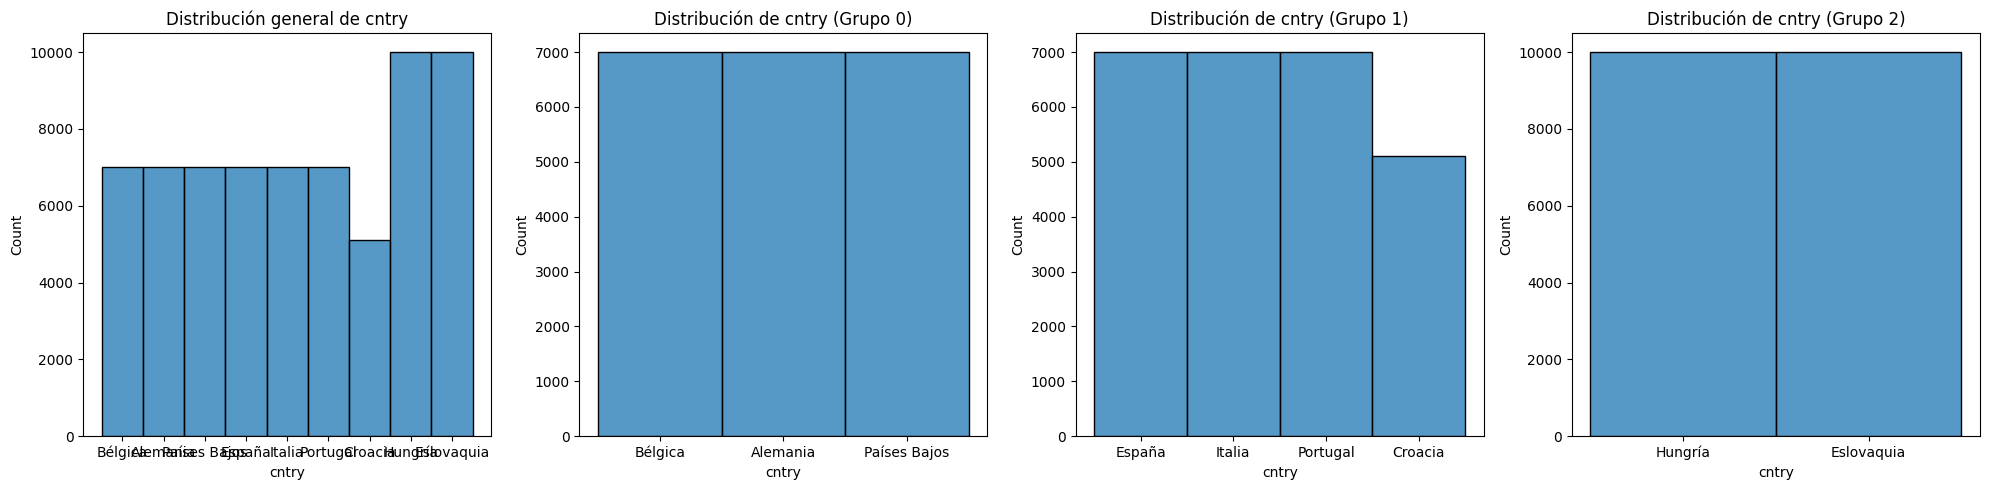

In [5]:
#Vamos a observar la columna cntry para ver la cantidad de muestras de cada pais.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def dist4(df, columna, grupo_columna='cntgrp_fc'):


    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    
    sns.histplot(df[columna], ax=axes[0])
    axes[0].set_title(f'Distribución general de {columna}')

   
    sns.histplot(df[df[grupo_columna] == 0][columna], ax=axes[1])
    axes[1].set_title(f'Distribución de {columna} (Grupo 0)')

    
    sns.histplot(df[df[grupo_columna] == 1][columna], ax=axes[2])
    axes[2].set_title(f'Distribución de {columna} (Grupo 1)')

    
    sns.histplot(df[df[grupo_columna] == 2][columna], ax=axes[3])
    axes[3].set_title(f'Distribución de {columna} (Grupo 2)')

    plt.tight_layout()
    plt.show()


dist4(dfeu, 'cntry')

Como podemos observar en la variable paises, hay un desbalanceo de clases, hay muchas mas muestras de alemania que del resto. Habra que tenerlo en cuenta a la hora de realizar el modelo de clasificacion.
Si el objetivo es ver la naturaleza de las distribuciones y obtener las principales variables estadisticas, un desbalance en las clases de este calibre, nos influira negativamente en el analisis de las distribuciones,
si nos interesa ver como influye cada grupo logico de muestras
.

En este documento se analizaran las principales variables estadisticas de cada columna.
Ademas de hacer una breve descripcion del tipo de funcion que describe la distribucion y un analisis breve de lo que ello significa.
'count': 'Número de muestras sin valores nulos',
'mean': 'Media aritmética',
'std': 'Desviación estándar, nos da una idea de cuanto se alejan los rangos de las muestras respecto a la media aritmetica, con un numero mas grande significa que mas varia',
'min': 'Valor mínimo, el valor minimo',
'25%': 'Percentil 25', el valor del rango de la variable donde se alojan el primer 25% de las muestras, ,
'50%': 'Mediana (percentil 50)', es el valor de la variable donde se divide el 50% de los datos,
'75%': 'Percentil 75', es el valor de la variable donde se ecuentran 3/4 de las muestras totales,
'max': 'Valor máximo', es el valor maximo de la variable que alcanza en el conjunto de las muestras,
'unique': 'Número de valores únicos',
'top': 'Valor más frecuente',
'freq': 'Frecuencia del valor más frecuente'

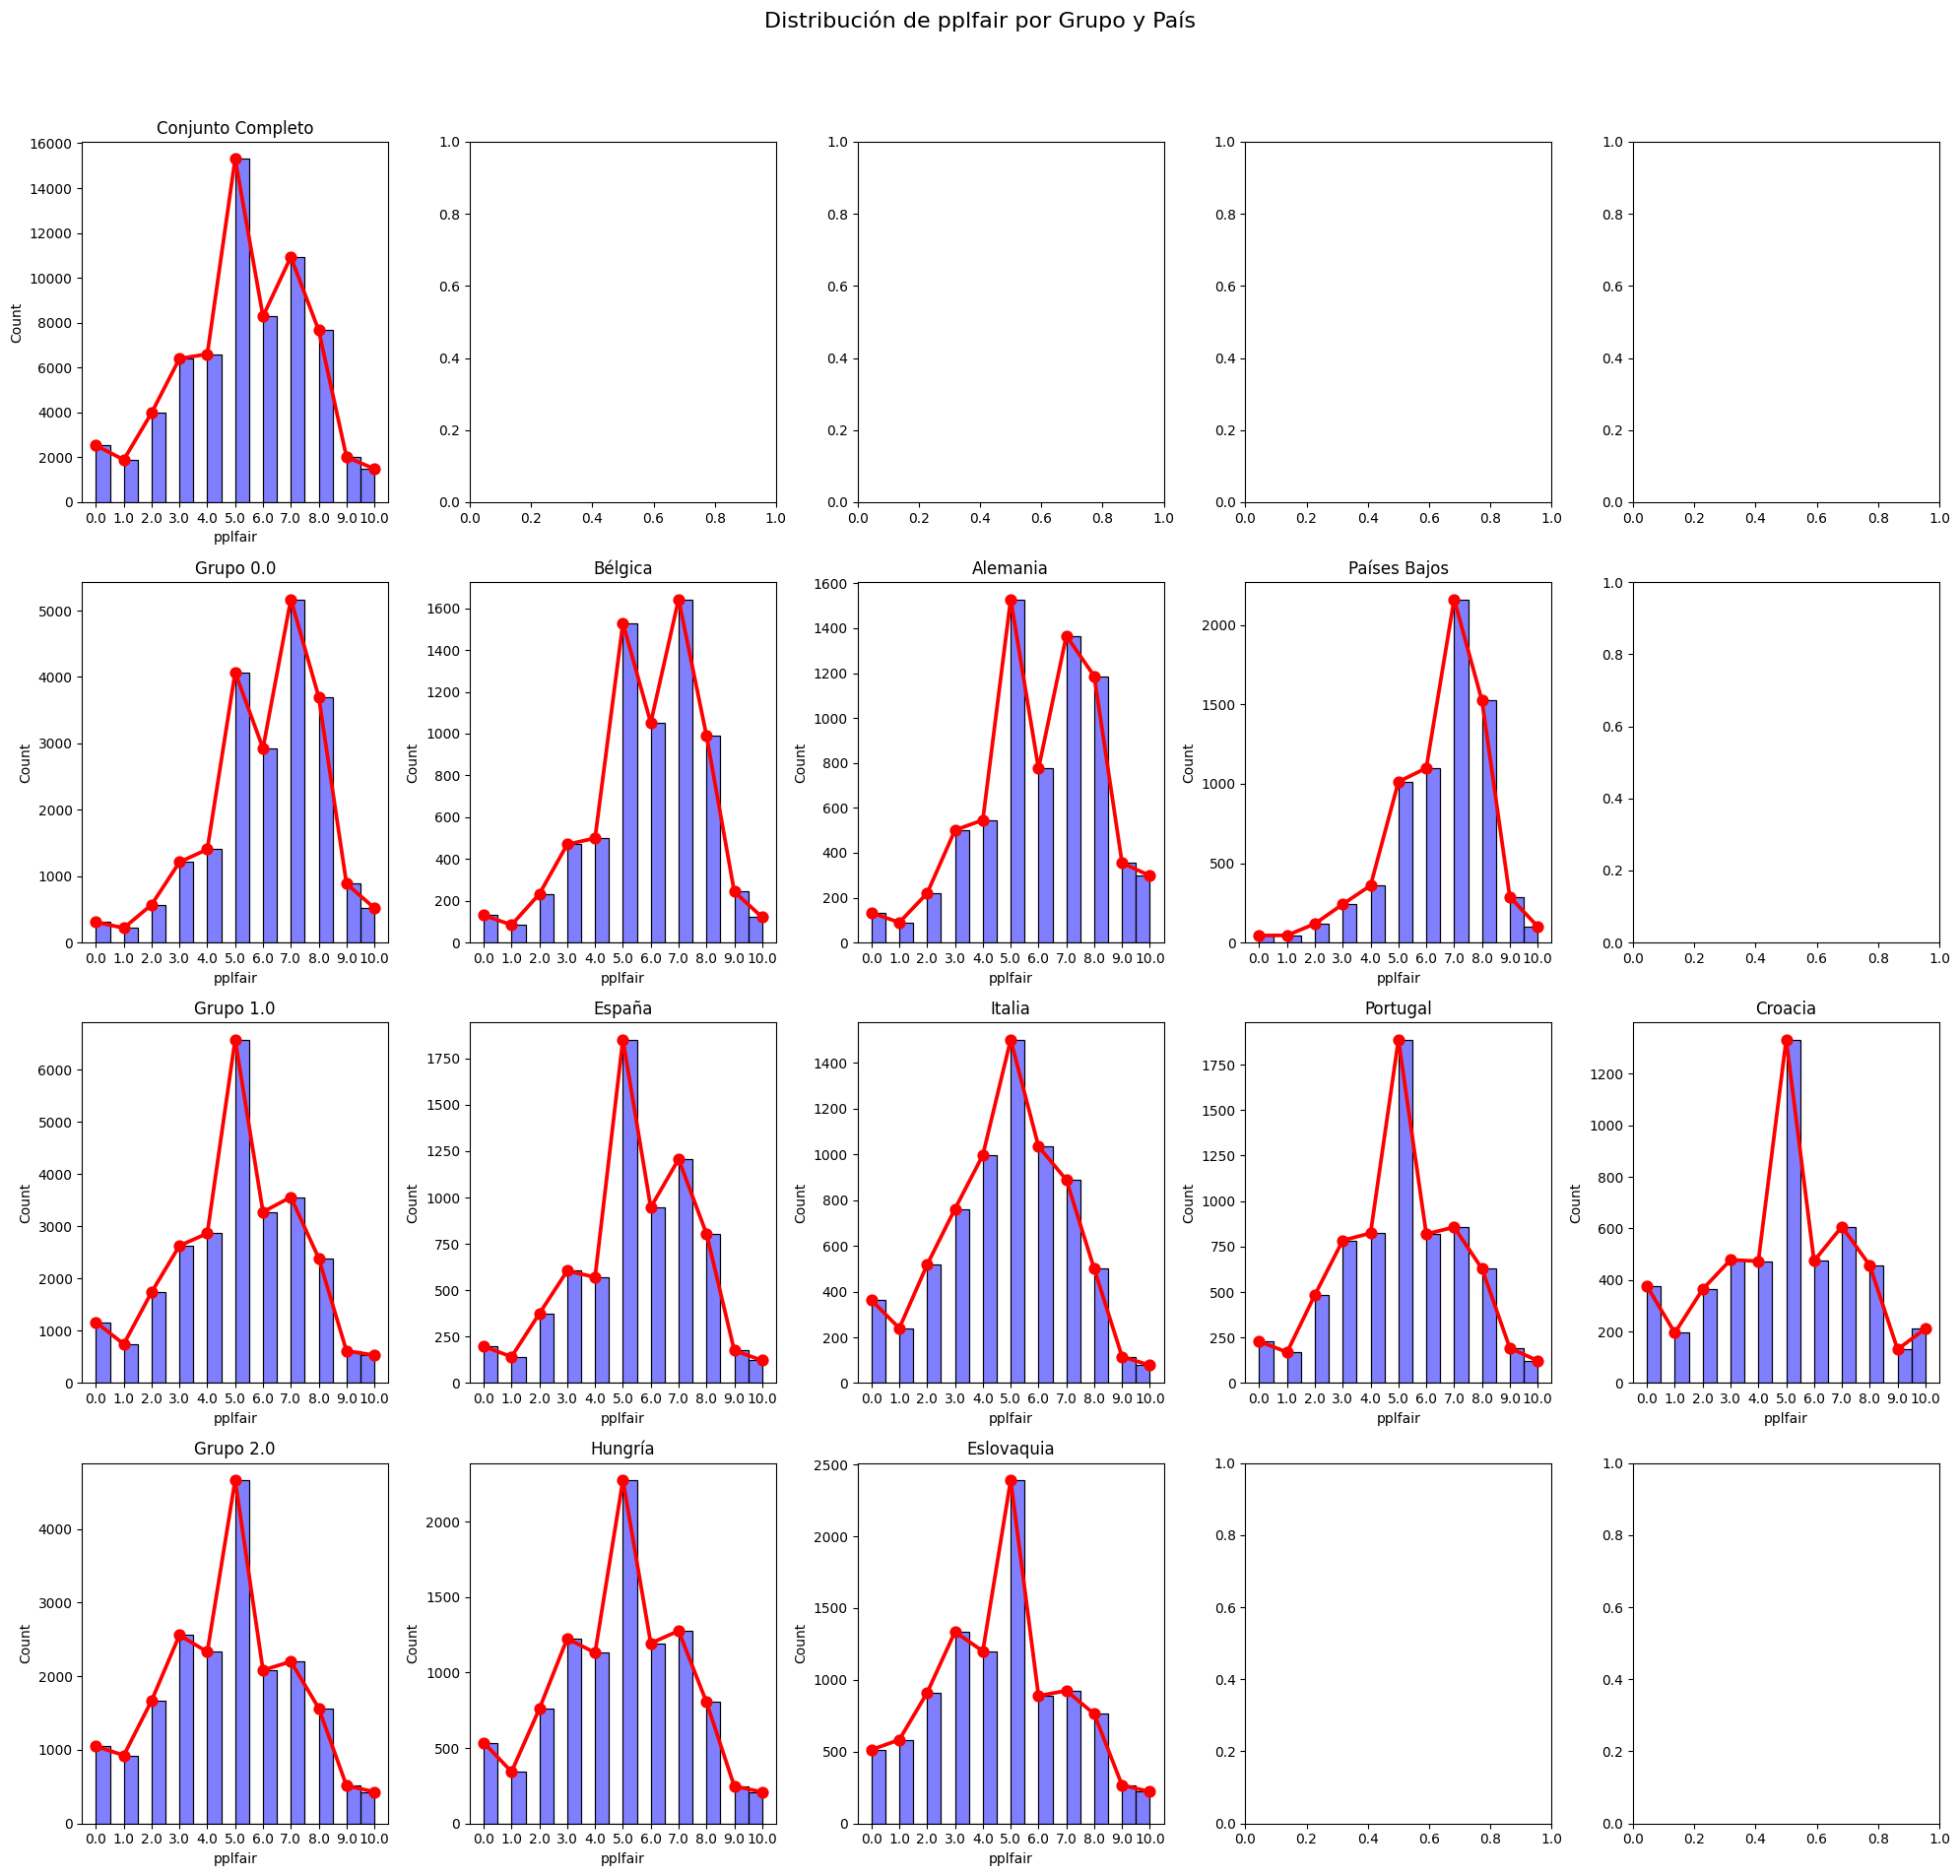

In [6]:
#Para la variable 'pplfair'
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def GroupDist(dataset, columna_a_graficar):


    
    grupos = dataset['cntgrp_fc'].unique()

    
    max_paises = max(dataset.groupby('cntgrp_fc')['cntry'].nunique())

    
    fig, axes = plt.subplots(len(grupos) + 1, max_paises + 1, figsize=(20, 5 * (len(grupos) + 1)))
    fig.suptitle(f'Distribución de {columna_a_graficar} por Grupo y País', fontsize=16)

    
    sns.histplot(dataset[columna_a_graficar], color='blue', alpha=0.5, binwidth=0.5, ax=axes[0, 0])
    sns.pointplot(x=dataset[columna_a_graficar].value_counts().sort_index().index,
                  y=dataset[columna_a_graficar].value_counts().sort_index().values,
                  color='red', linestyles='-', ax=axes[0, 0])
    axes[0, 0].set_title('Conjunto Completo')

    
    for i, grupo in enumerate(grupos):
        datos_grupo = dataset[dataset['cntgrp_fc'] == grupo]
        sns.histplot(datos_grupo[columna_a_graficar], color='blue', alpha=0.5, binwidth=0.5, ax=axes[i + 1, 0])
        sns.pointplot(x=datos_grupo[columna_a_graficar].value_counts().sort_index().index,
                      y=datos_grupo[columna_a_graficar].value_counts().sort_index().values,
                      color='red', linestyles='-', ax=axes[i + 1, 0])
        axes[i + 1, 0].set_title(f'Grupo {grupo}')

        
        paises = dataset[dataset['cntgrp_fc'] == grupo]['cntry'].unique()
        for j, pais in enumerate(paises):
            datos_pais = dataset[(dataset['cntgrp_fc'] == grupo) & (dataset['cntry'] == pais)]
            sns.histplot(datos_pais[columna_a_graficar], color='blue', alpha=0.5, binwidth=0.5, ax=axes[i + 1, j + 1])
            sns.pointplot(x=datos_pais[columna_a_graficar].value_counts().sort_index().index,
                          y=datos_pais[columna_a_graficar].value_counts().sort_index().values,
                          color='red', linestyles='-', ax=axes[i + 1, j + 1])
            axes[i + 1, j + 1].set_title(pais)

    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

GroupDist(dfeu, 'pplfair')

In [7]:
import pandas as pd

def statsgroup(dataset, columna_a_analizar):

    def calcular_varianza(columna):
        return columna.var()
    def calcular_moda_frecuencia(columna):
        moda = columna.mode()
        if not moda.empty:
            frecuencia = columna.value_counts()[moda.iloc[0]]
            return moda.iloc[0], frecuencia
        else:
            return None, None
    print(f"Estadísticas para {columna_a_analizar} - Conjunto Completo:")
    print(dataset[columna_a_analizar].describe())
    moda, frecuencia = calcular_moda_frecuencia(dataset[columna_a_analizar])
    print(f"Moda: {moda}, Frecuencia: {frecuencia}")
    print(f"Varianza: {calcular_varianza(dataset[columna_a_analizar])}")
    print("\n")

    
    grupos = dataset['cntgrp_fc'].unique()
    for grupo in grupos:
        datos_grupo = dataset[dataset['cntgrp_fc'] == grupo]
        print(f"Estadísticas para {columna_a_analizar} - Grupo {grupo}:")
        print(datos_grupo[columna_a_analizar].describe())
        moda, frecuencia = calcular_moda_frecuencia(datos_grupo[columna_a_analizar])
        print(f"Moda: {moda}, Frecuencia: {frecuencia}")
        print(f"Varianza: {calcular_varianza(datos_grupo[columna_a_analizar])}")
        print("\n")

        
        paises = dataset[dataset['cntgrp_fc'] == grupo]['cntry'].unique()
        for pais in paises:
            datos_pais = dataset[(dataset['cntgrp_fc'] == grupo) & (dataset['cntry'] == pais)]
            print(f"Estadísticas para {columna_a_analizar} - País {pais} (Grupo {grupo}):")
            print(datos_pais[columna_a_analizar].describe())
            moda, frecuencia = calcular_moda_frecuencia(datos_pais[columna_a_analizar])
            print(f"Moda: {moda}, Frecuencia: {frecuencia}")
            print(f"Varianza: {calcular_varianza(datos_pais[columna_a_analizar])}")
            print("\n")


statsgroup(dfeu, 'pplfair')

Estadísticas para pplfair - Conjunto Completo:
count    67098.000000
mean         5.254523
std          2.276029
min          0.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: pplfair, dtype: float64
Moda: 5.0, Frecuencia: 15307
Varianza: 5.180309882681448


Estadísticas para pplfair - Grupo 0.0:
count    21000.000000
mean         6.074190
std          1.983484
min          0.000000
25%          5.000000
50%          6.000000
75%          7.000000
max         10.000000
Name: pplfair, dtype: float64
Moda: 7.0, Frecuencia: 5171
Varianza: 3.9342069259533896


Estadísticas para pplfair - País Bélgica (Grupo 0.0):
count    7000.000000
mean        5.823714
std         1.995439
min         0.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        10.000000
Name: pplfair, dtype: float64
Moda: 7.0, Frecuencia: 1643
Varianza: 3.9817778866368663


Estadísticas para pplfair - País Alemania (Grupo 0.0):
count    7000.0000

Para nuestra variable/columna 'pplfair':
(2-'pplfair': Escala 0 a 10. 0 si crees que la gente intenta aprovecharse, a 10 si crees que la gente es honesta.)
Es una variable discontinua que sigue una distribucion normal simetrica bimodal.
Es decir que la mayor cantidad de muestras se dividen en dos montones claramente visibles y en este caso en particular bastante centrados.
Si observamos esta variable en los conjuntos de paises, conforme los paises son mas pobres, la media aritmetica
va coincidiendo con la moda, por lo que graficamente solo se observa un maximo local y desaparece el segundo.
Tambien se aprecia una disminucion de la varianza.
De momento nuestra hipotesis de que la situacion economica influye en las variables es probable, los dibujos por grupos de paises coinciden bastante con los de paises individualmente.

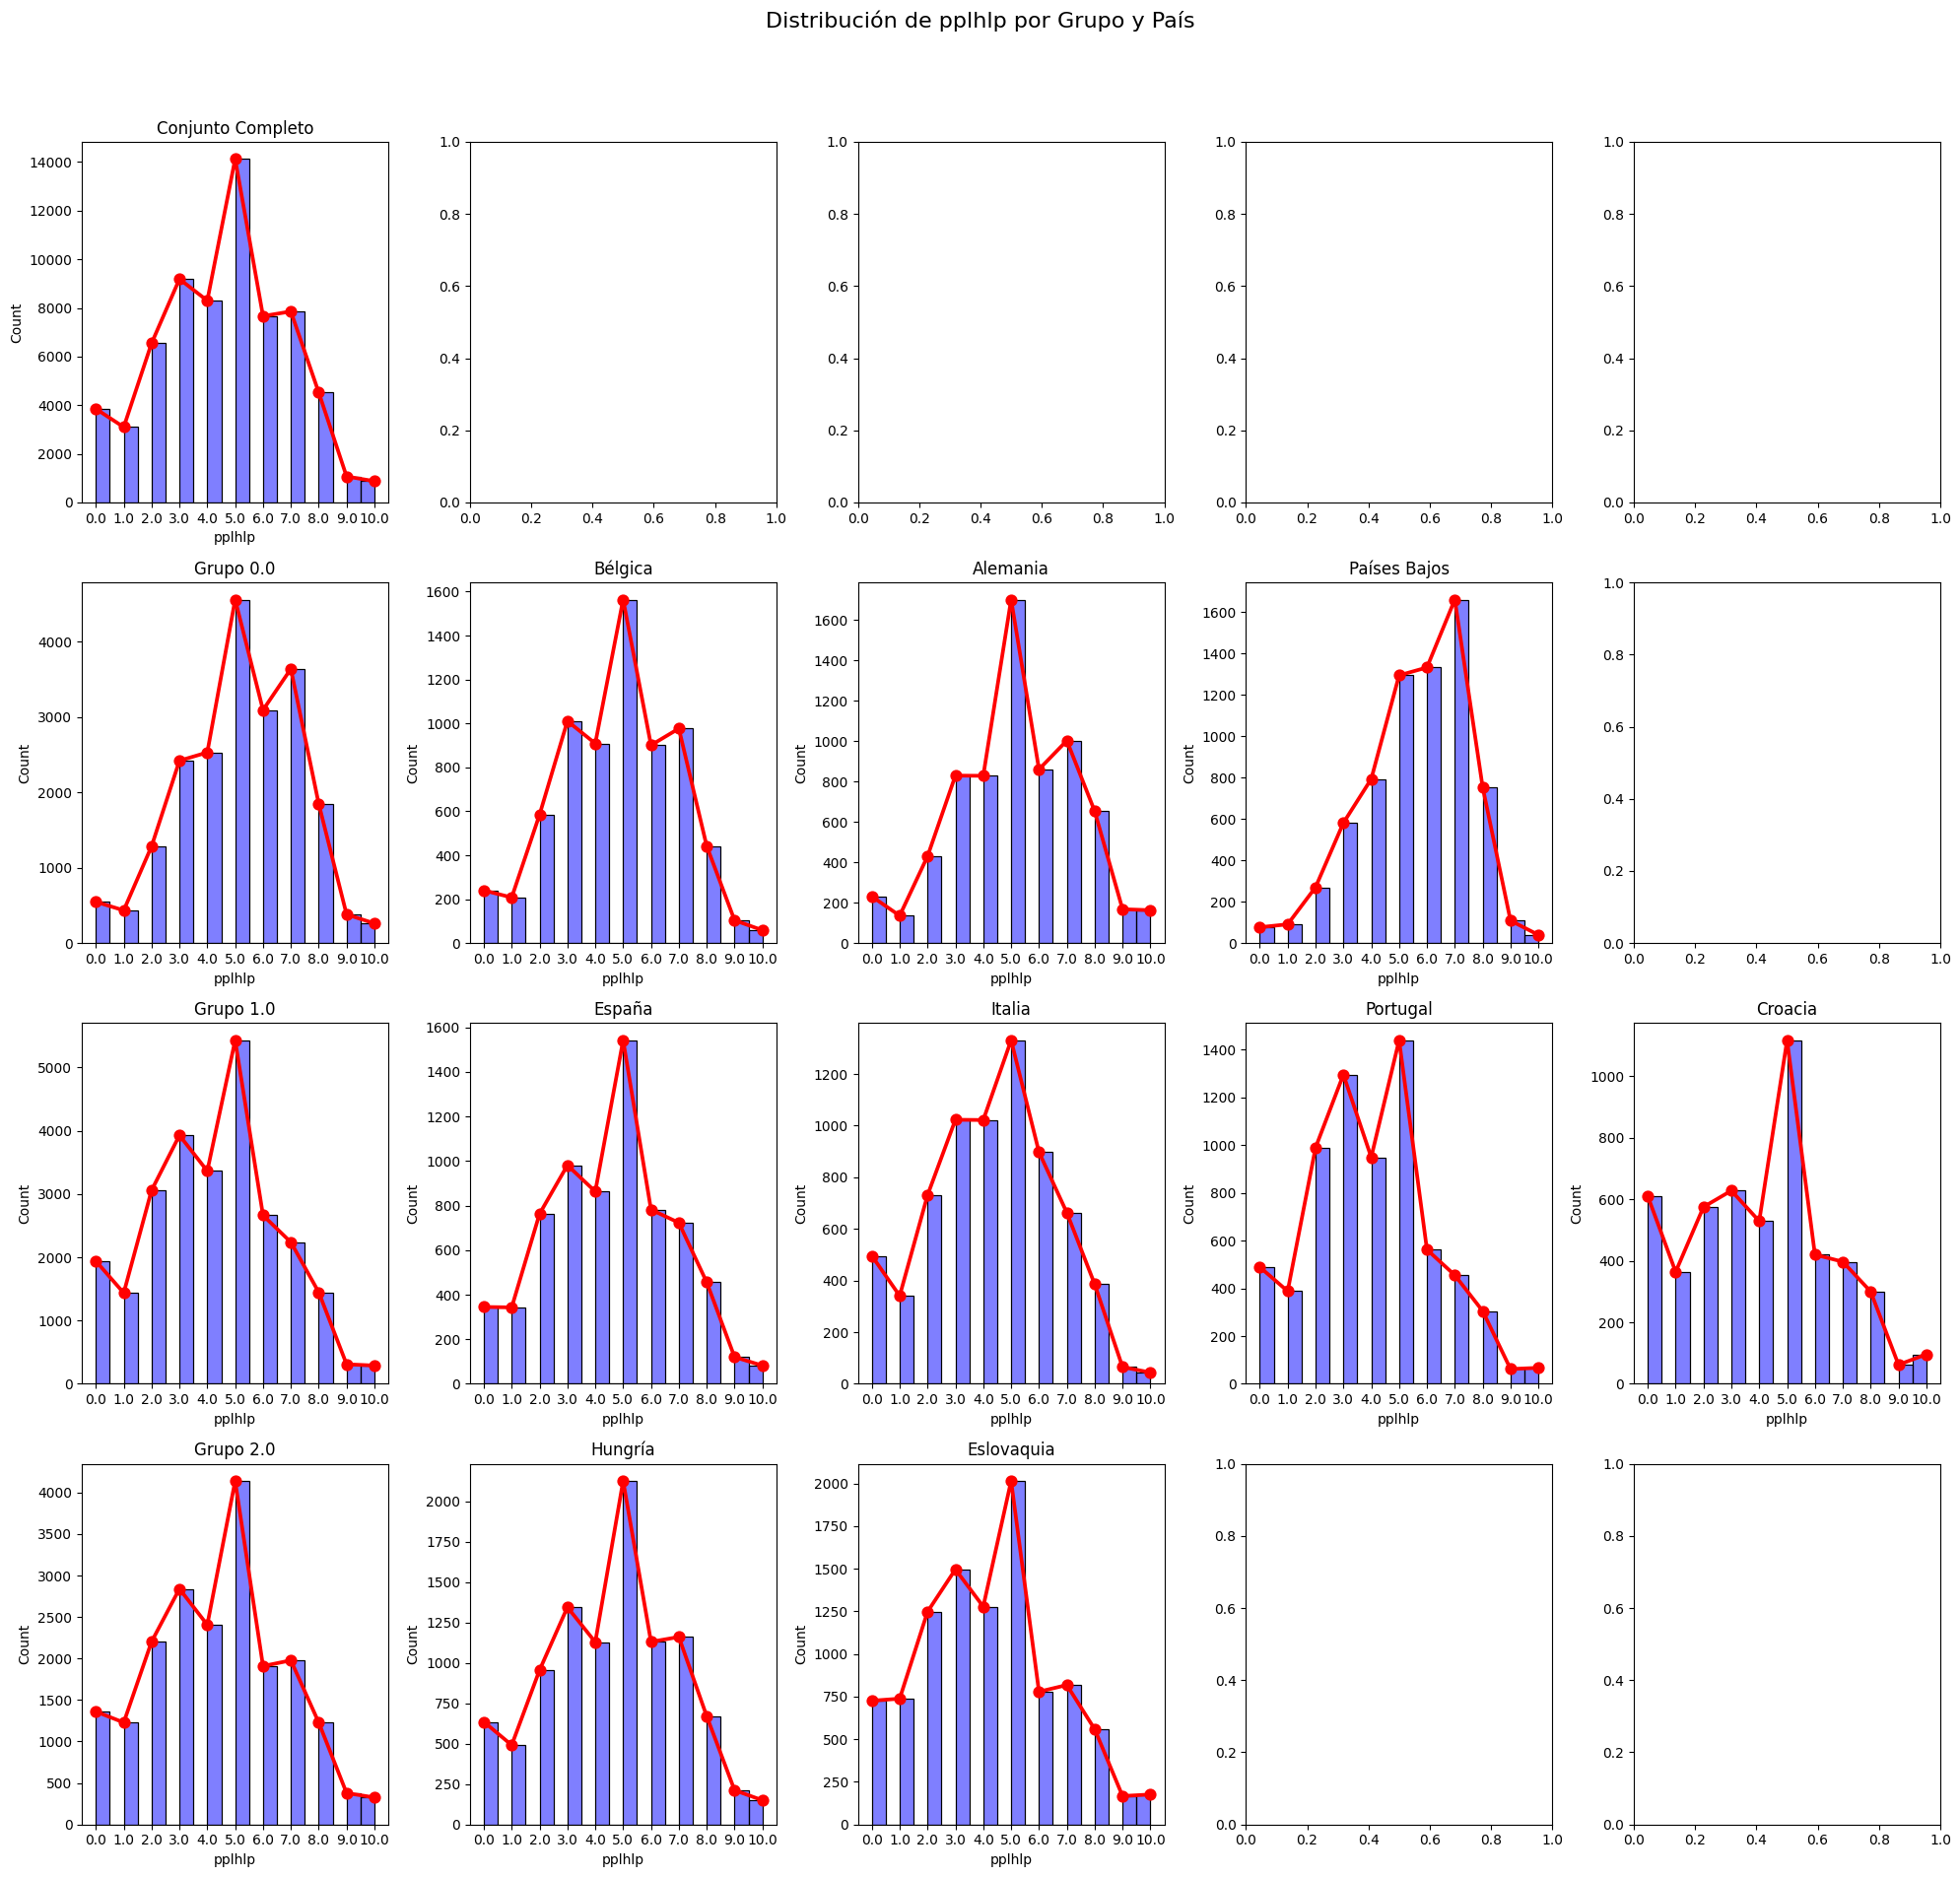

Estadísticas para pplhlp - Conjunto Completo:
count    67098.000000
mean         4.517854
std          2.293764
min          0.000000
25%          3.000000
50%          5.000000
75%          6.000000
max         10.000000
Name: pplhlp, dtype: float64
Moda: 5.0, Frecuencia: 14127
Varianza: 5.2613546109536555


Estadísticas para pplhlp - Grupo 0.0:
count    21000.000000
mean         5.144857
std          2.080861
min          0.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: pplhlp, dtype: float64
Moda: 5.0, Frecuencia: 4558
Varianza: 4.329984502663392


Estadísticas para pplhlp - País Bélgica (Grupo 0.0):
count    7000.000000
mean        4.739143
std         2.104421
min         0.000000
25%         3.000000
50%         5.000000
75%         6.000000
max        10.000000
Name: pplhlp, dtype: float64
Moda: 5.0, Frecuencia: 1564
Varianza: 4.428586206192721


Estadísticas para pplhlp - País Alemania (Grupo 0.0):
count    7000.000000
mean 

In [8]:
#Para la variable 'pplhlp'
GroupDist(dfeu, 'pplhlp')
statsgroup(dfeu, 'pplhlp')

Para la variable 'pplhlp':
(3-'pplhlp': Escala 0 a 10. 0 si crees que la gente solo miran por sus intereses, a 10 si crees que la gente mira por el bien comun.)

Variable discontinua que  funcion normal simetrica(gaussiana), si que es cierto que conforme, el grupo de paises es mas pobre
Tiene a bimodalizarse.
Se observa una ligera asimetria hacia un valor de rango positivo en el caso de las muestras de Paises Bajos.
Quiza su escasa poblacion o por cuestiones culturales, la gente tiende a pensar que la gente mira por el bien comun.
La variable con el conjunto total de muestras tiende a asemejarse a la distribucion Alemana, a parte de porque es el conjunto
con mas muestras tambien es porque casi todos los paises tienen distribuciones parejas.
El criterio de agrupacion sigue cumpliendose con apenas diferencias en las distribuciones del grupo y sus paises.

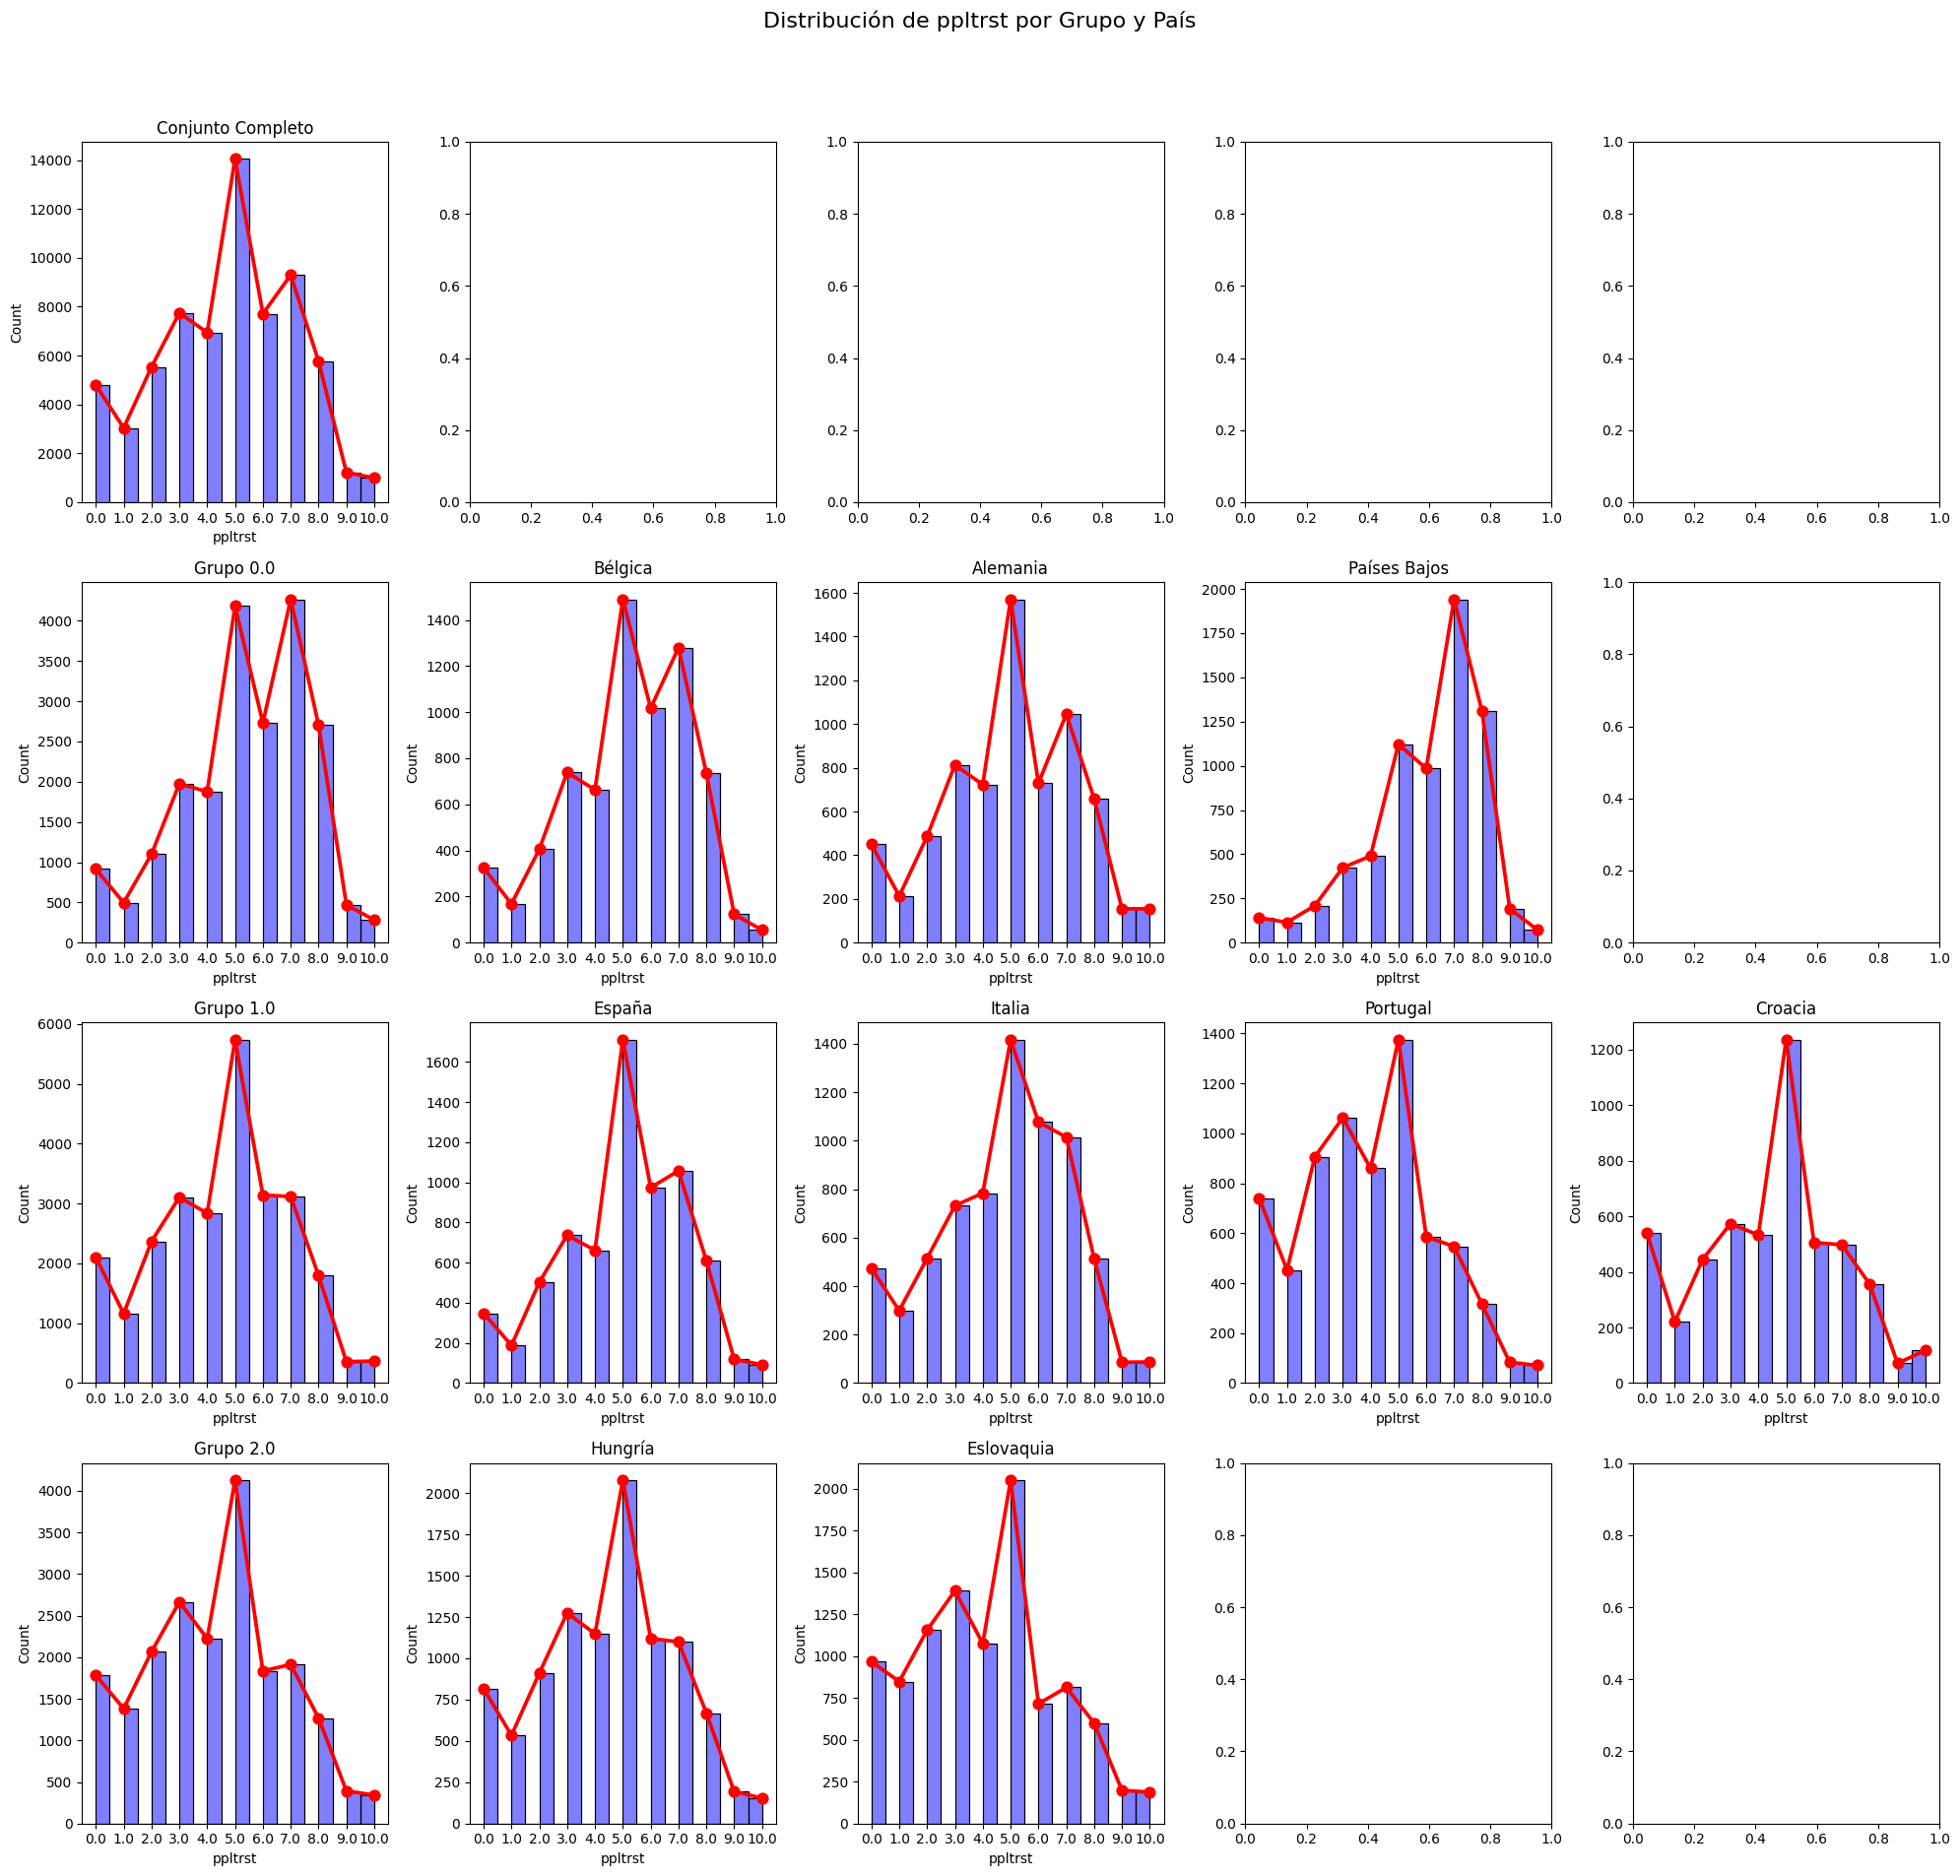

In [9]:
GroupDist(dfeu, 'ppltrst')

In [10]:
statsgroup(dfeu, 'ppltrst')

Estadísticas para ppltrst - Conjunto Completo:
count    67098.000000
mean         4.675966
std          2.412289
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: ppltrst, dtype: float64
Moda: 5.0, Frecuencia: 14052
Varianza: 5.819140402293466


Estadísticas para ppltrst - Grupo 0.0:
count    21000.000000
mean         5.332286
std          2.255896
min          0.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: ppltrst, dtype: float64
Moda: 7.0, Frecuencia: 4268
Varianza: 5.089066635826195


Estadísticas para ppltrst - País Bélgica (Grupo 0.0):
count    7000.000000
mean        5.128000
std         2.205907
min         0.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        10.000000
Name: ppltrst, dtype: float64
Moda: 5.0, Frecuencia: 1490
Varianza: 4.8660254322046015


Estadísticas para ppltrst - País Alemania (Grupo 0.0):
count    7000.00000

4-'ppltrst': Escala de 0 a 10. 0 Si crees que no puedes confiar en nadie, a 10 si crees que se puede confiar.
Variable discontinua que describe a primera vista una funcion normal simetrica bimodal, escepto en el grupo dos donde casi se asemeja
a su media aritmetica.
En el primer grupo tiende a bimodalizarse a partir de rangos mayores a la media aritmetica por lo que sugiere que conforme, las condiciones economicas son mejores, la gente suele confiar mas.
En el segundo grupo se aprecian discrepancias entre las muestras de los distintos paises, aun asi se asemejan al grafico de muestras
de su grupo.
En el  tercer grupo se puede apreciar incluso una funcion normal simetrica trimodal, con ambos dos subconjuntos alrededor del valor, tanto por arriba como por abajo de la media aritmetica de la variable.
Bastante bien distribuido, en todo el rango de la variable.
En el conjunto global de datos de esta variable, casi se describe una distribucion simetrica trimodal.
Por lo general las distribuciones entre paises y sus grupos se asemejan bastante.


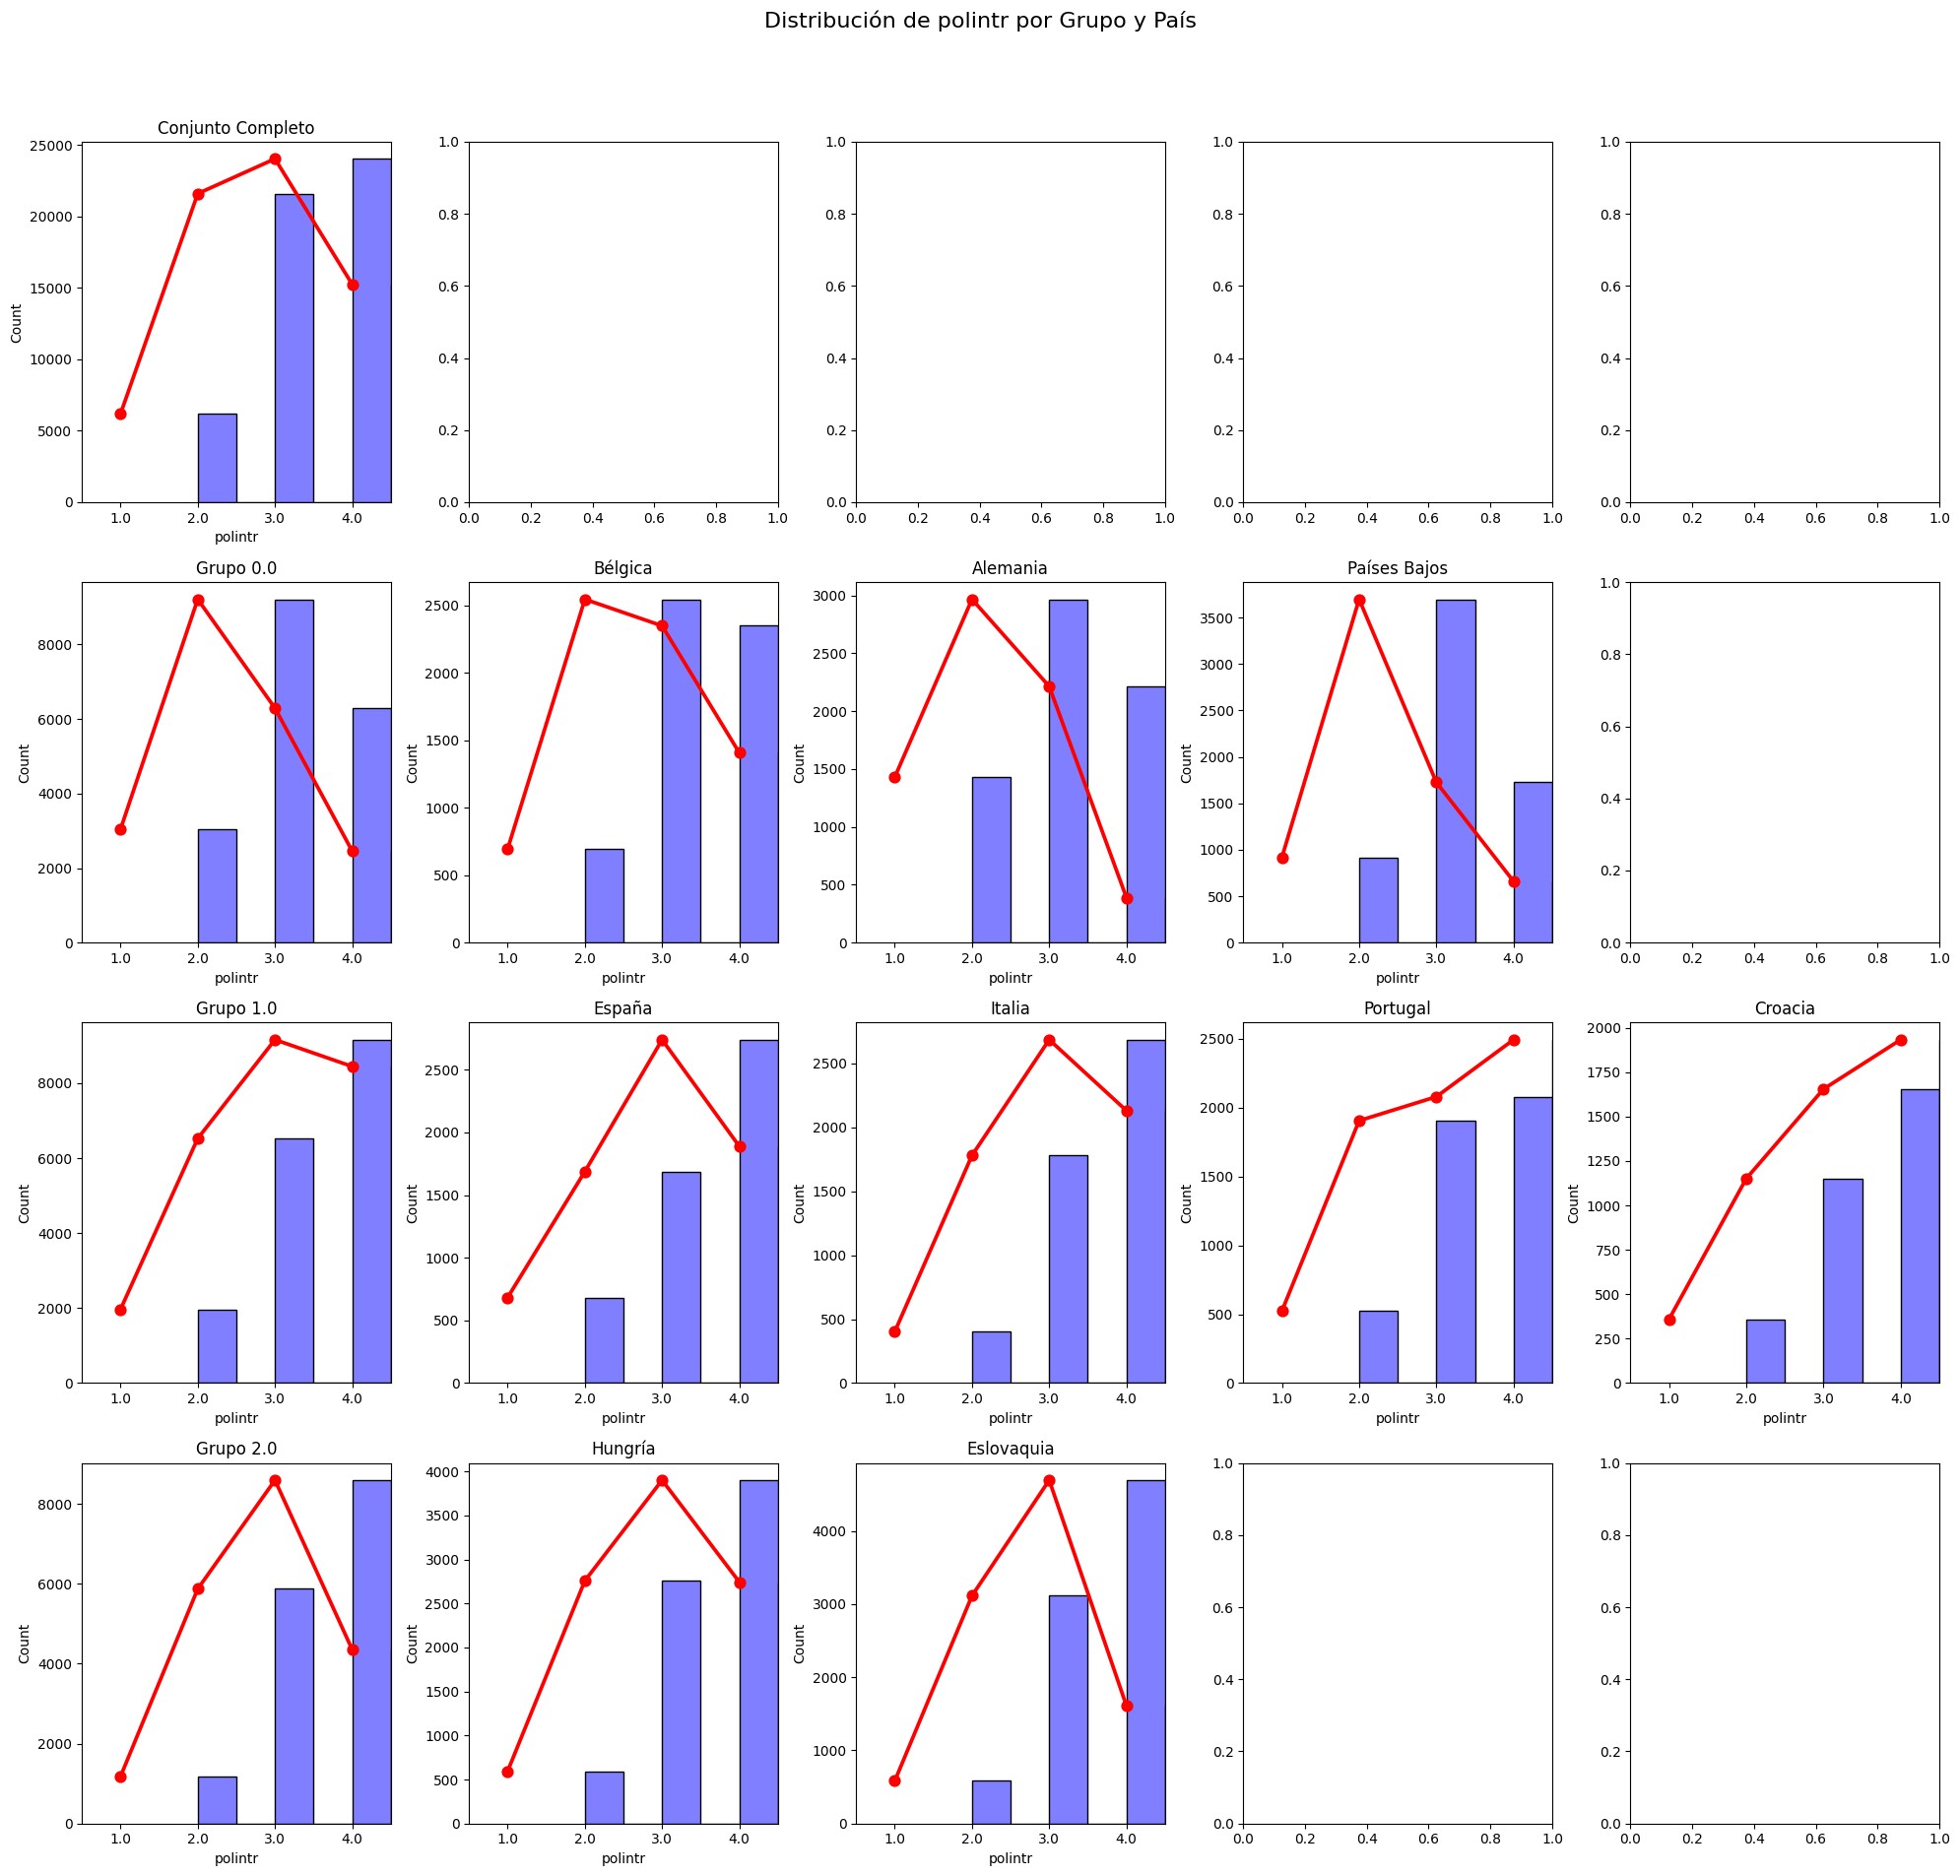

In [11]:
#Variable 'polintr'
GroupDist(dfeu, 'polintr')

In [12]:
statsgroup(dfeu, 'polintr')

Estadísticas para polintr - Conjunto Completo:
count    67098.000000
mean         2.720945
std          0.916706
min          1.000000
25%          2.000000
50%          3.000000
75%          3.000000
max          4.000000
Name: polintr, dtype: float64
Moda: 3.0, Frecuencia: 24046
Varianza: 0.8403502871749231


Estadísticas para polintr - Grupo 0.0:
count    21000.000000
mean         2.388667
std          0.872557
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          4.000000
Name: polintr, dtype: float64
Moda: 2.0, Frecuencia: 9211
Varianza: 0.761355429623633


Estadísticas para polintr - País Bélgica (Grupo 0.0):
count    7000.000000
mean        2.638714
std         0.911995
min         1.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         4.000000
Name: polintr, dtype: float64
Moda: 2.0, Frecuencia: 2547
Varianza: 0.8317343089829159


Estadísticas para polintr - País Alemania (Grupo 0.0):
count    7000.0000

5-'polintr': Escala de 1 a 4 de intensidad. 1 muy interesado en politica, a 4 estando nada interesado.
Variable discontinua con 5 posibles valores, su distribucion sigue una funcion normal con un detalle interesante a comentar.
Conforme vamos mirando los graficos por grupos de paises podemos observar tanto en las graficas como en los datos de moda y media aritmetica, conforme los grupos son de paises mas pobres , el interes por politica se va perdiendo.
Es decir la media aritmetica cercana a 2 del grupo 0(rico), se va desplazando hasta casi alcanzar el 3 en el grupo 2.
Por el desbalance de clases(hay muchas mas muestras del grupo 0 al resto) agrupando por grupos de paises,
La distribucion general se centra en el valor medio aritmetico de la variable discontinua.


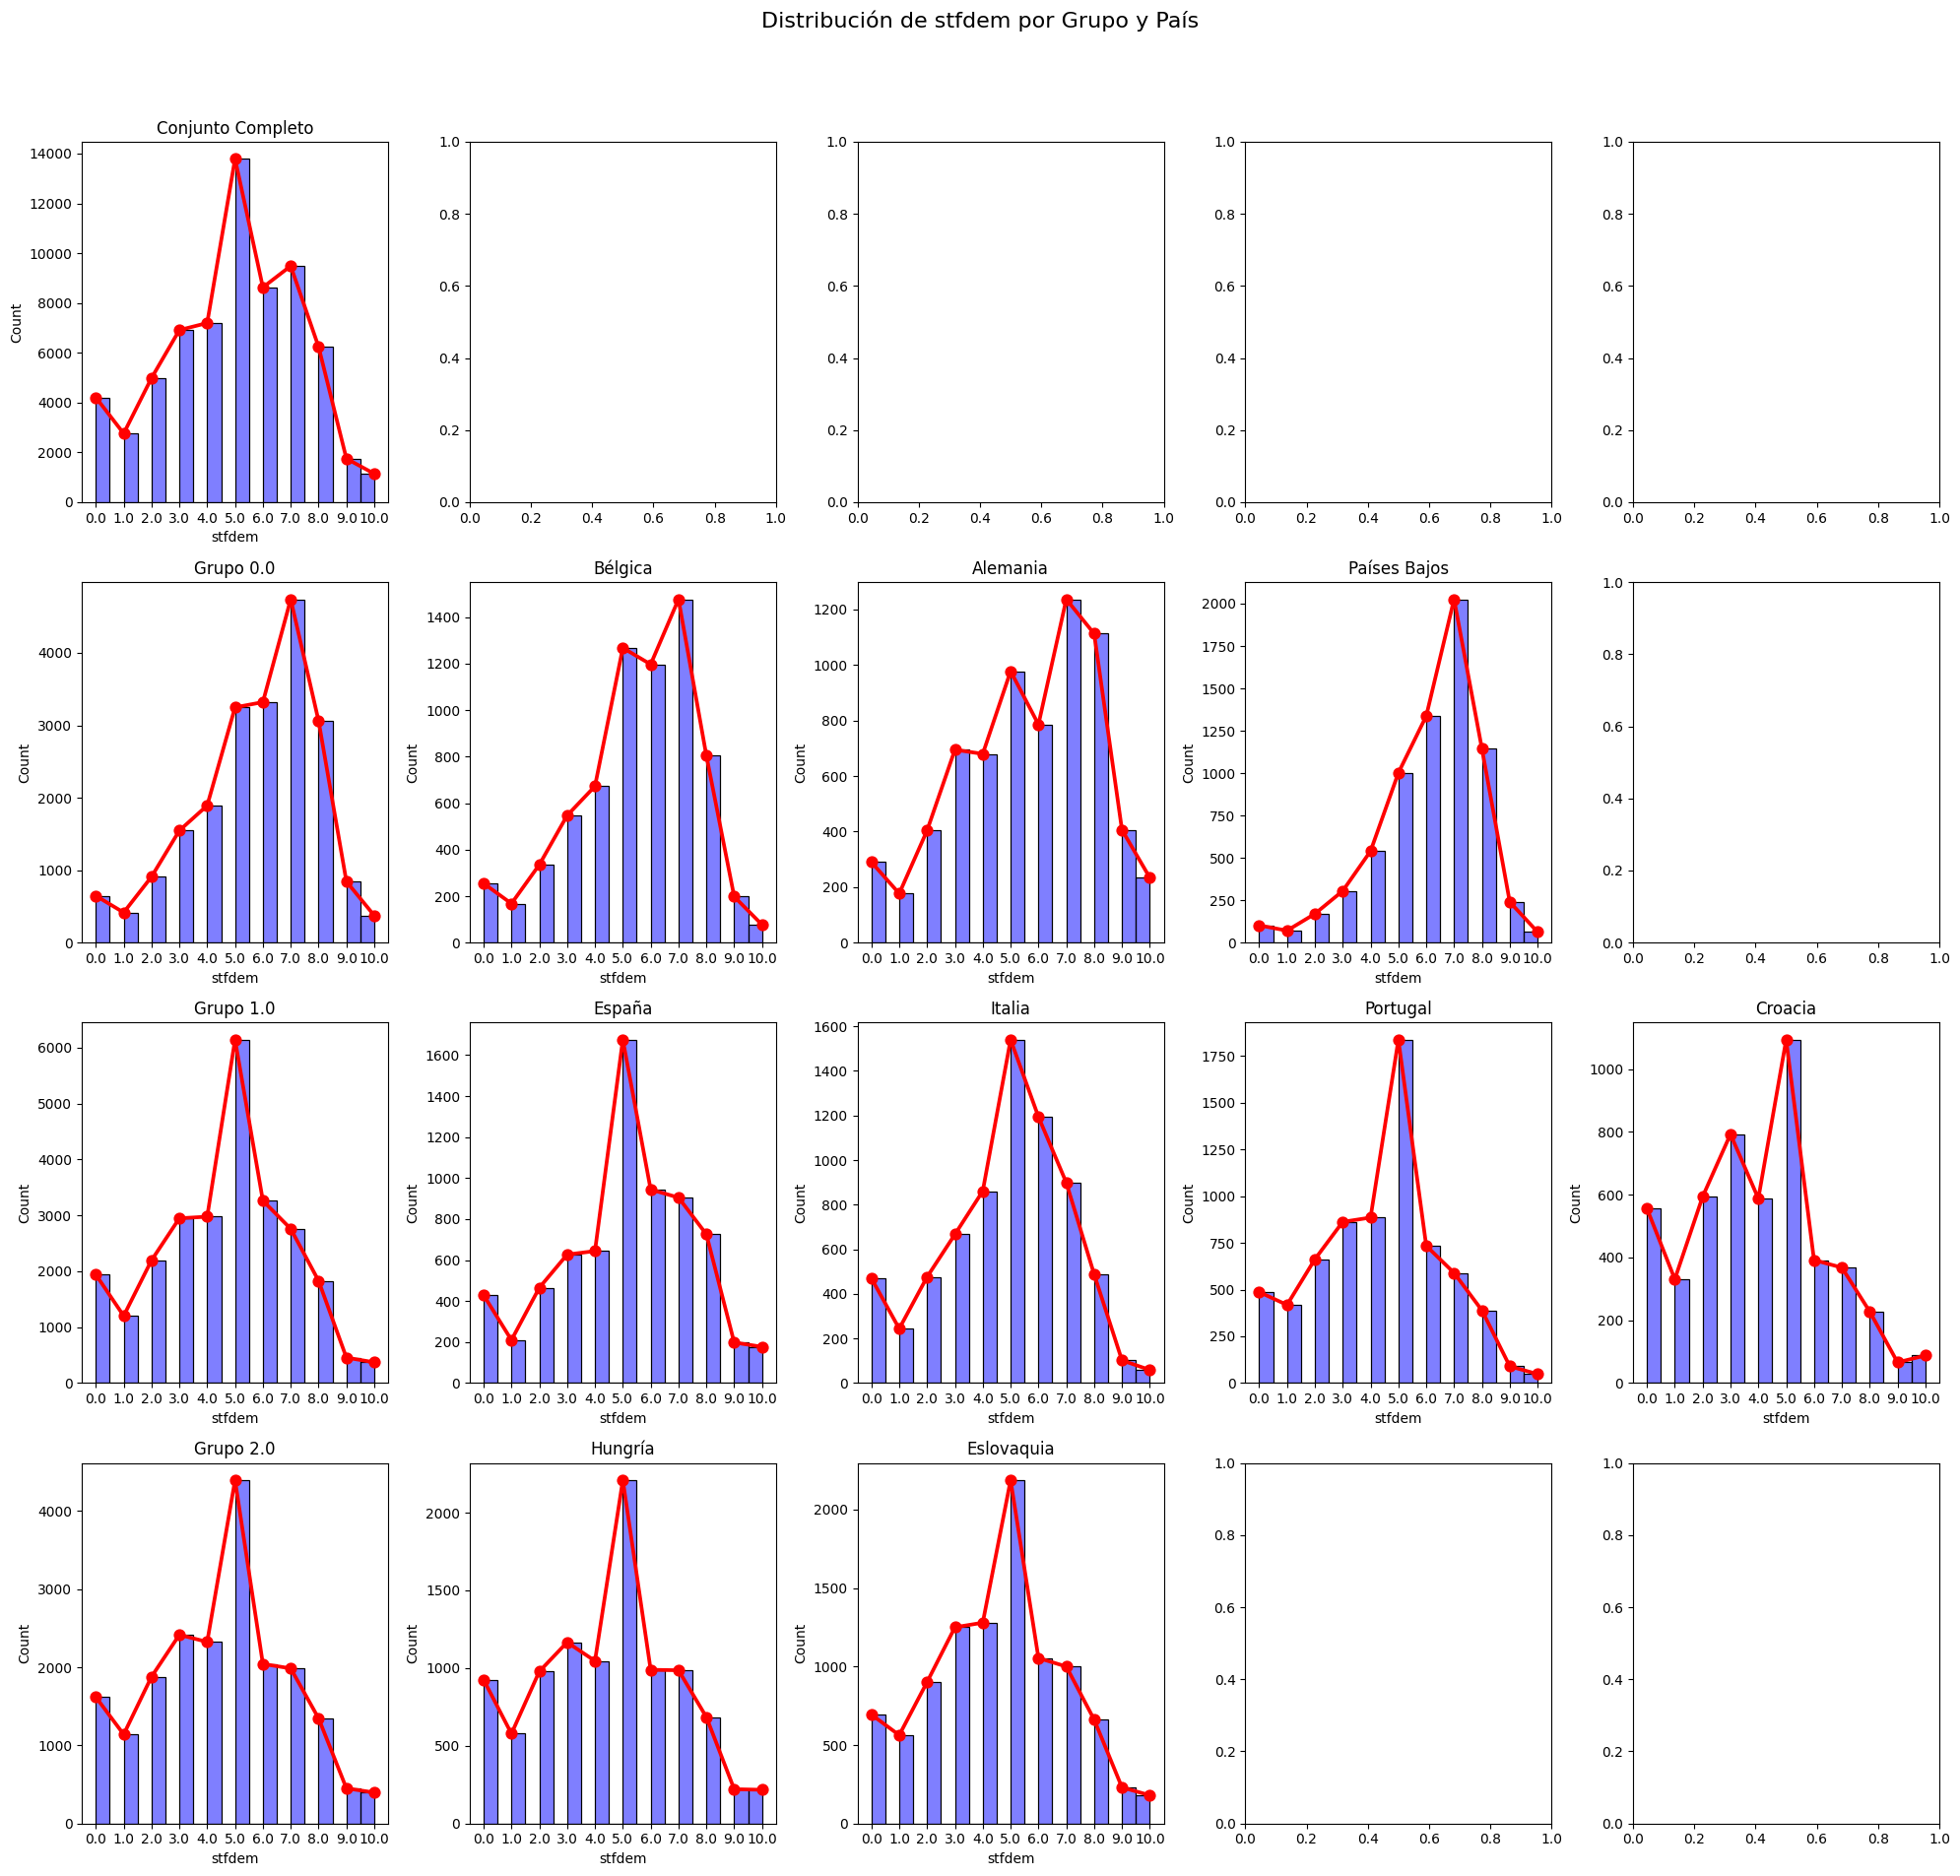

In [13]:
#Variable 'stfdem'
GroupDist(dfeu, 'stfdem')

In [14]:
statsgroup(dfeu, 'stfdem')

Estadísticas para stfdem - Conjunto Completo:
count    67098.000000
mean         4.865644
std          2.402188
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: stfdem, dtype: float64
Moda: 5.0, Frecuencia: 13789
Varianza: 5.770508118063559


Estadísticas para stfdem - Grupo 0.0:
count    21000.000000
mean         5.696143
std          2.199707
min          0.000000
25%          4.000000
50%          6.000000
75%          7.000000
max         10.000000
Name: stfdem, dtype: float64
Moda: 7.0, Frecuencia: 4740
Varianza: 4.838710775343043


Estadísticas para stfdem - País Bélgica (Grupo 0.0):
count    7000.000000
mean        5.432000
std         2.173883
min         0.000000
25%         4.000000
50%         6.000000
75%         7.000000
max        10.000000
Name: stfdem, dtype: float64
Moda: 7.0, Frecuencia: 1477
Varianza: 4.7257653950564364


Estadísticas para stfdem - País Alemania (Grupo 0.0):
count    7000.000000
mean 

6-'stfdem': Escala de 0 a 10. 0 siendo muy insatisfecho en como funciona la democracia(ley electoral) en tu pais, a 10 estando muy satisfecho.
Variable que en el conjunto global de los datos describe claramente una funcion simetrica bimodal, algo desplazada positivamente respecto a la media aritmetica de la variable.
Las muestras del grupo 1 tienden a tener mas densidad de la media aritmetica a valores mas grandes a este.
Conforme bajamos al conjunto de datos del grupo 1 y 2 de paises, las muestras tienden a modalizar en la media aritmetica por lo que sugiere que la instatisfaccion aumenta en funcion del empeoramiento economico, incluso en el grupo tres se aprecia claramente
unua funcion normal simetrica trimodal, con dos grandes gruesos de muestras alrededor de la media aritmetica.
Los conjuntos de muestras por pais respetan bastante y se asemejan bastante al grupo de paises al que pertenecen.

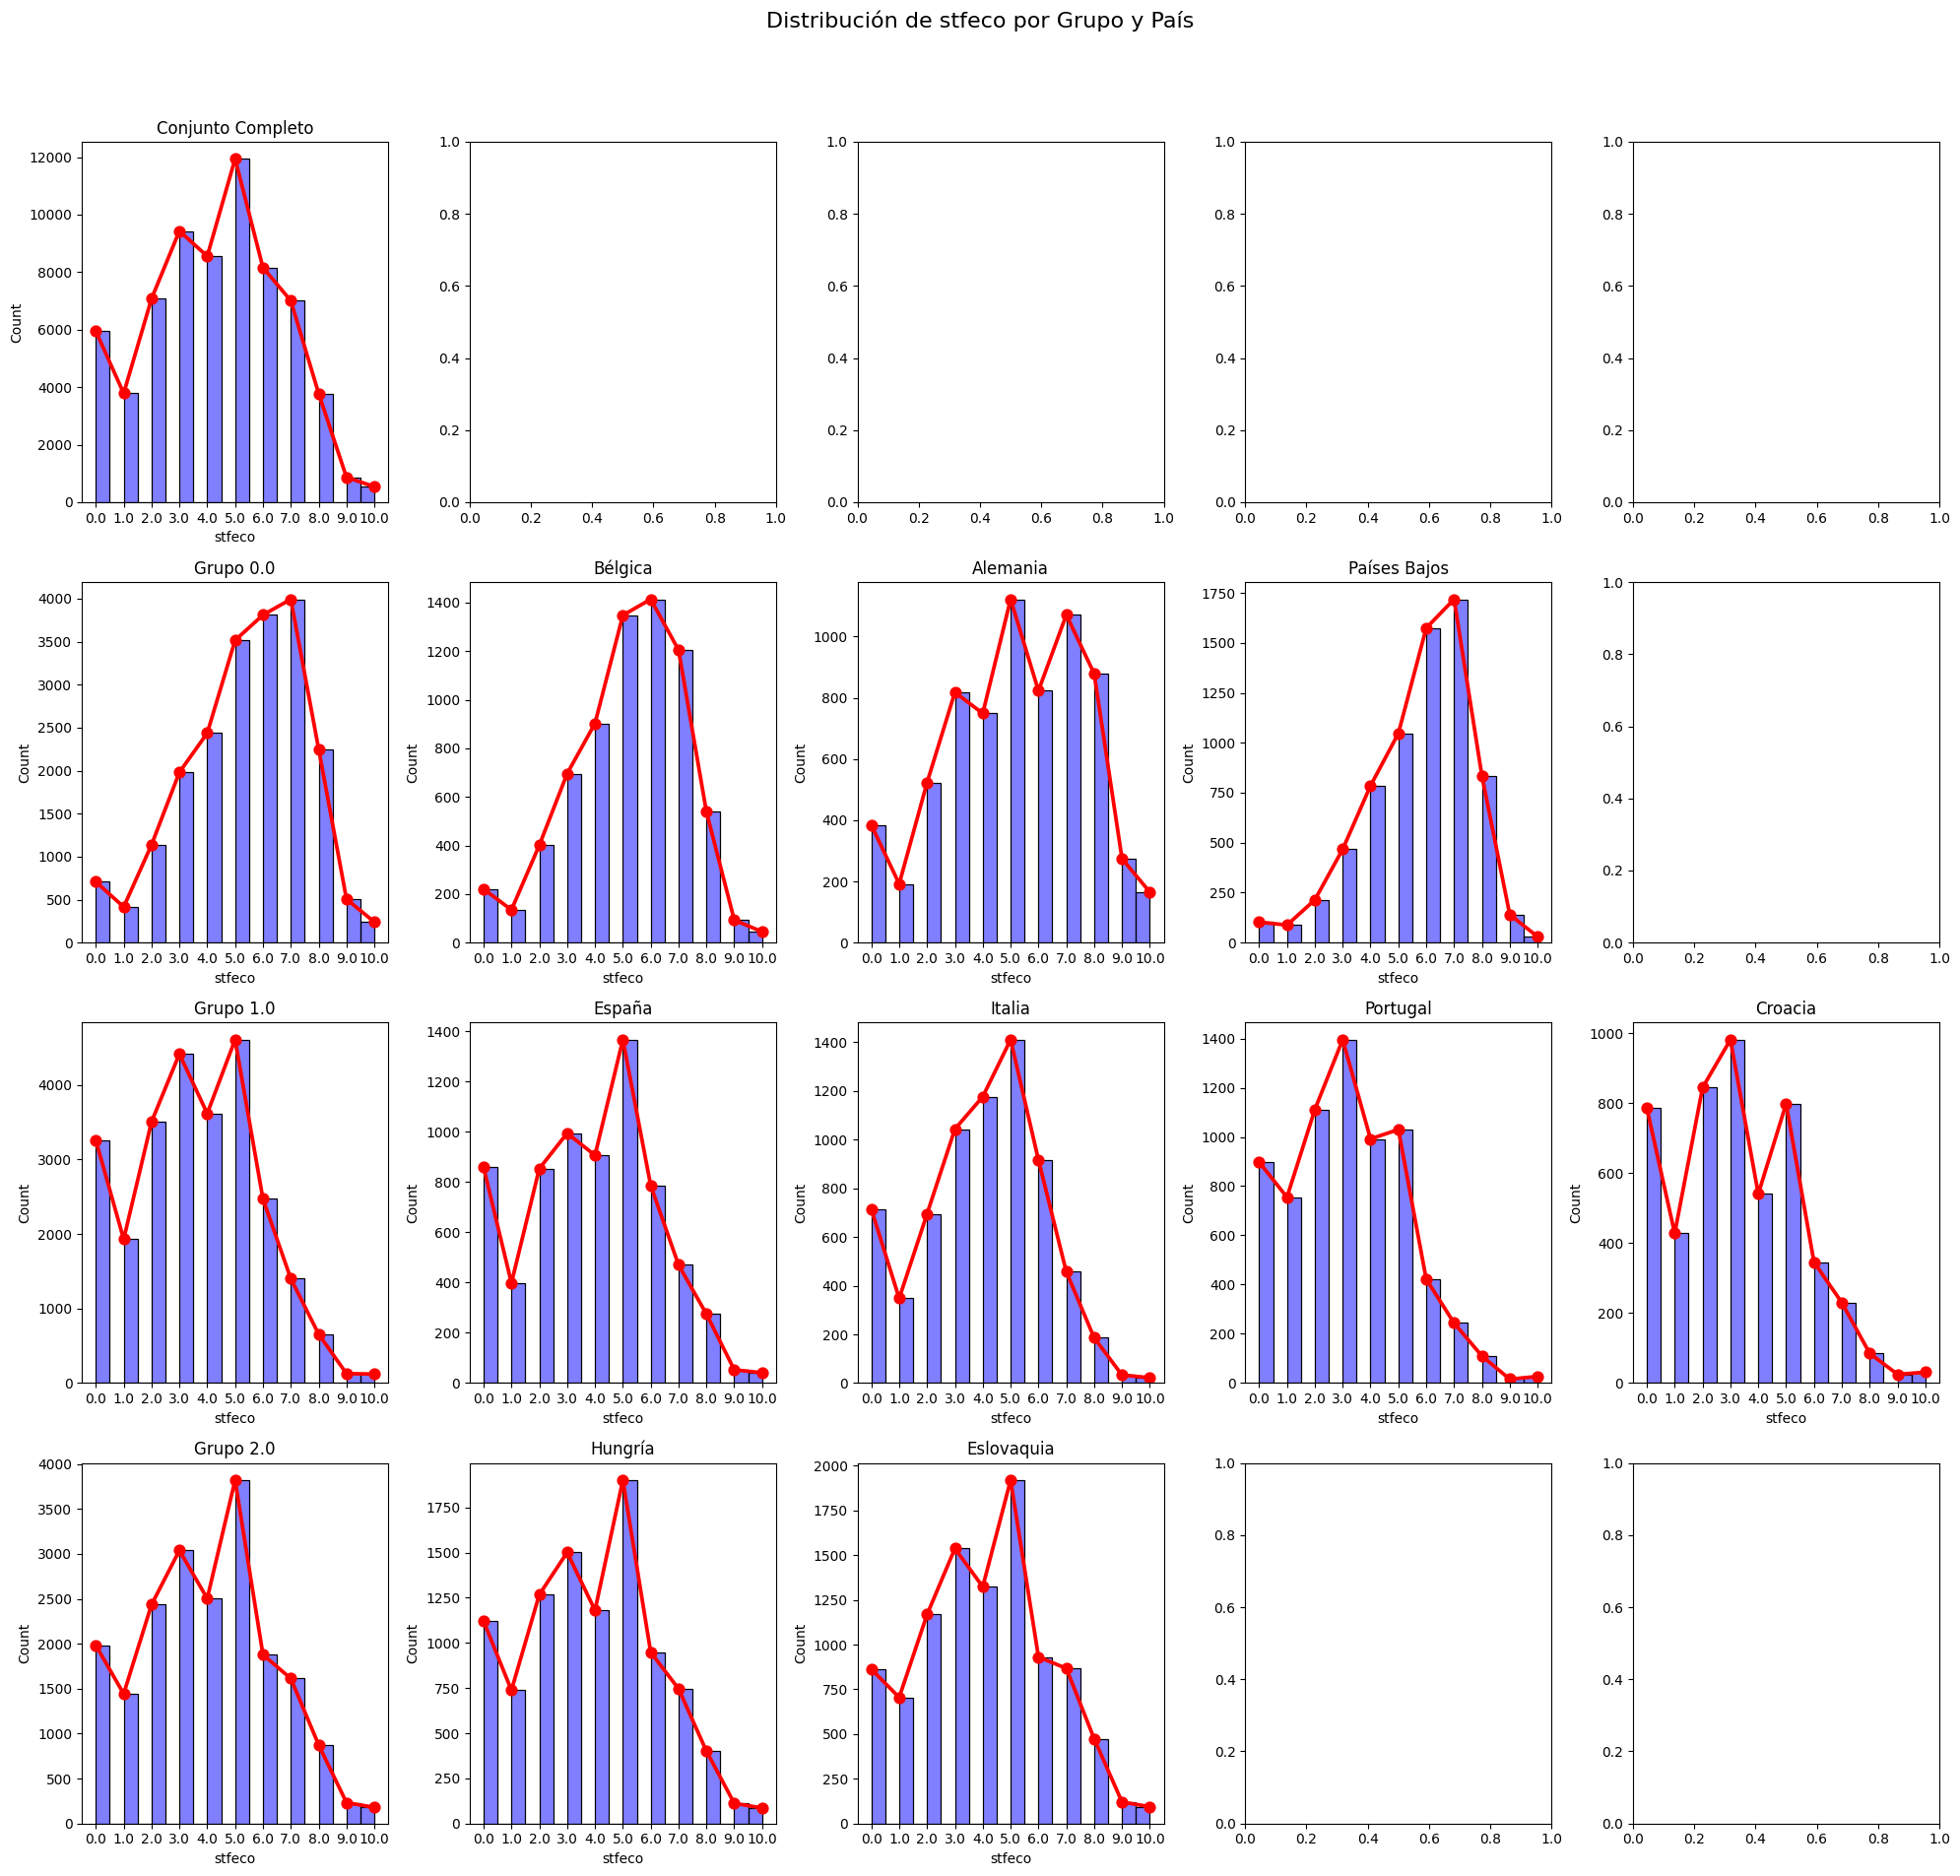

In [15]:
#Variable 'stfeco'
GroupDist(dfeu, 'stfeco')

In [16]:
statsgroup(dfeu, 'stfeco')

Estadísticas para stfeco - Conjunto Completo:
count    67098.000000
mean         4.197651
std          2.359821
min          0.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         10.000000
Name: stfeco, dtype: float64
Moda: 5.0, Frecuencia: 11942
Varianza: 5.568754934328046


Estadísticas para stfeco - Grupo 0.0:
count    21000.000000
mean         5.322381
std          2.148445
min          0.000000
25%          4.000000
50%          6.000000
75%          7.000000
max         10.000000
Name: stfeco, dtype: float64
Moda: 7.0, Frecuencia: 3994
Varianza: 4.6158141317387


Estadísticas para stfeco - País Bélgica (Grupo 0.0):
count    7000.000000
mean        5.127857
std         2.020207
min         0.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        10.000000
Name: stfeco, dtype: float64
Moda: 6.0, Frecuencia: 1414
Varianza: 4.081235584675362


Estadísticas para stfeco - País Alemania (Grupo 0.0):
count    7000.000000
mean    

7-'stfeco': Escala de 0 a 10. 0 siendo muy insatisfecho en el estado de la economia de tu pais, a 10 estando muy satisfecho.
MUY IMPORTANTE, es en esta variable donde se demuestra mi hipotesis de que el nivel economico afecta a la distribucion de las muestras en muchas de las variables del estudio.
La variable discontinua a computo general, describe una funcion/distribucion normal simetrica trimodal, si que es cierto que hay mas muestras en el valor de la media aritmetica y el valor central del rango de la variable.
No se aprecia tanto debido al desbalanceo de muestras del Grupo 0(Paises ricos tienen 2 veces mas muestras que el grupo1 y tres mas que el grupo 2) y ademas este grupo si que estan satisfechos con la situacion economica de su pais, se aprecia en la distribucion asimetrica desplazada positivamente de la media aritmetica del rango de la variable.
Pero conforme bajamos al GRupo1(Media UE) y al Grupo 2(Paises mas pobres de la UE) se aprecia como la distribucion simetrica se bimodaliza y ademas se desplaza el eje del 50% de las muestras a un rango inferior del valor medio de la variable.

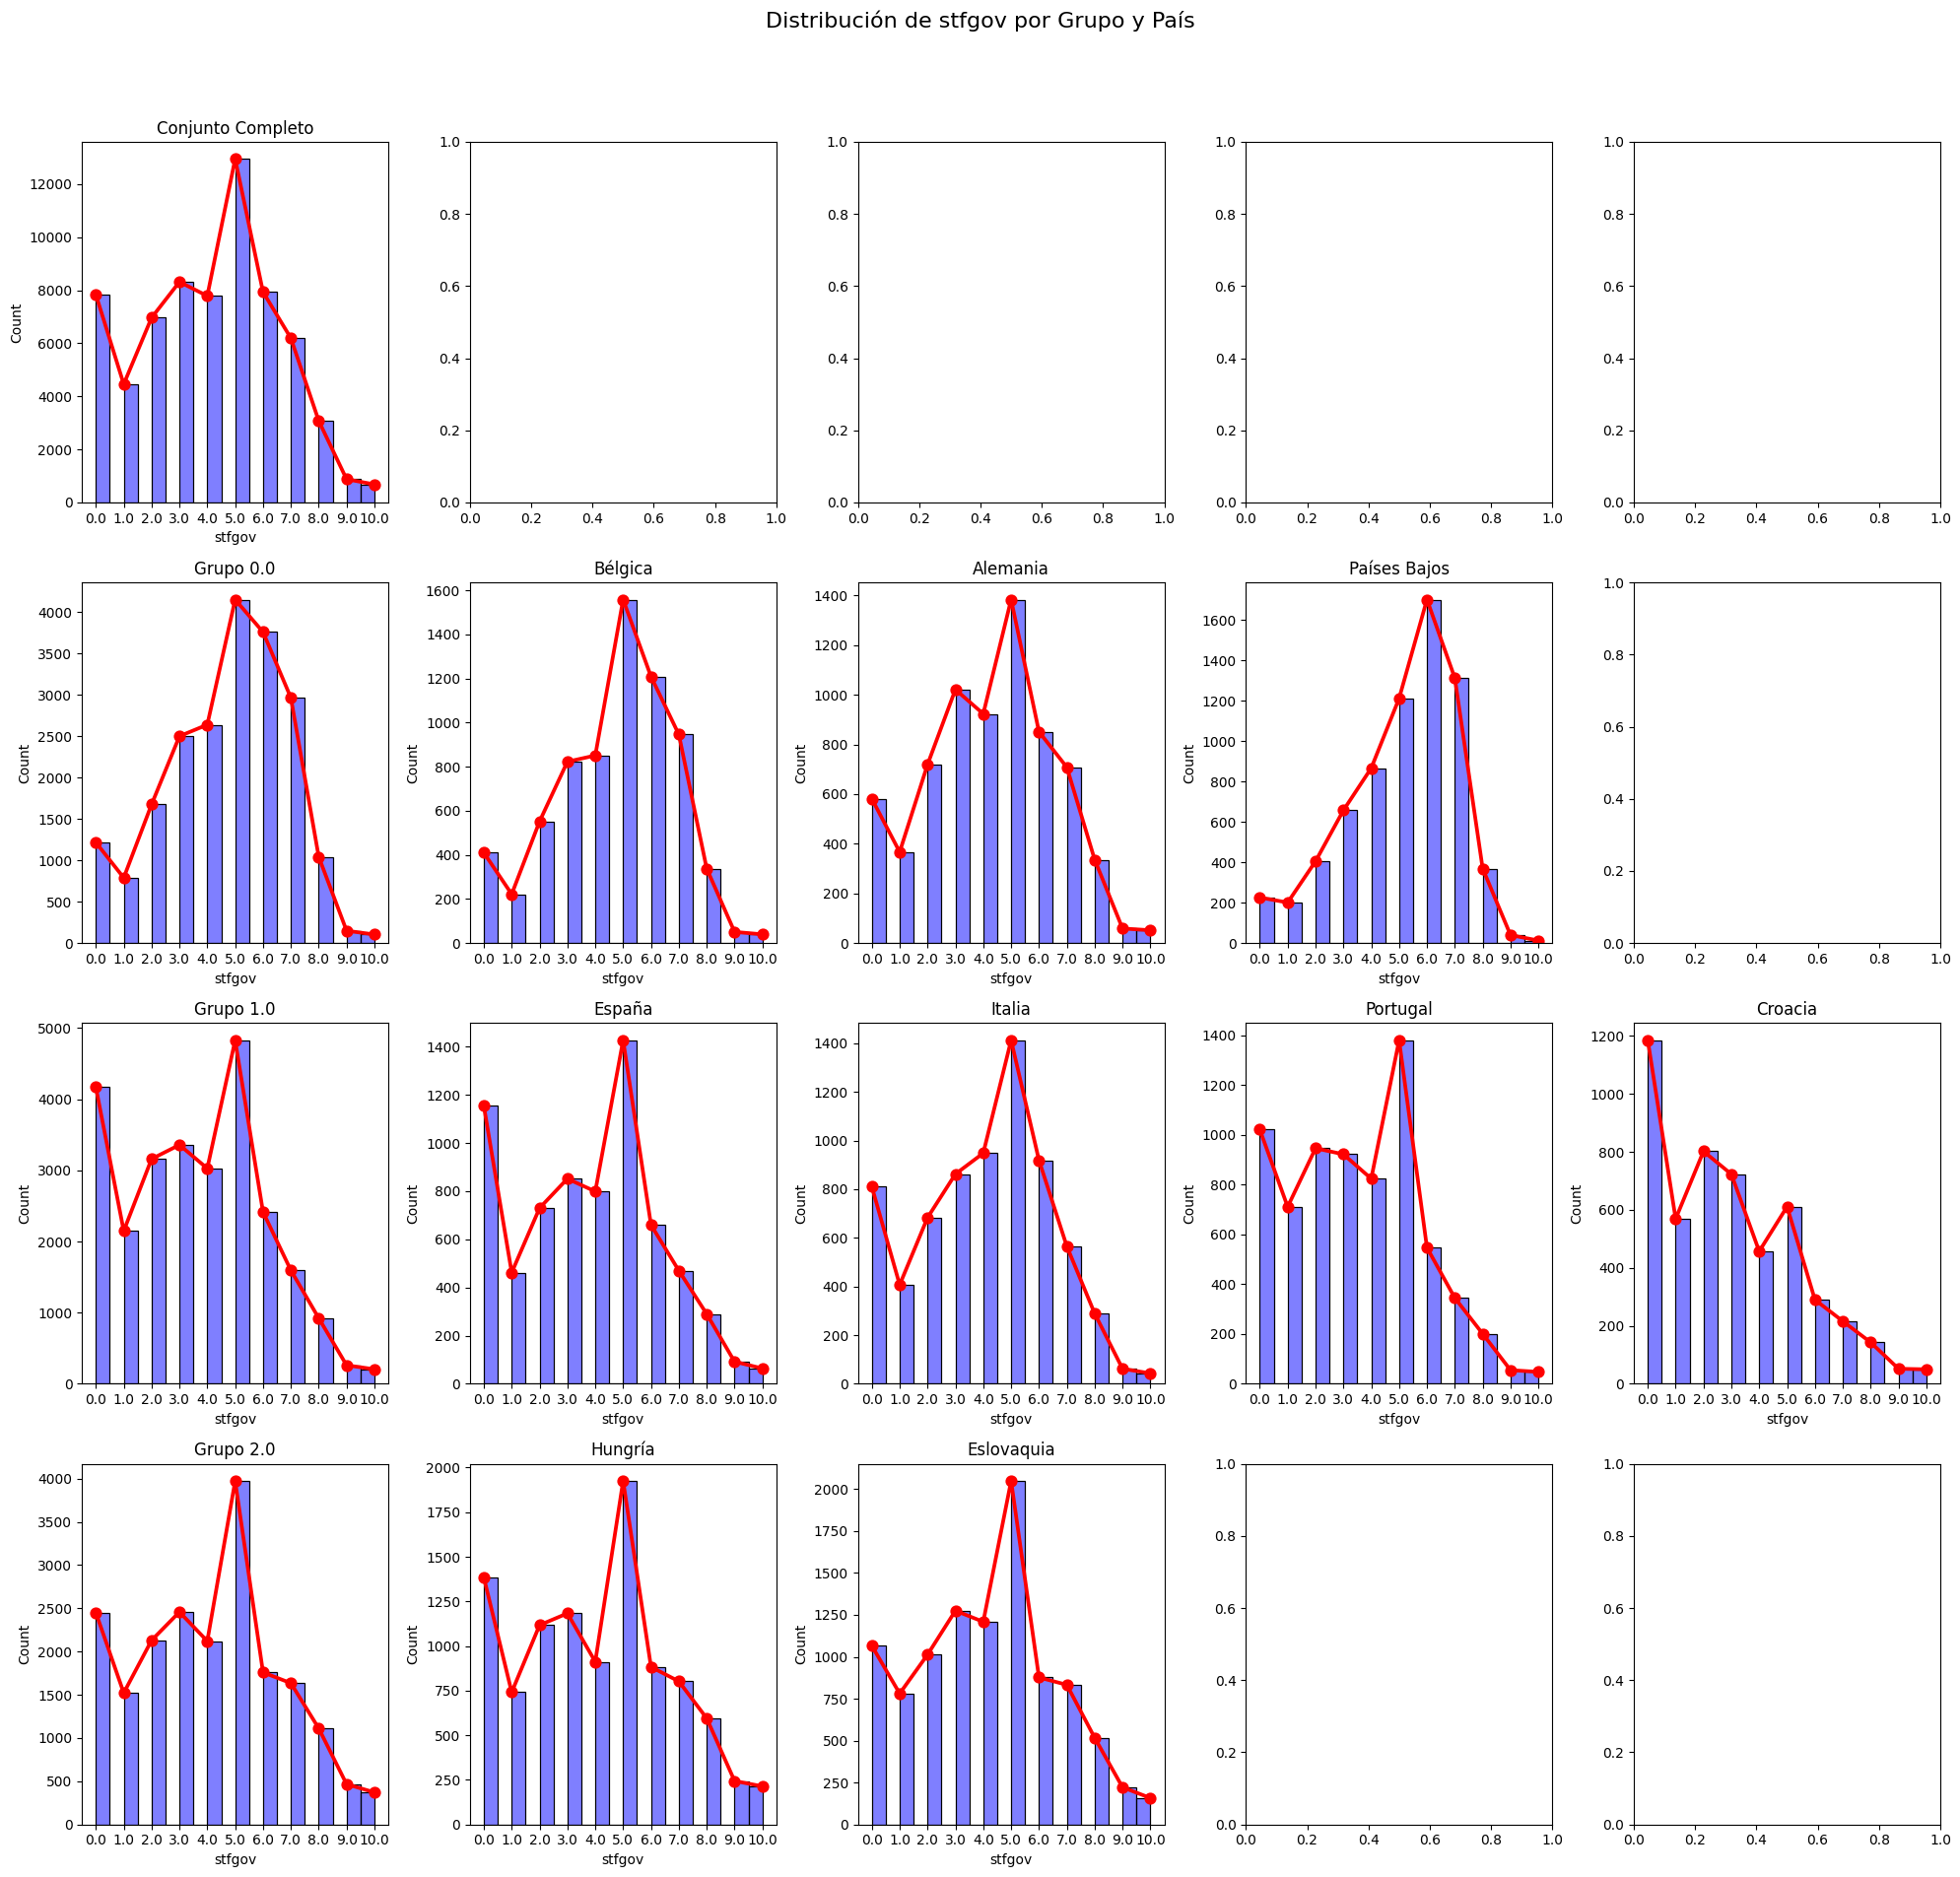

In [17]:
#Variable 'stfgov'
GroupDist(dfeu, 'stfgov')

In [18]:
statsgroup(dfeu, 'stfgov')

Estadísticas para stfgov - Conjunto Completo:
count    67098.000000
mean         4.018257
std          2.435212
min          0.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         10.000000
Name: stfgov, dtype: float64
Moda: 5.0, Frecuencia: 12956
Varianza: 5.930259703480794


Estadísticas para stfgov - Grupo 0.0:
count    21000.000000
mean         4.620524
std          2.158147
min          0.000000
25%          3.000000
50%          5.000000
75%          6.000000
max         10.000000
Name: stfgov, dtype: float64
Moda: 5.0, Frecuencia: 4152
Varianza: 4.6576005637456666


Estadísticas para stfgov - País Bélgica (Grupo 0.0):
count    7000.000000
mean        4.632571
std         2.132186
min         0.000000
25%         3.000000
50%         5.000000
75%         6.000000
max        10.000000
Name: stfgov, dtype: float64
Moda: 5.0, Frecuencia: 1558
Varianza: 4.546217133059826


Estadísticas para stfgov - País Alemania (Grupo 0.0):
count    7000.000000
mean 

8-'stfgov': Escala de 0 a 10, 0 siendo muy insatisfecho con el desempeño del gobierno, a 10 estando satisfecho.
Variable discontinua que a conjunto global de muestras describe una funcion/distribucion normal simetrica.
Se aprecia que en el Grupo1(Media UE), y Grupo 2(Paises pobres) la distribucion se bimodaliza en los dos primeras secciones cuartilicas, restando muestras a las clases que sobrepasan el valor medio del rango de la variable.
Por lo General Cada subconjunto de paises se asemeja a las muestras de cada pais del grupo.


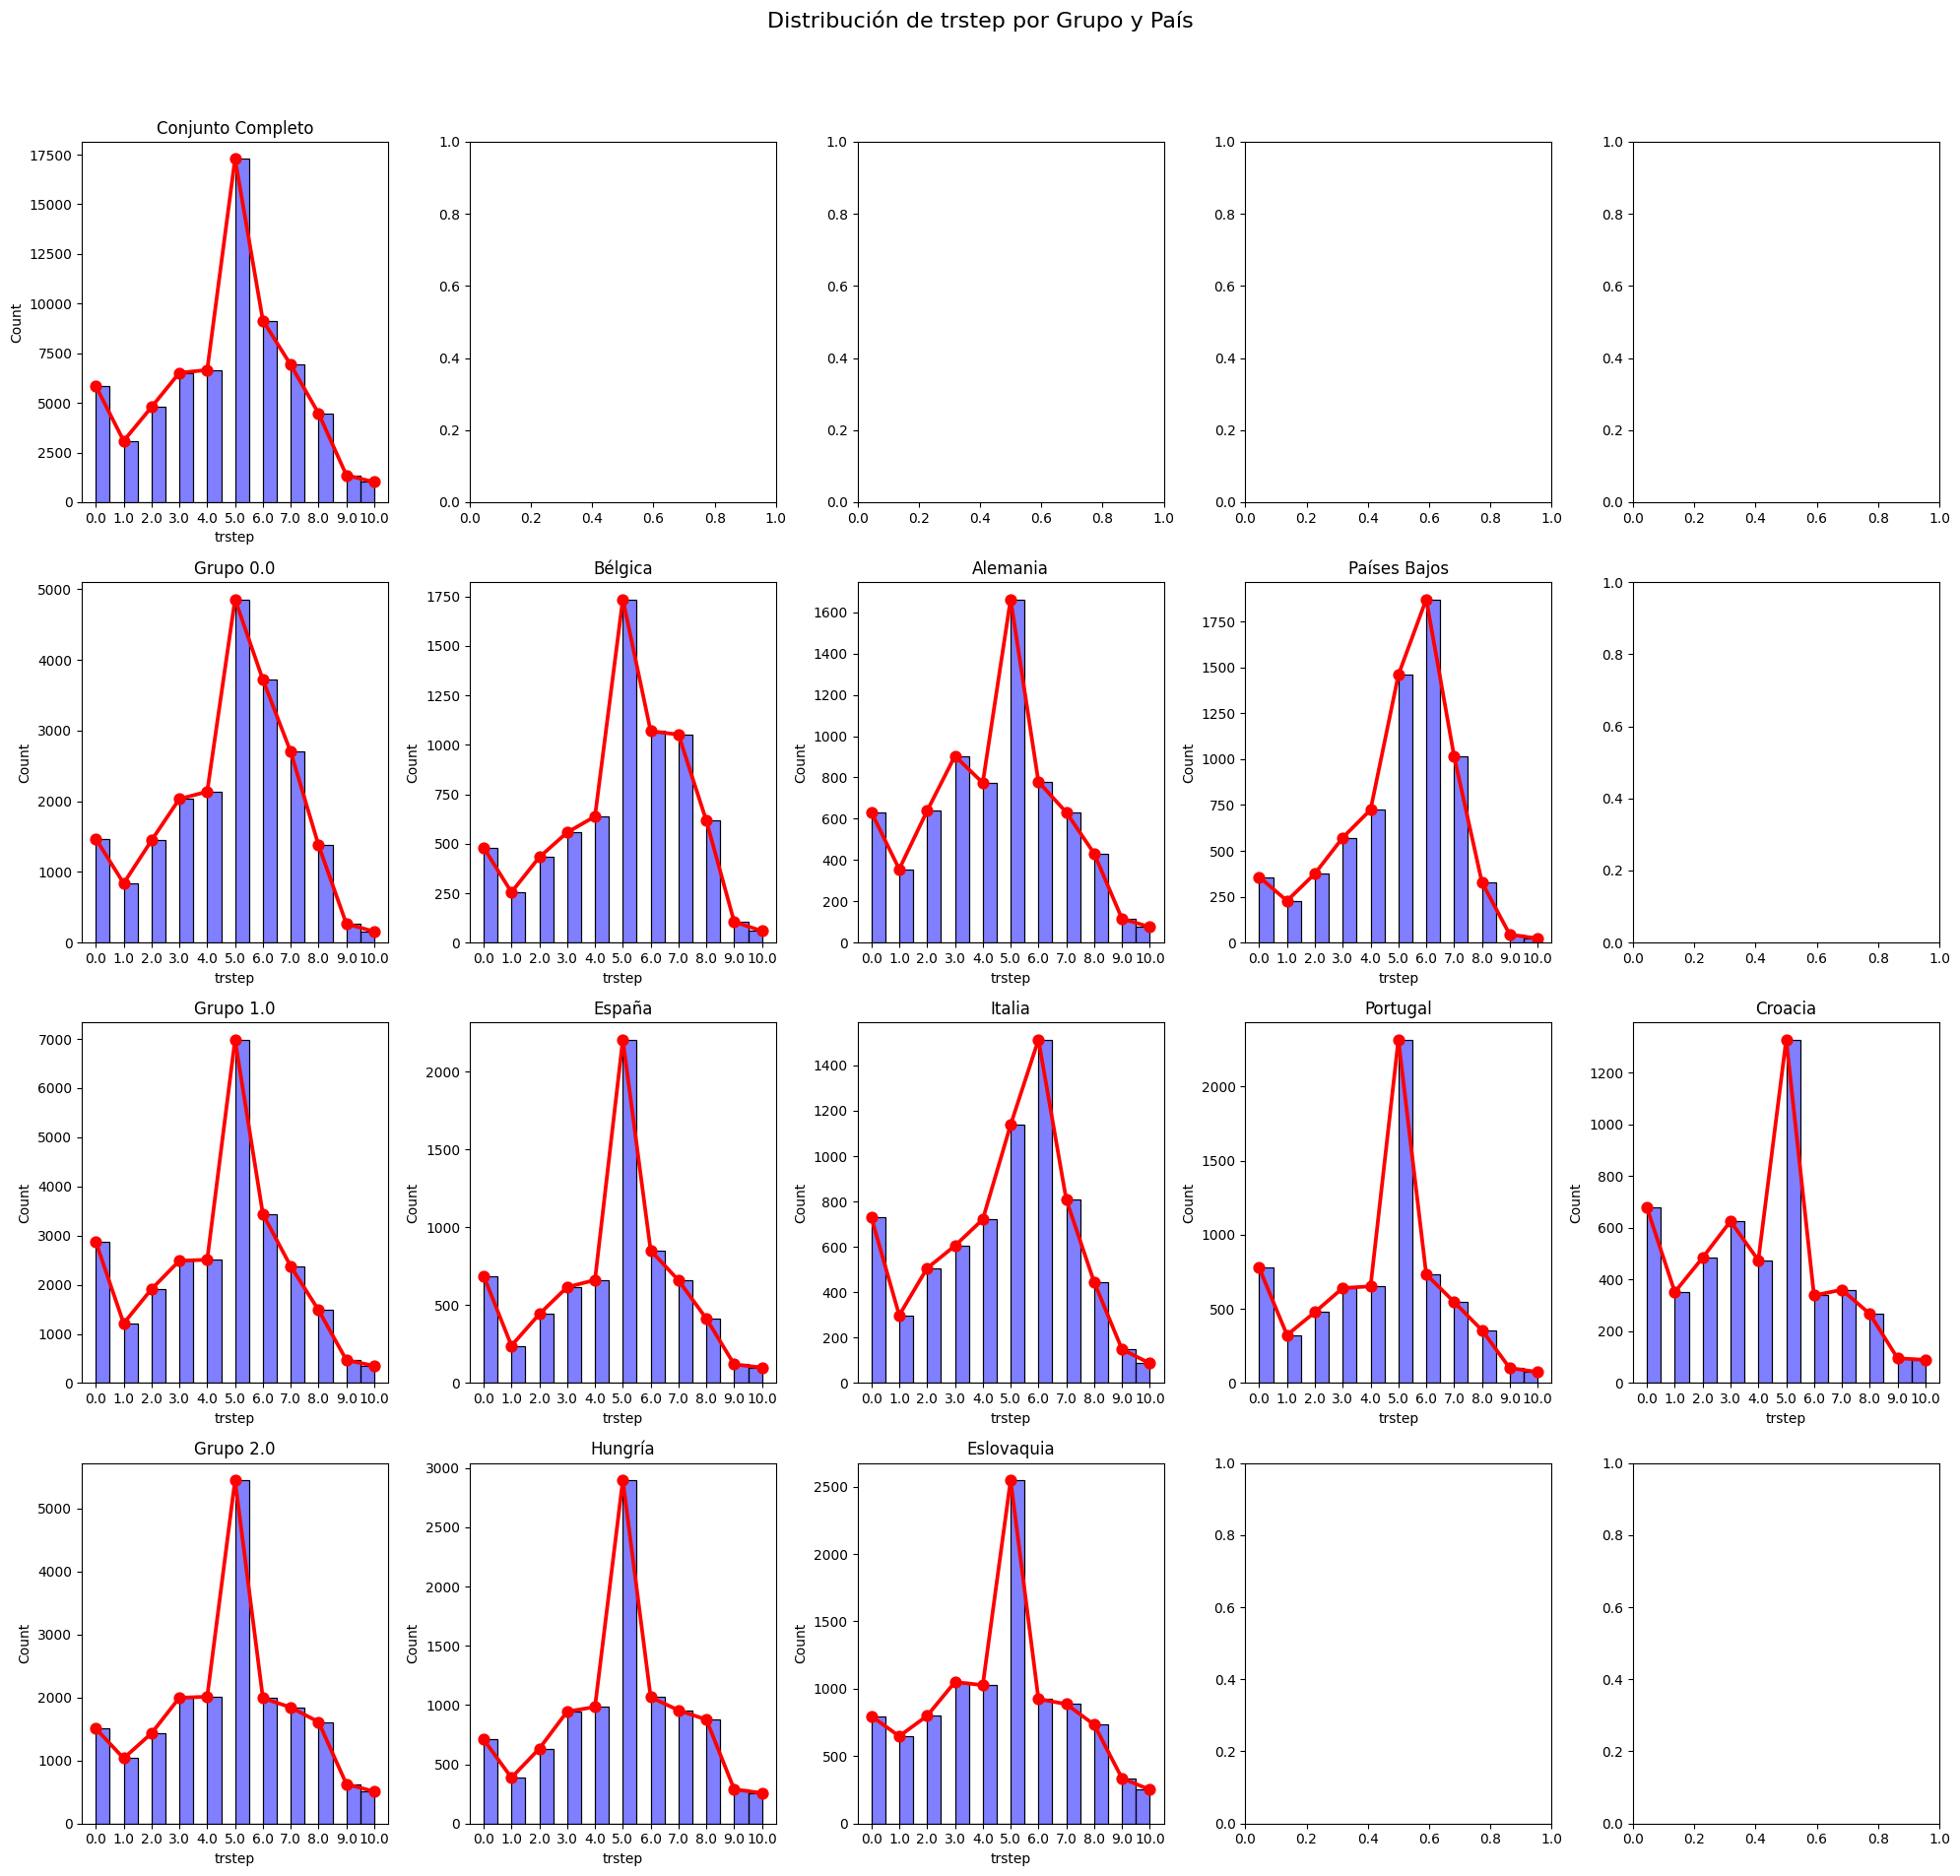

In [19]:
#Variable 'trstep'
GroupDist(dfeu, 'trstep')

In [20]:
statsgroup(dfeu, 'trstep')

Estadísticas para trstep - Conjunto Completo:
count    67098.000000
mean         4.571552
std          2.390300
min          0.000000
25%          3.000000
50%          5.000000
75%          6.000000
max         10.000000
Name: trstep, dtype: float64
Moda: 5.0, Frecuencia: 17290
Varianza: 5.713533817736423


Estadísticas para trstep - Grupo 0.0:
count    21000.000000
mean         4.707238
std          2.254722
min          0.000000
25%          3.000000
50%          5.000000
75%          6.000000
max         10.000000
Name: trstep, dtype: float64
Moda: 5.0, Frecuencia: 4858
Varianza: 5.083770646674784


Estadísticas para trstep - País Bélgica (Grupo 0.0):
count    7000.000000
mean        4.894714
std         2.291682
min         0.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        10.000000
Name: trstep, dtype: float64
Moda: 5.0, Frecuencia: 1736
Varianza: 5.251808033800748


Estadísticas para trstep - País Alemania (Grupo 0.0):
count    7000.000000
mean  

9-'trstep': Escala de 0 a 10, grado de confianza con el parlamento Europeo, 0 siendo inexistente.

Variable discontinua que dibuja una funcion/distribucion normal simetrica, donde la mayor cantidad de muestras se agrupan en el valor medio del rango de la variable.
Por lo general todas las distribuciones de paises y subgrupos tienen un formato muy similar con la variable con el conjunto total de muestras.
Si que es verdad que aumentan levemente las muestras en porcentaje alrededor del valor medio del rango de la variable  conforme los paises son mas pobres pero por lo demas, apenas varia.

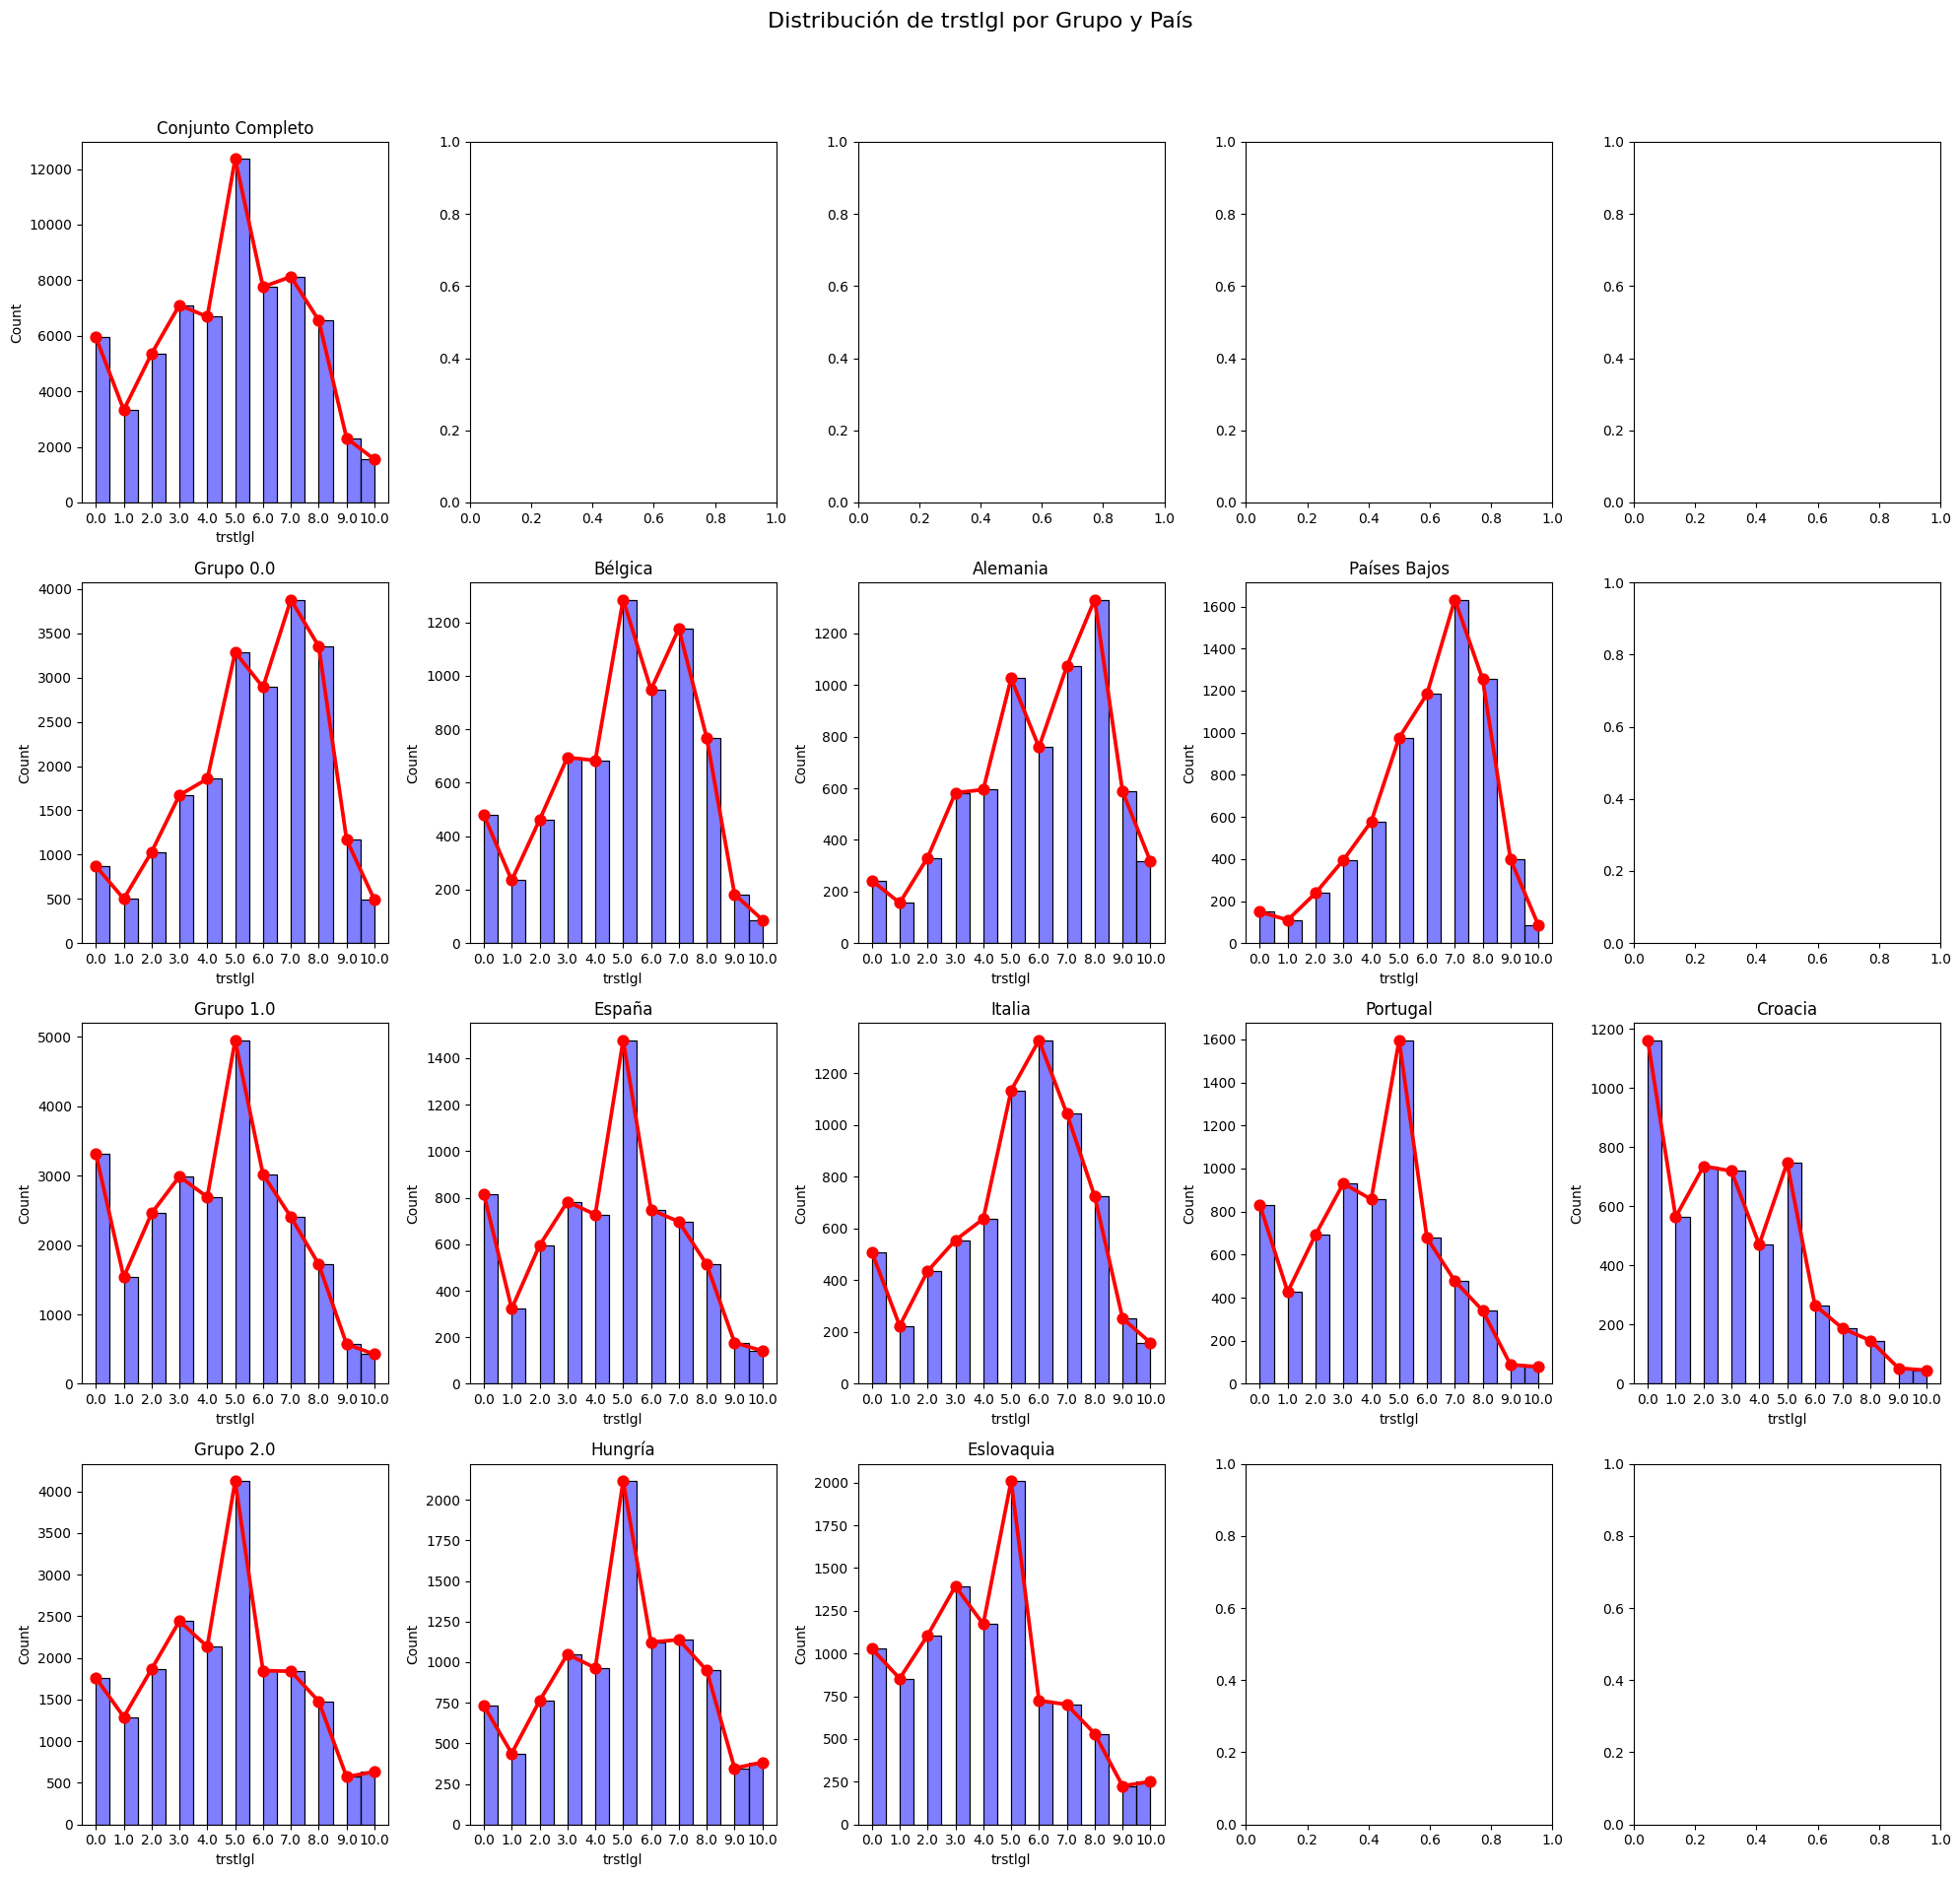

In [21]:
#Variable 'trstlgl'
GroupDist(dfeu, 'trstlgl')

In [22]:
statsgroup(dfeu, 'trstlgl')

Estadísticas para trstlgl - Conjunto Completo:
count    67098.000000
mean         4.711497
std          2.603538
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: trstlgl, dtype: float64
Moda: 5.0, Frecuencia: 12366
Varianza: 6.7784126191891145


Estadísticas para trstlgl - Grupo 0.0:
count    21000.000000
mean         5.627810
std          2.379022
min          0.000000
25%          4.000000
50%          6.000000
75%          7.000000
max         10.000000
Name: trstlgl, dtype: float64
Moda: 7.0, Frecuencia: 3881
Varianza: 5.659743761040775


Estadísticas para trstlgl - País Bélgica (Grupo 0.0):
count    7000.000000
mean        4.997143
std         2.420738
min         0.000000
25%         3.000000
50%         5.000000
75%         7.000000
max        10.000000
Name: trstlgl, dtype: float64
Moda: 5.0, Frecuencia: 1285
Varianza: 5.859971832710795


Estadísticas para trstlgl - País Alemania (Grupo 0.0):
count    7000.00000

10-'trstlgl': Escala de 0 a 10, grado de confianza con el sistema legal-judicial, 0 siendo inexistente.
Variable discontinua que describe con todas las muestras una distribución normal trimodal, predominando en el % de muestras todas aquellas cercanas al valor medio del rango de la variable.
Hay que hacer especial mencion al conjunto de muestras del pais Croaci que por cuestiones históricas y culturales
Hay mucho porcentaje de muestras ubicados en el valor 0 del rango de la variable, provocando una asimetrica negativa respecto a la media del valor de la variable.
La tendencia de la distribucion es trimodalizarse con simetria conforme los grupos de paises son economicamente mas pobres.
En el grupo 0(ricos), el mayor porcentaje de muestras esta desplazado a la derecha respecto al valor medio del rango de la variable.


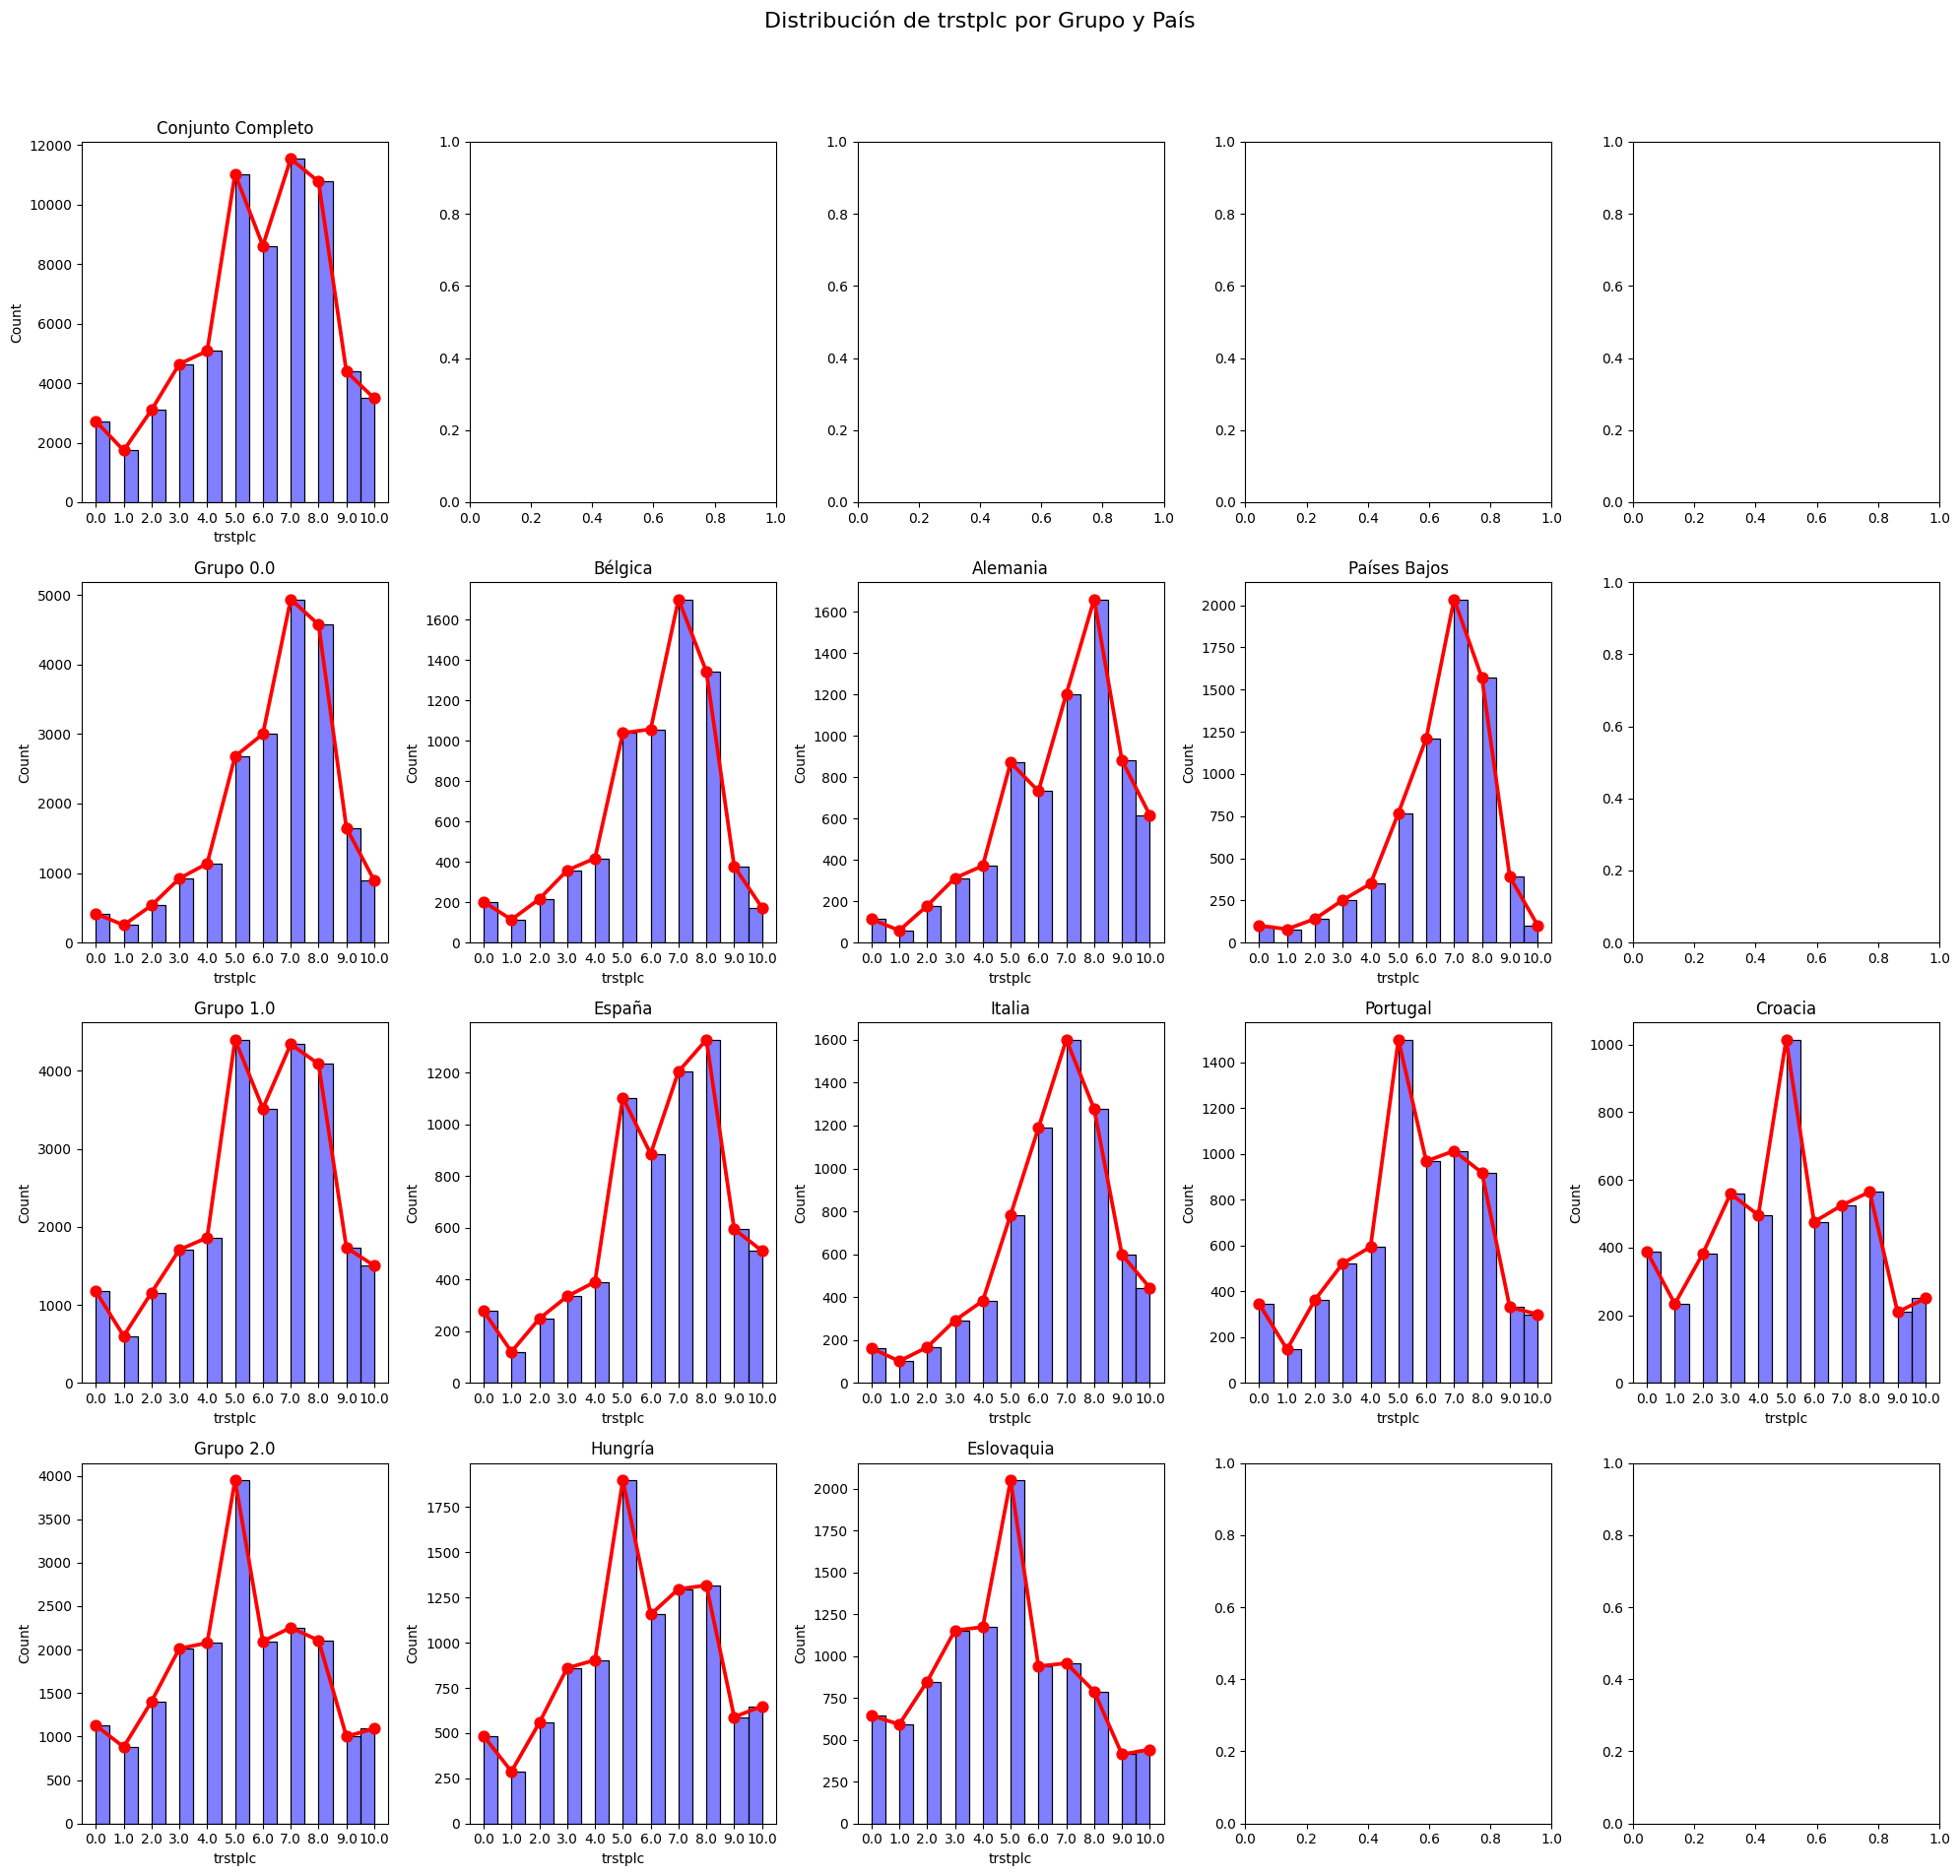

In [23]:
#Var 'trstplc'
GroupDist(dfeu, 'trstplc')

In [24]:
statsgroup(dfeu, 'trstplc')

Estadísticas para trstplc - Conjunto Completo:
count    67098.000000
mean         5.816030
std          2.477275
min          0.000000
25%          4.000000
50%          6.000000
75%          8.000000
max         10.000000
Name: trstplc, dtype: float64
Moda: 7.0, Frecuencia: 11534
Varianza: 6.136892526140705


Estadísticas para trstplc - Grupo 0.0:
count    21000.000000
mean         6.427286
std          2.115785
min          0.000000
25%          5.000000
50%          7.000000
75%          8.000000
max         10.000000
Name: trstplc, dtype: float64
Moda: 7.0, Frecuencia: 4938
Varianza: 4.476544849074445


Estadísticas para trstplc - País Bélgica (Grupo 0.0):
count    7000.000000
mean        6.087429
std         2.162709
min         0.000000
25%         5.000000
50%         7.000000
75%         8.000000
max        10.000000
Name: trstplc, dtype: float64
Moda: 7.0, Frecuencia: 1701
Varianza: 4.677310146347438


Estadísticas para trstplc - País Alemania (Grupo 0.0):
count    7000.000000

12-'trstplt': Escala de 0 a 10, grado de confianza con las personas polítcas, 0 siendo inexistente.
Variable discontinua que con su conjunto global de muestras describe describe una funcion/distribucion asimetrica bimodal positiva
(su mayor grueso de muestras esta desplazado positivamente respecto al valor medio del rango de la variable) Cada subconjunto de muestras imprime una distribucion distinta si vamos en sentido descendente del grupo de paises, la distribucion simetrizarse desplazandose el mayor grueso de muestras al valor medio del rango de la variable tambien se aprecia la bimodalizacion de las muestras. Debido al desbalance de meustras respecto el grupo 0 a los otros dos grupos , la distribucion general permanece algo desplazada a la derecha respecto aun eje de simetria del rango de la variable.

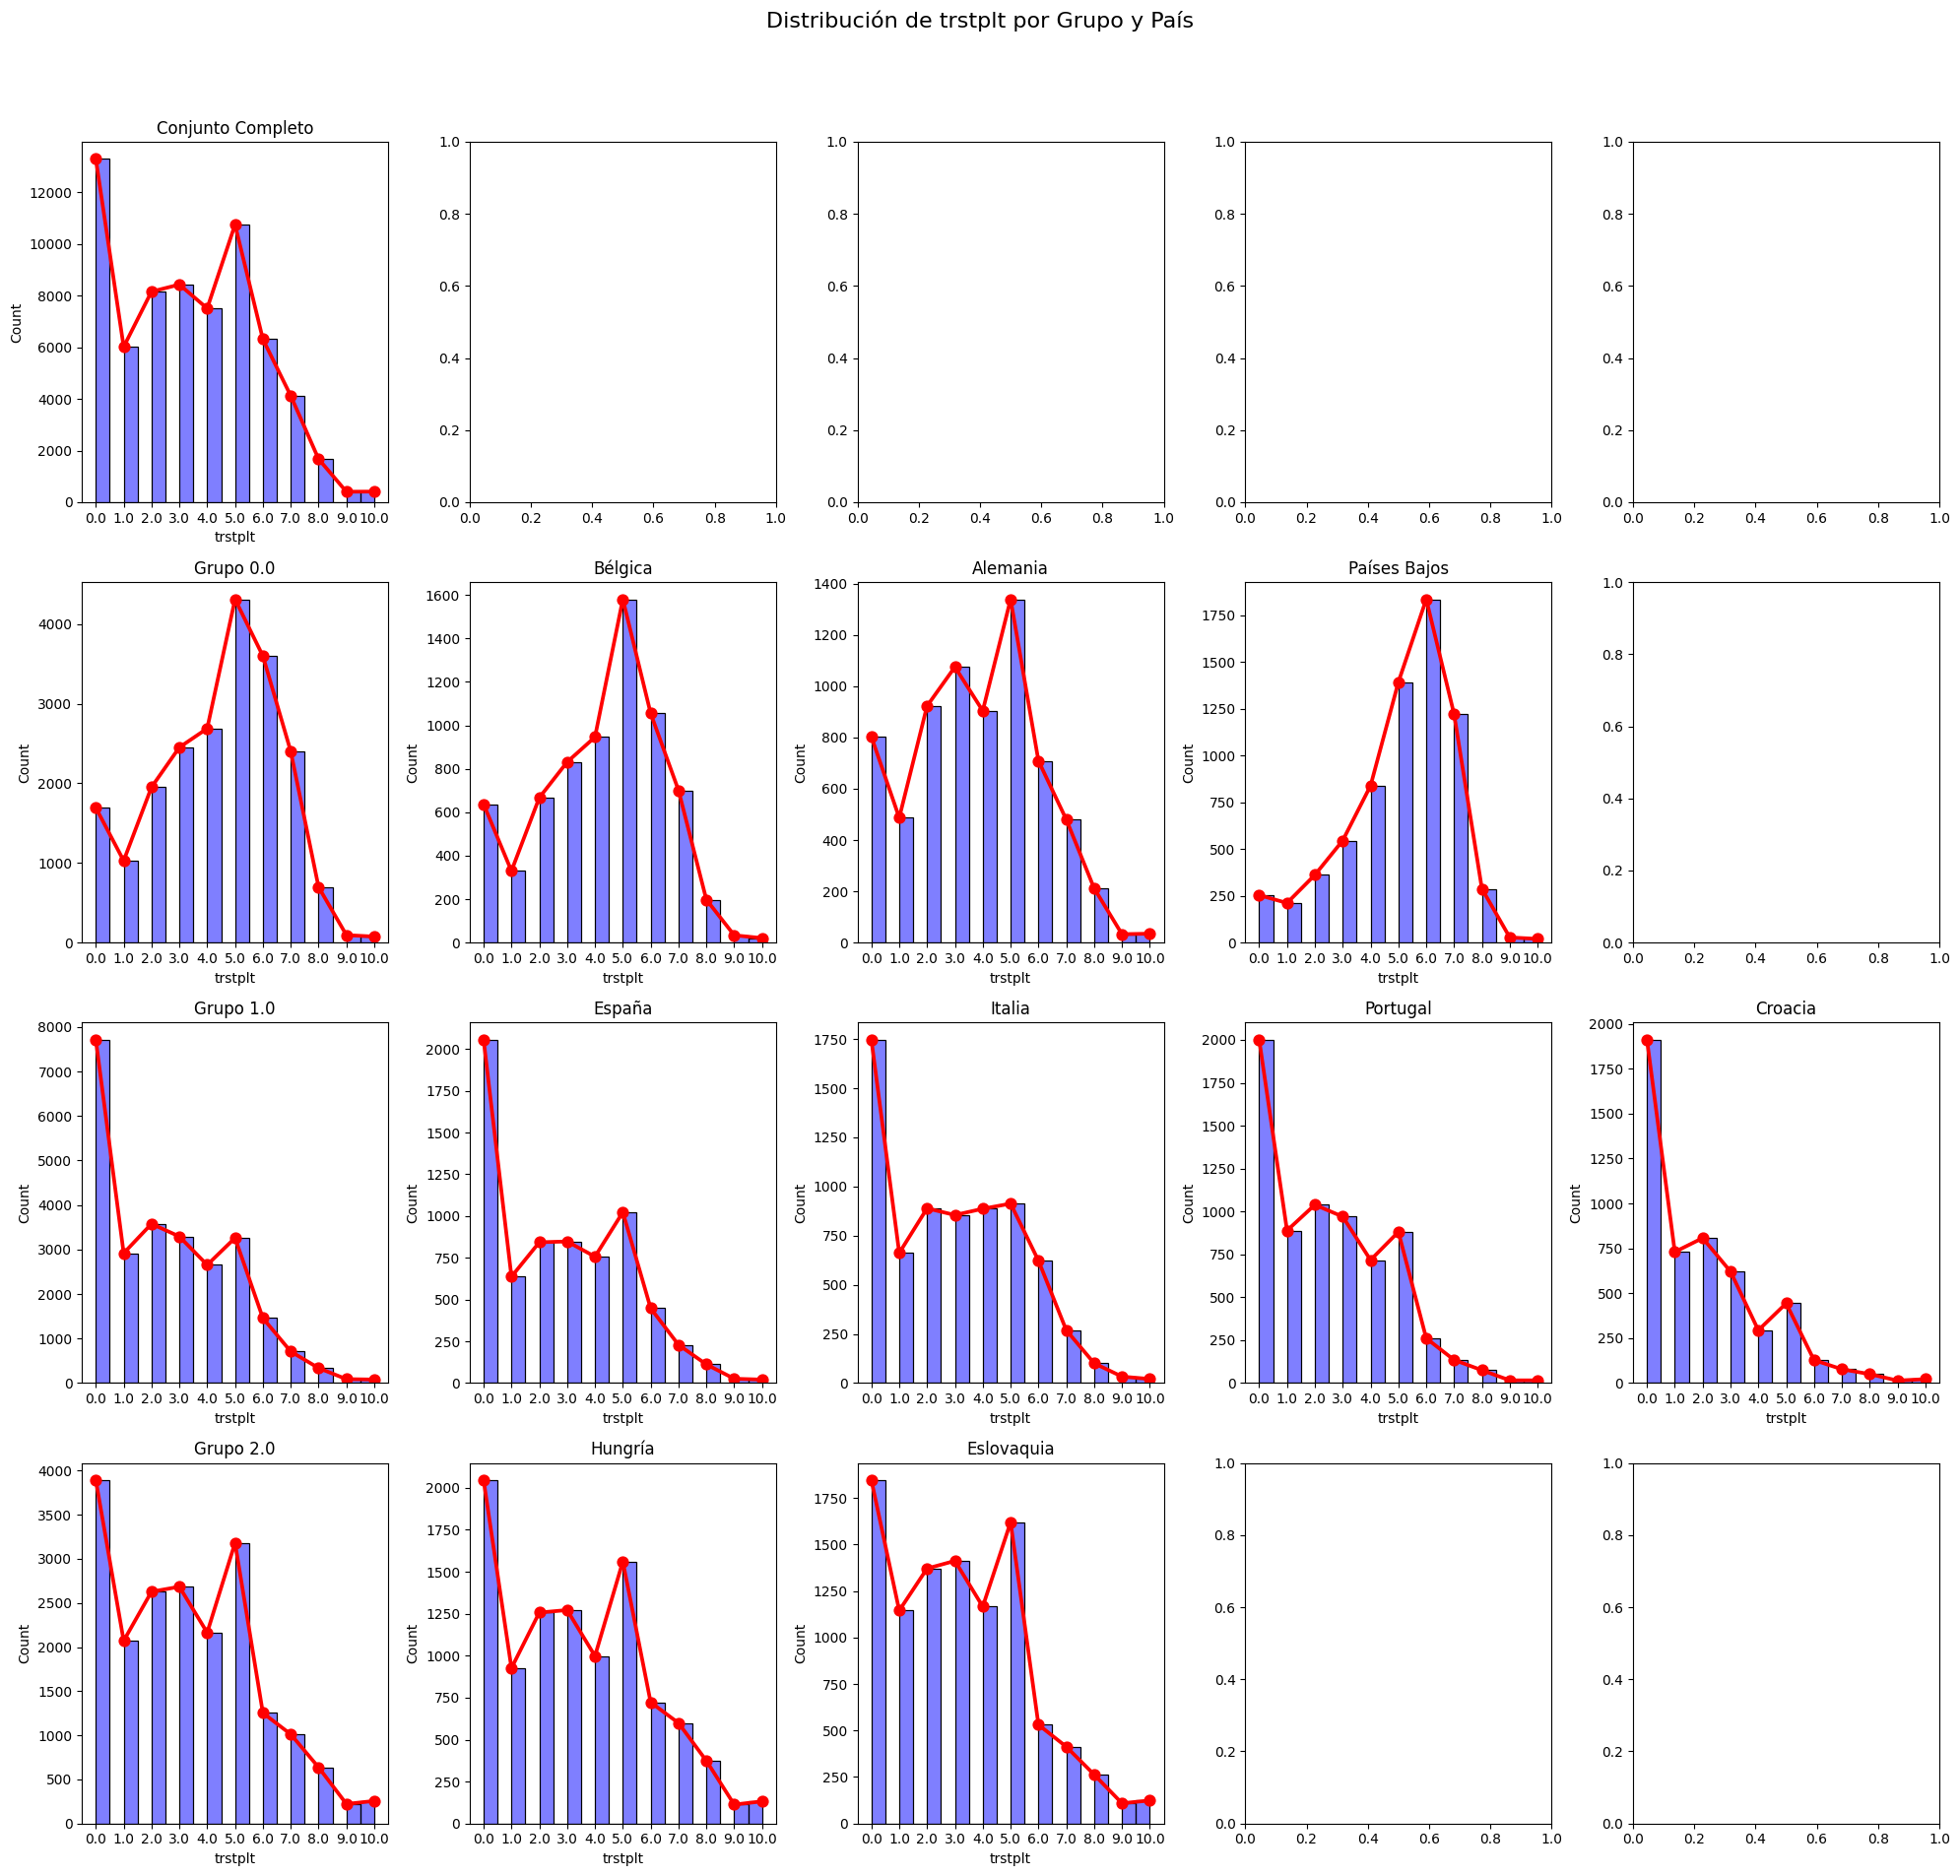

In [25]:
#Variable 'trstplt'
GroupDist(dfeu, 'trstplt')

In [26]:
statsgroup(dfeu, 'trstplt')

Estadísticas para trstplt - Conjunto Completo:
count    67098.000000
mean         3.268905
std          2.432624
min          0.000000
25%          1.000000
50%          3.000000
75%          5.000000
max         10.000000
Name: trstplt, dtype: float64
Moda: 0.0, Frecuencia: 13301
Varianza: 5.917658669907405


Estadísticas para trstplt - Grupo 0.0:
count    21000.000000
mean         4.296429
std          2.197429
min          0.000000
25%          3.000000
50%          5.000000
75%          6.000000
max         10.000000
Name: trstplt, dtype: float64
Moda: 5.0, Frecuencia: 4312
Varianza: 4.828693373153823


Estadísticas para trstplt - País Bélgica (Grupo 0.0):
count    7000.000000
mean        4.168286
std         2.182742
min         0.000000
25%         3.000000
50%         5.000000
75%         6.000000
max        10.000000
Name: trstplt, dtype: float64
Moda: 5.0, Frecuencia: 1580
Varianza: 4.764360541301818


Estadísticas para trstplt - País Alemania (Grupo 0.0):
count    7000.000000

12-'trstplt': Escala de 0 a 10, grado de confianza con las personas polítcas, 0 siendo inexistente.

Variable discontinua que en conjunto global describe una funcion asimetrica bimodal, donde el gran grueso de las muestras estan en el primer y segundo cuartílico.
Se aprecia claramente que los grupos 1 y 2 de paises son los que afectan en la distribucion, acercando el conjunto global de las muestras al valor mas cercano a 0 del rango de la variable.
El primer grupo en cambio, sin entrar en criterios de significado dibujan una funcion simetrica respecto al rango del valor de la variable.

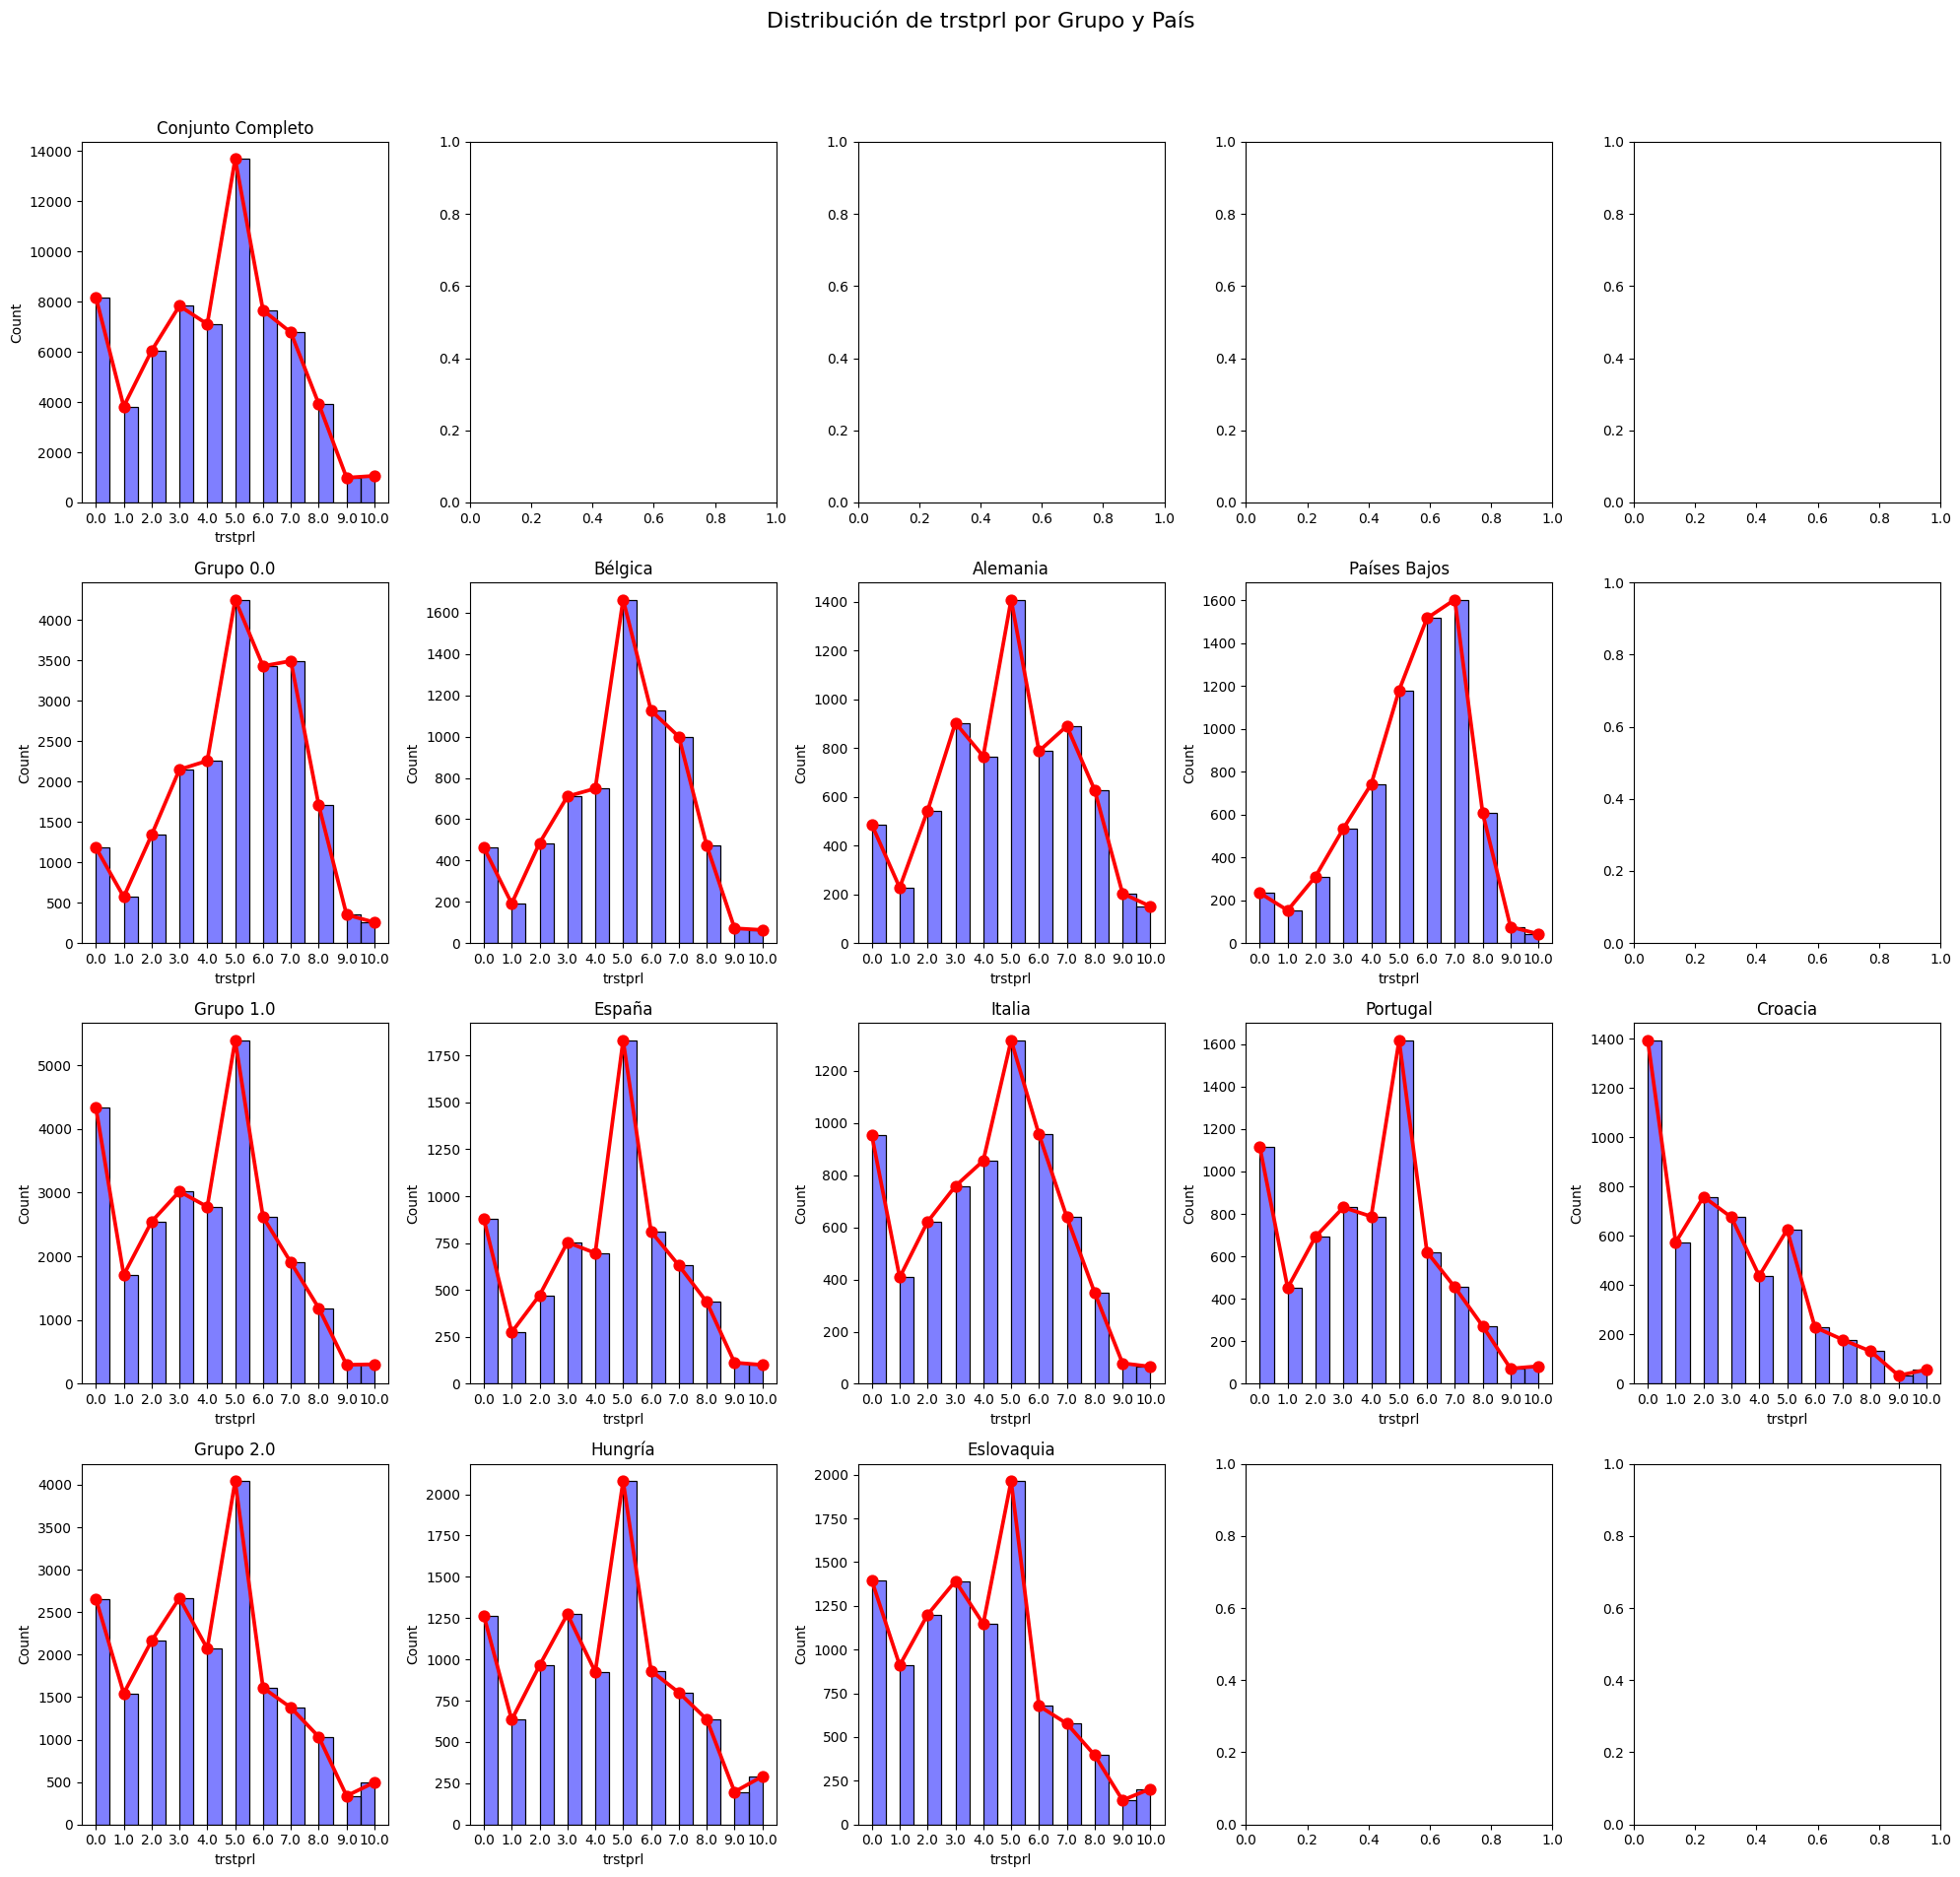

In [27]:
GroupDist(dfeu,'trstprl')

In [28]:
statsgroup(dfeu, 'trstprl')

Estadísticas para trstprl - Conjunto Completo:
count    67098.000000
mean         4.182151
std          2.520239
min          0.000000
25%          2.000000
50%          5.000000
75%          6.000000
max         10.000000
Name: trstprl, dtype: float64
Moda: 5.0, Frecuencia: 13690
Varianza: 6.351606548912144


Estadísticas para trstprl - Grupo 0.0:
count    21000.000000
mean         4.974238
std          2.252027
min          0.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: trstprl, dtype: float64
Moda: 5.0, Frecuencia: 4254
Varianza: 5.071625449284433


Estadísticas para trstprl - País Bélgica (Grupo 0.0):
count    7000.000000
mean        4.777857
std         2.216834
min         0.000000
25%         3.000000
50%         5.000000
75%         6.000000
max        10.000000
Name: trstprl, dtype: float64
Moda: 5.0, Frecuencia: 1664
Varianza: 4.914354601677791


Estadísticas para trstprl - País Alemania (Grupo 0.0):
count    7000.000000

13-'trstprl': Escala de 0 a 10, grado de confianza con el parlamento nacional, 0 siendo inexistente.

Variable discontinua muy similar a la anterior. No ofrece mucha significancia al dataset.

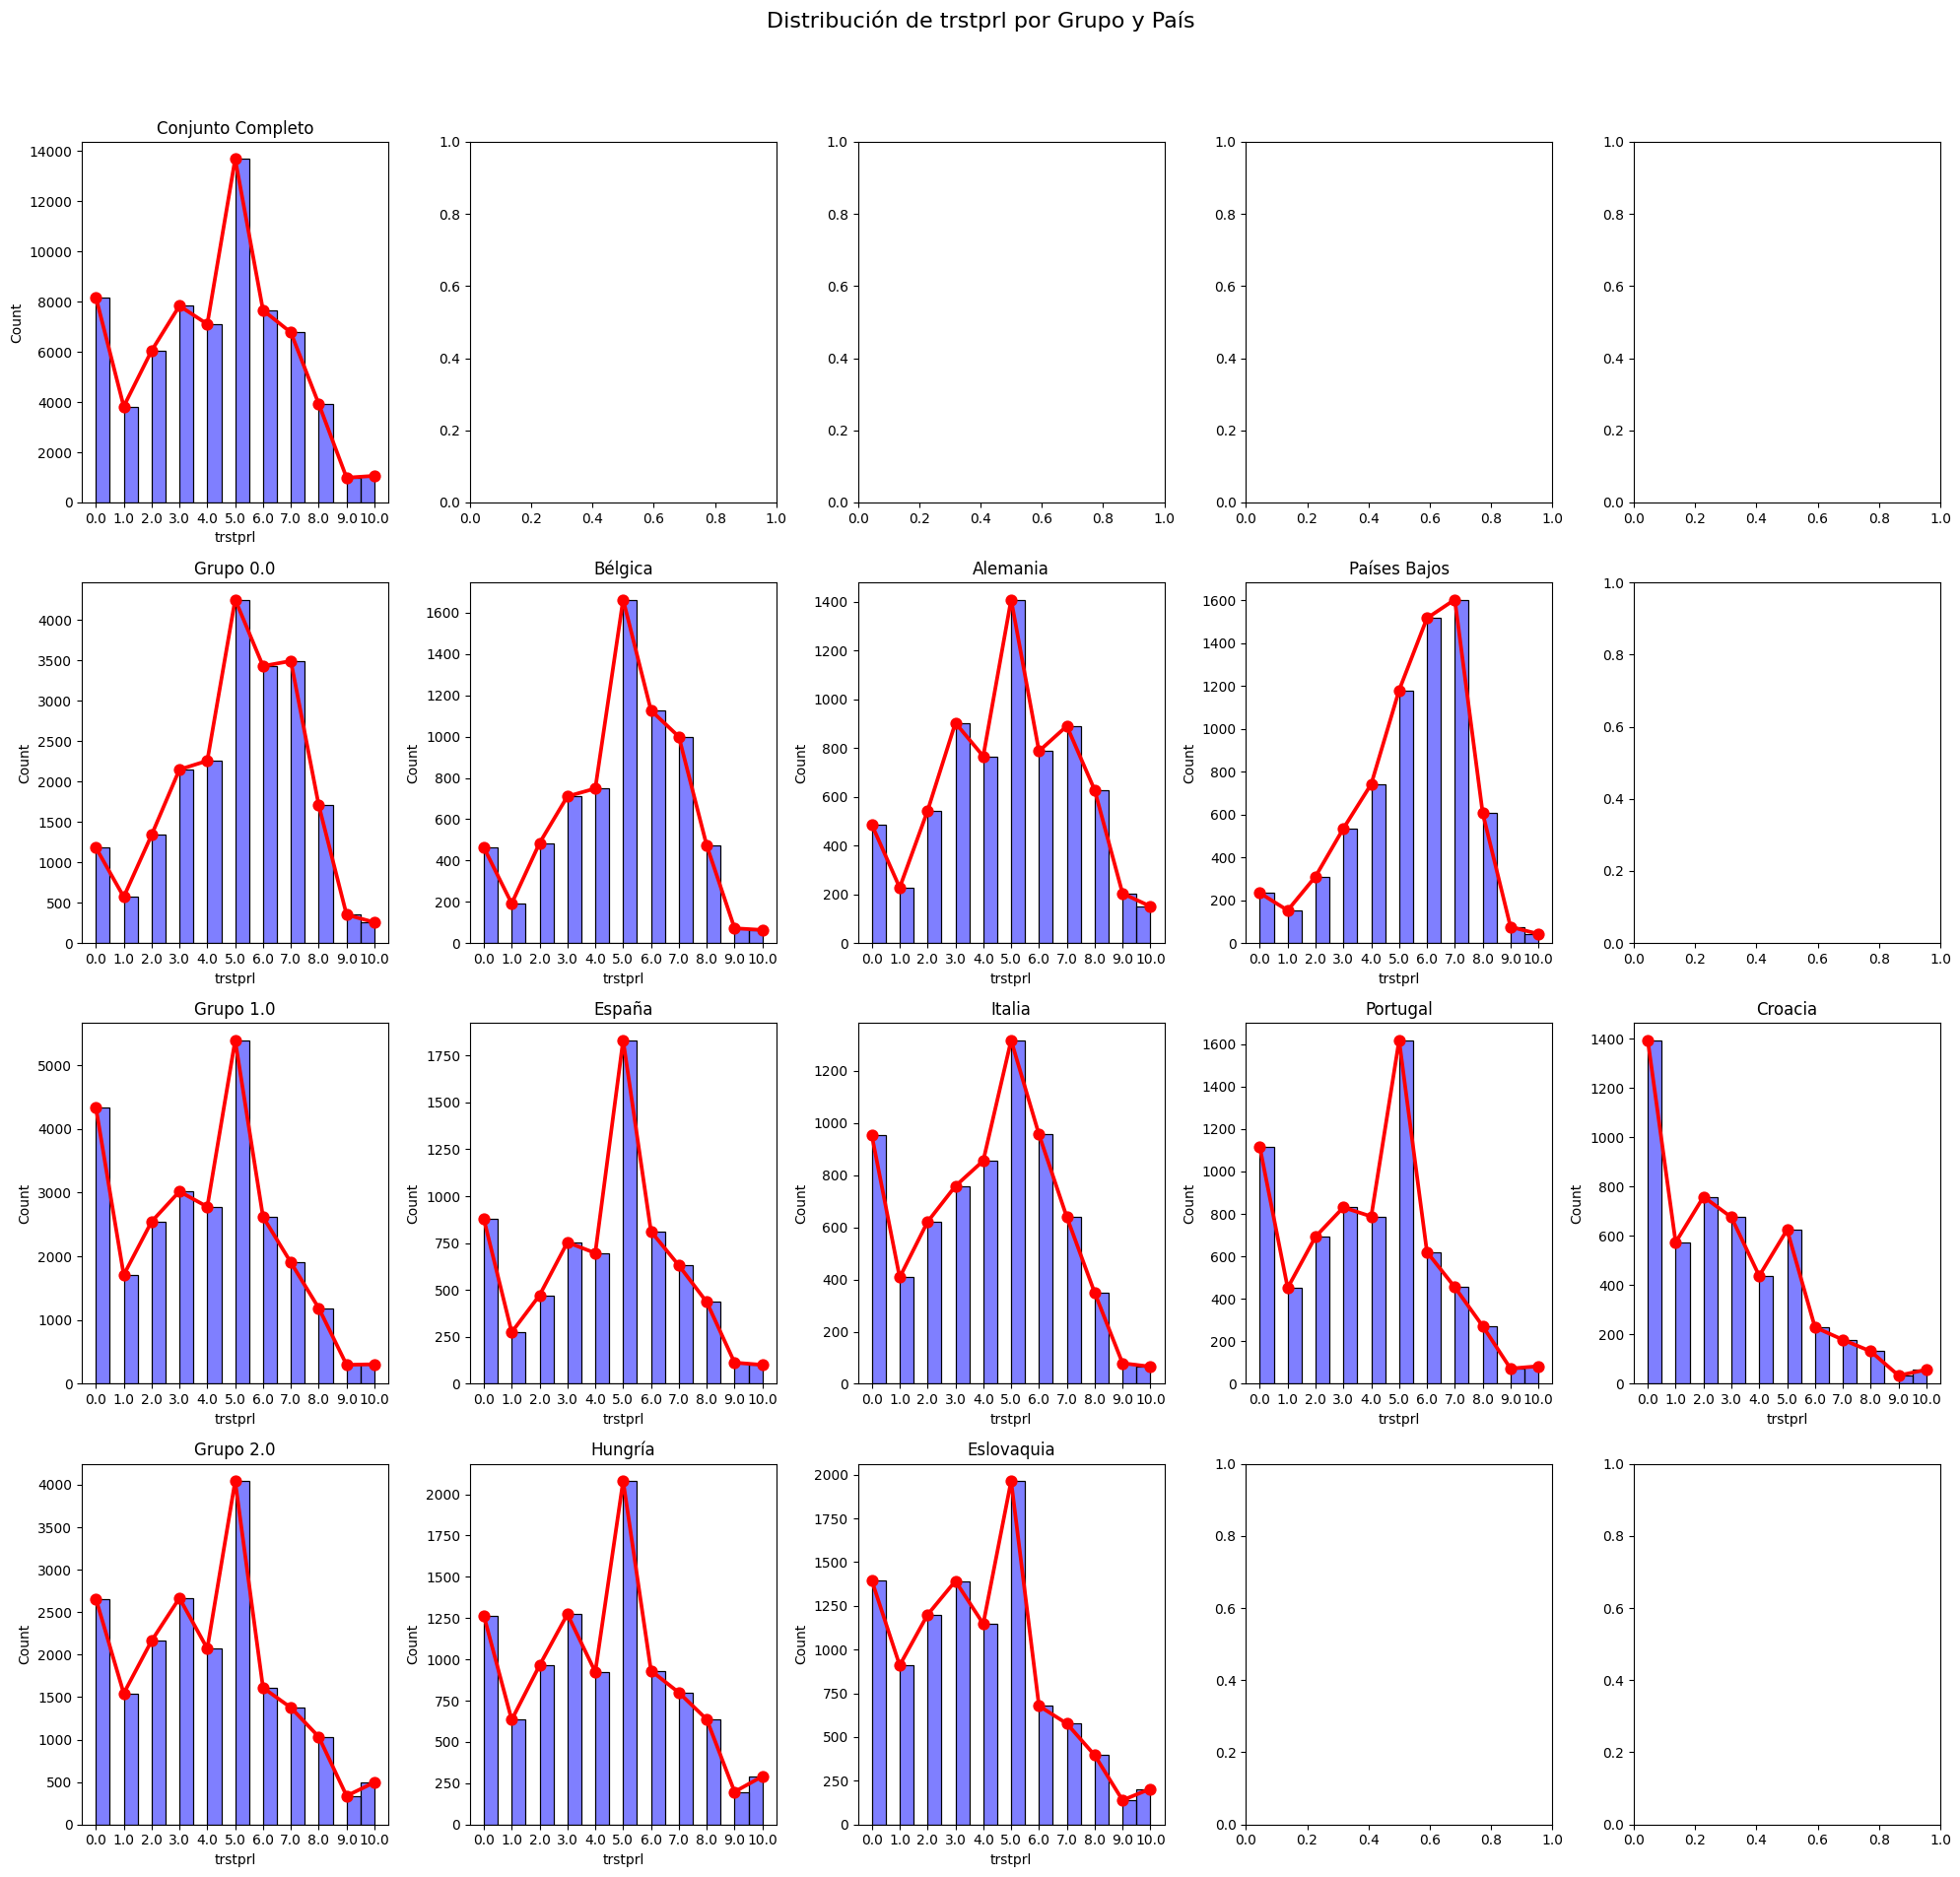

Estadísticas para trstprt - Conjunto Completo:
count    67098.000000
mean         3.189022
std          2.432491
min          0.000000
25%          1.000000
50%          3.000000
75%          5.000000
max         10.000000
Name: trstprt, dtype: float64
Moda: 0.0, Frecuencia: 14712
Varianza: 5.9170102035179415


Estadísticas para trstprt - Grupo 0.0:
count    21000.000000
mean         4.401095
std          2.071356
min          0.000000
25%          3.000000
50%          5.000000
75%          6.000000
max         10.000000
Name: trstprt, dtype: float64
Moda: 5.0, Frecuencia: 5350
Varianza: 4.290517396520016


Estadísticas para trstprt - País Bélgica (Grupo 0.0):
count    7000.000000
mean        4.203714
std         2.068532
min         0.000000
25%         3.000000
50%         5.000000
75%         5.000000
max        10.000000
Name: trstprt, dtype: float64
Moda: 5.0, Frecuencia: 2169
Varianza: 4.278826036372543


Estadísticas para trstprt - País Alemania (Grupo 0.0):
count    7000.00000

In [29]:
#Variable 'trstprt'
GroupDist(dfeu, 'trstprl')
statsgroup(dfeu,'trstprt')


14-'trstprt': Escala de 0 a 10, grado de confianza con los partidos politicos, 0 siendo inexistente.

Variable discontinua con semantica y distribuciones muy similares a las dos anteriores que hacen referencia al circulo político

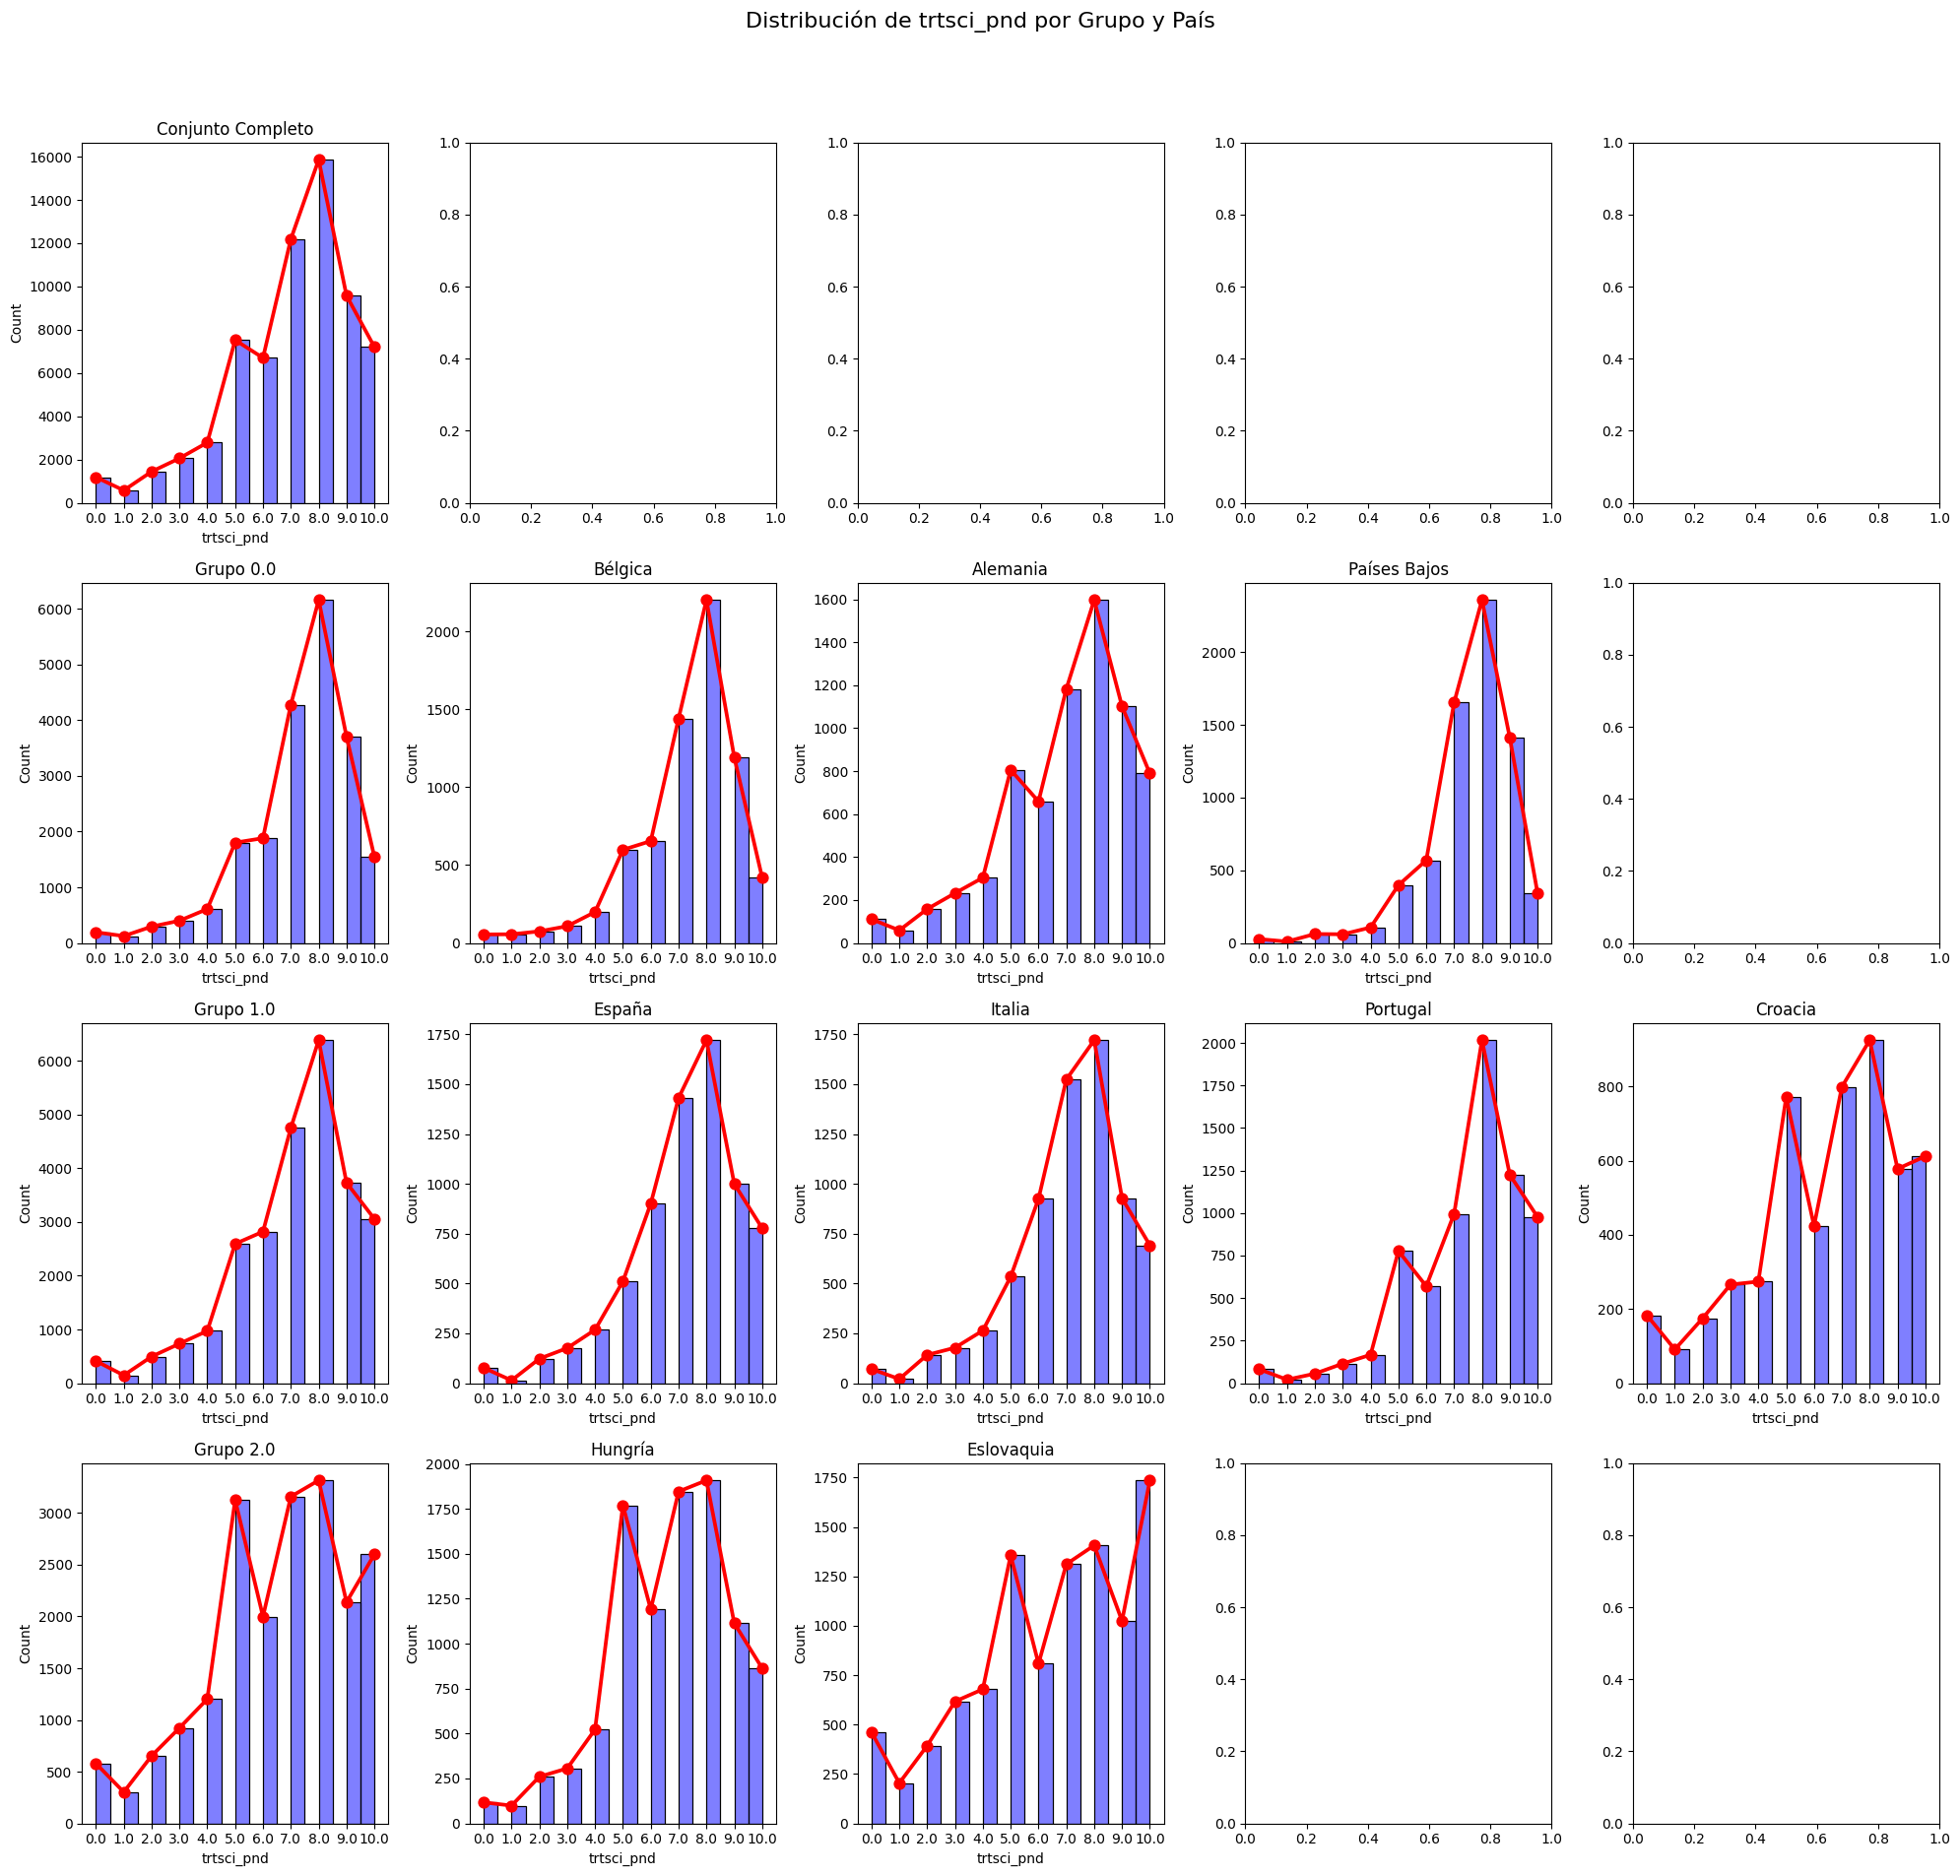

In [30]:
#Variable 'trtsci_pnd'
GroupDist(dfeu,'trtsci_pnd')

In [31]:
statsgroup(dfeu,'trtsci_pnd')

Estadísticas para trtsci_pnd - Conjunto Completo:
count    67098.000000
mean         6.990134
std          2.213265
min          0.000000
25%          6.000000
50%          7.000000
75%          9.000000
max         10.000000
Name: trtsci_pnd, dtype: float64
Moda: 8.0, Frecuencia: 15857
Varianza: 4.898541940745038


Estadísticas para trtsci_pnd - Grupo 0.0:
count    21000.000000
mean         7.272857
std          1.898472
min          0.000000
25%          6.000000
50%          8.000000
75%          9.000000
max         10.000000
Name: trtsci_pnd, dtype: float64
Moda: 8.0, Frecuencia: 6158
Varianza: 3.6041967984870027


Estadísticas para trtsci_pnd - País Bélgica (Grupo 0.0):
count    7000.000000
mean        7.267571
std         1.828785
min         0.000000
25%         7.000000
50%         8.000000
75%         8.000000
max        10.000000
Name: trtsci_pnd, dtype: float64
Moda: 8.0, Frecuencia: 2201
Varianza: 3.3444547384320207


Estadísticas para trtsci_pnd - País Alemania (Grupo 0.0

15-'trtsci_pnd': Escala de 0 a 10, grado de confianza con el lobby cientifico, 0 siendo inexistente.

Variable discontinua que a computo general de muestras describe una funcion asimétrica con el mayor(mas del 50%) de muestras
desplazada positivamente respecto al valor medio aritmetico del rango de la variable. Alcanzando su maximo local de muestras en el valor 8.

Gracias a los subconjuntos de muestras podemos apreciar como gran cantidad de muestras se desplazan de tercer cuartil al segundo cuartil, conforme los grupos de paises son mas pobres,creando funciones asimetricas bimodales mas cercanas a la media aritmetica del valor de la variable.

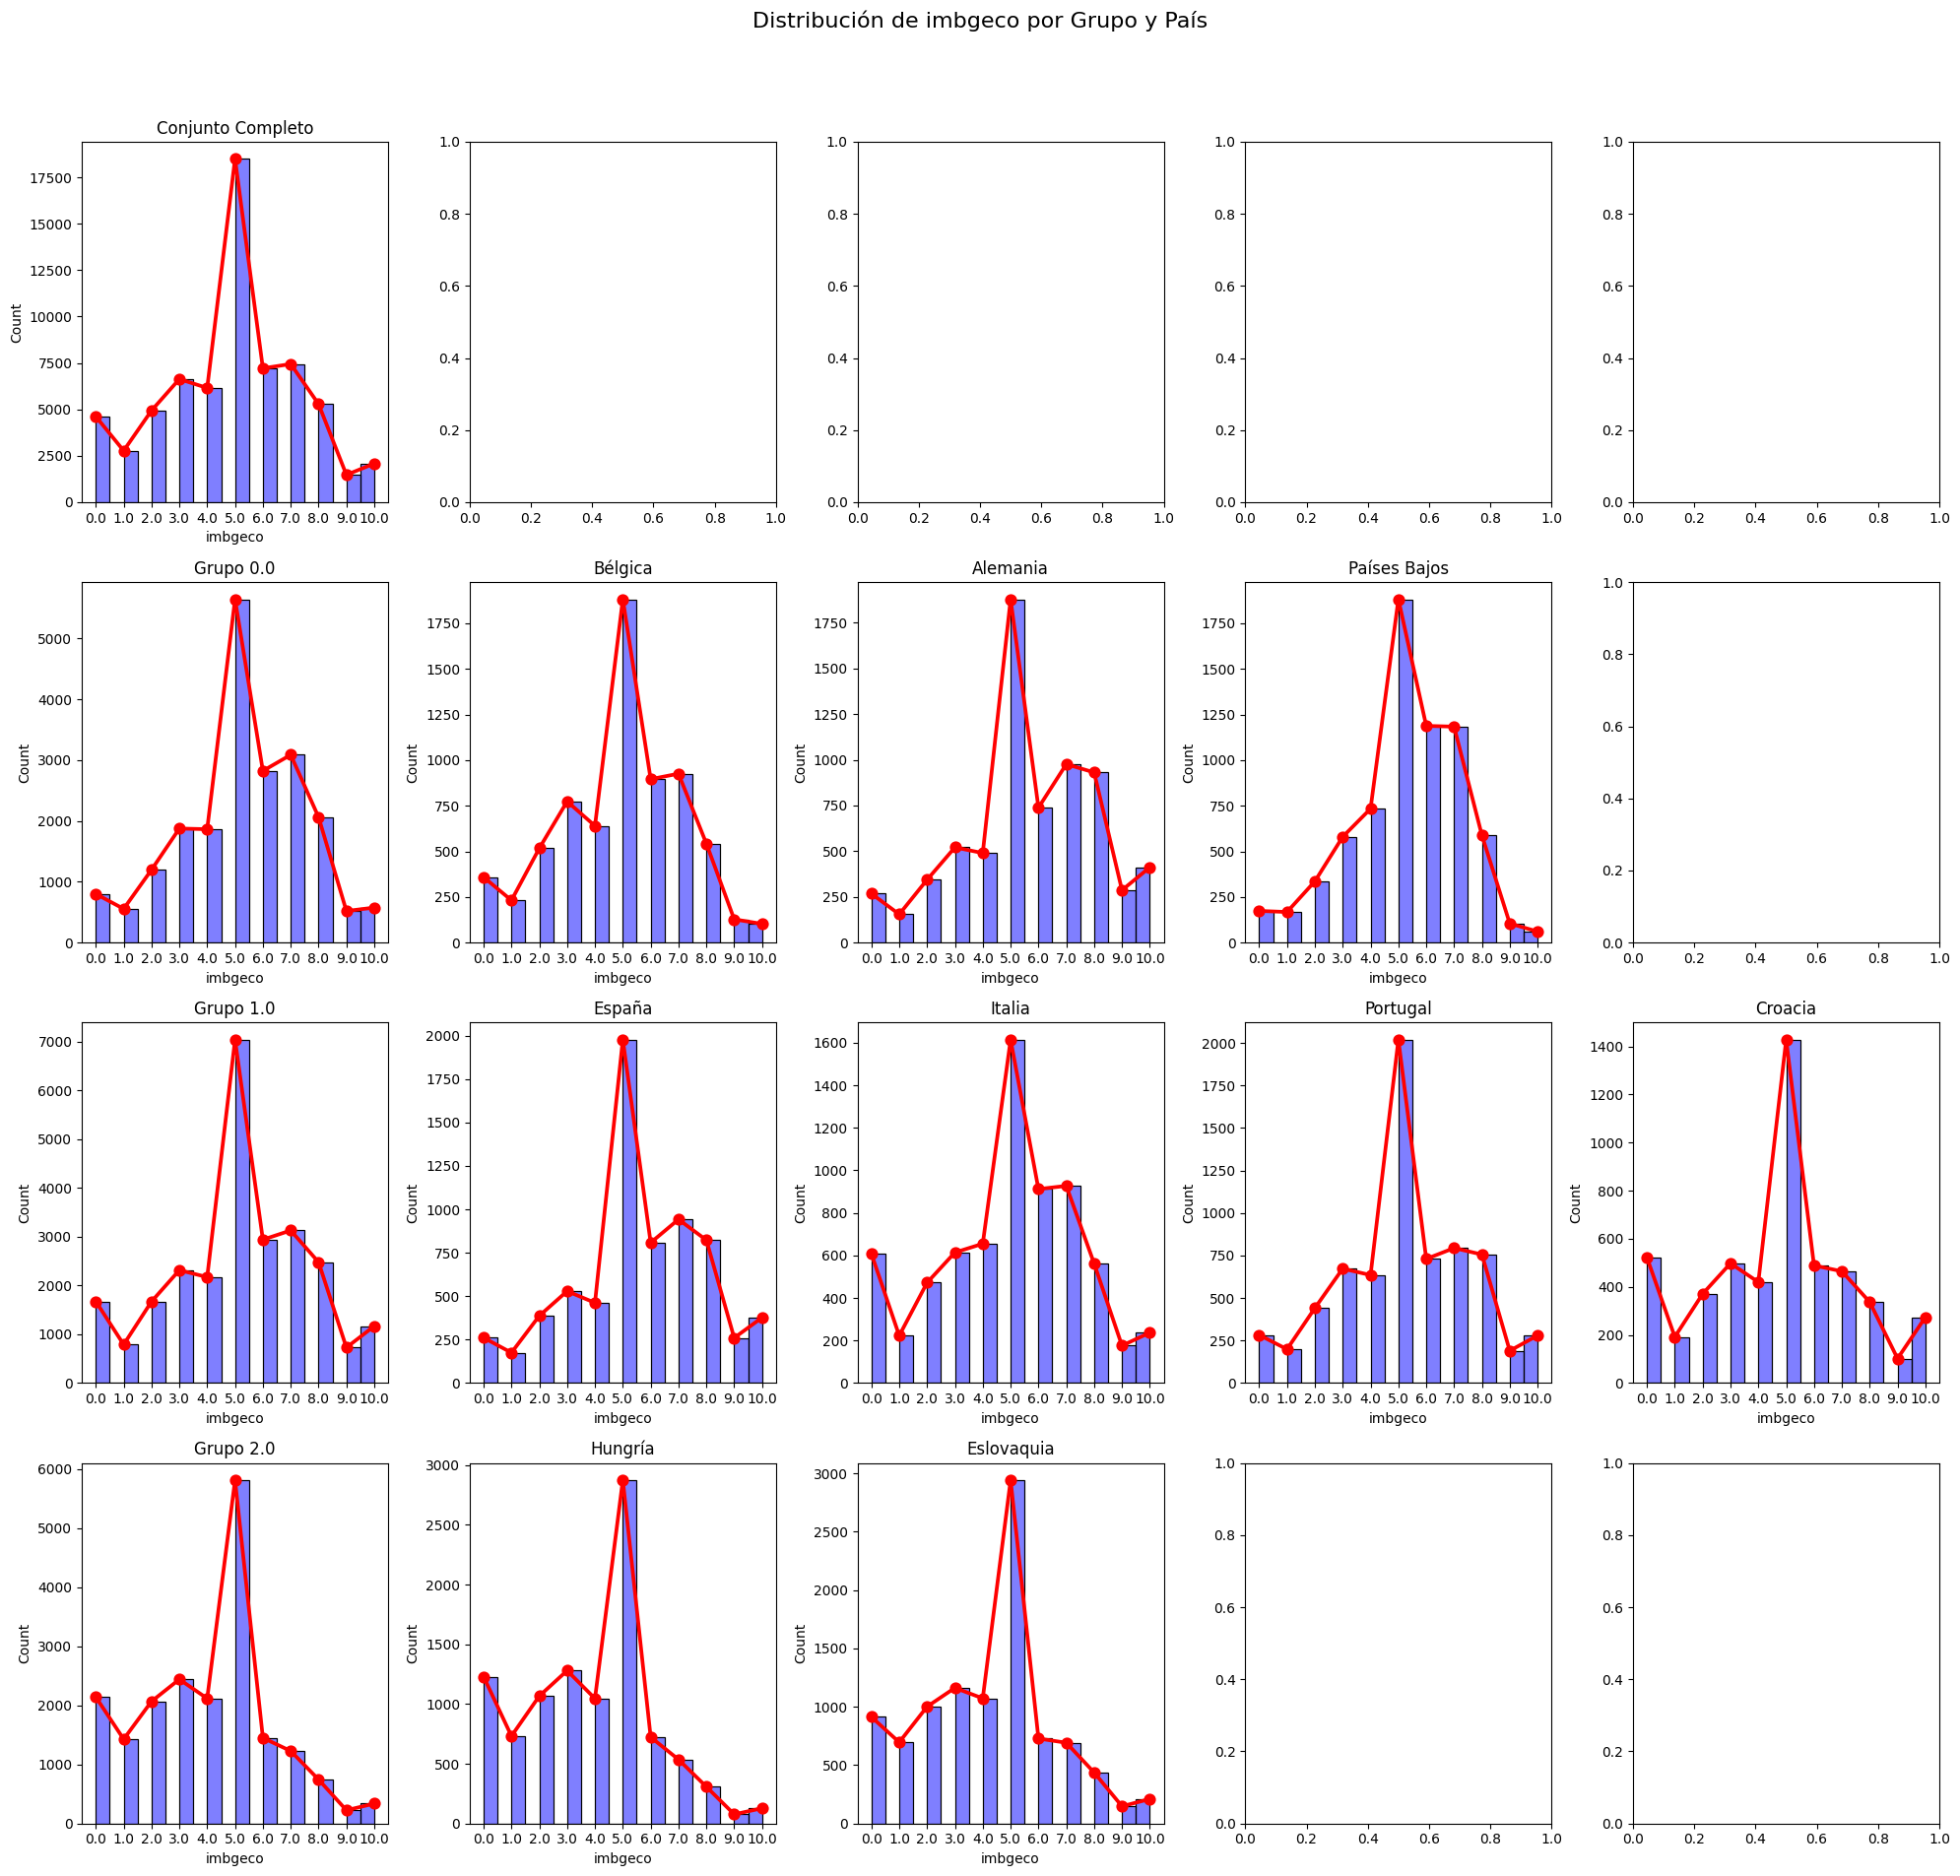

In [32]:
#Variable 'imbgeco'
GroupDist(dfeu, 'imbgeco')

In [33]:
statsgroup(dfeu, 'imbgeco')

Estadísticas para imbgeco - Conjunto Completo:
count    67098.000000
mean         4.789204
std          2.423427
min          0.000000
25%          3.000000
50%          5.000000
75%          6.000000
max         10.000000
Name: imbgeco, dtype: float64
Moda: 5.0, Frecuencia: 18494
Varianza: 5.872997291529053


Estadísticas para imbgeco - Grupo 0.0:
count    21000.000000
mean         5.224286
std          2.230039
min          0.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: imbgeco, dtype: float64
Moda: 5.0, Frecuencia: 5642
Varianza: 4.973075588633472


Estadísticas para imbgeco - País Bélgica (Grupo 0.0):
count    7000.000000
mean        4.848857
std         2.237061
min         0.000000
25%         3.000000
50%         5.000000
75%         6.000000
max        10.000000
Name: imbgeco, dtype: float64
Moda: 5.0, Frecuencia: 1882
Varianza: 5.004442185618354


Estadísticas para imbgeco - País Alemania (Grupo 0.0):
count    7000.000000

16-'imbgeco': Escala de 0 a 10, grado de opinion sobre si la inmigracion es buena para la economia, 0 siendo absolutamente mala.

Variable discontinua numerica donde en todos los diferentes conjuntos de muestras describe una funcion simetrica gaussiana(o funcion normal), hay que hacer mencion al tercer grupo de muestras por paises donde claramente hay una migracion de muestras del tercer cuartil al primero y al primer rango intercuartilico. Pero a nivel general no hay muchas diferencias.


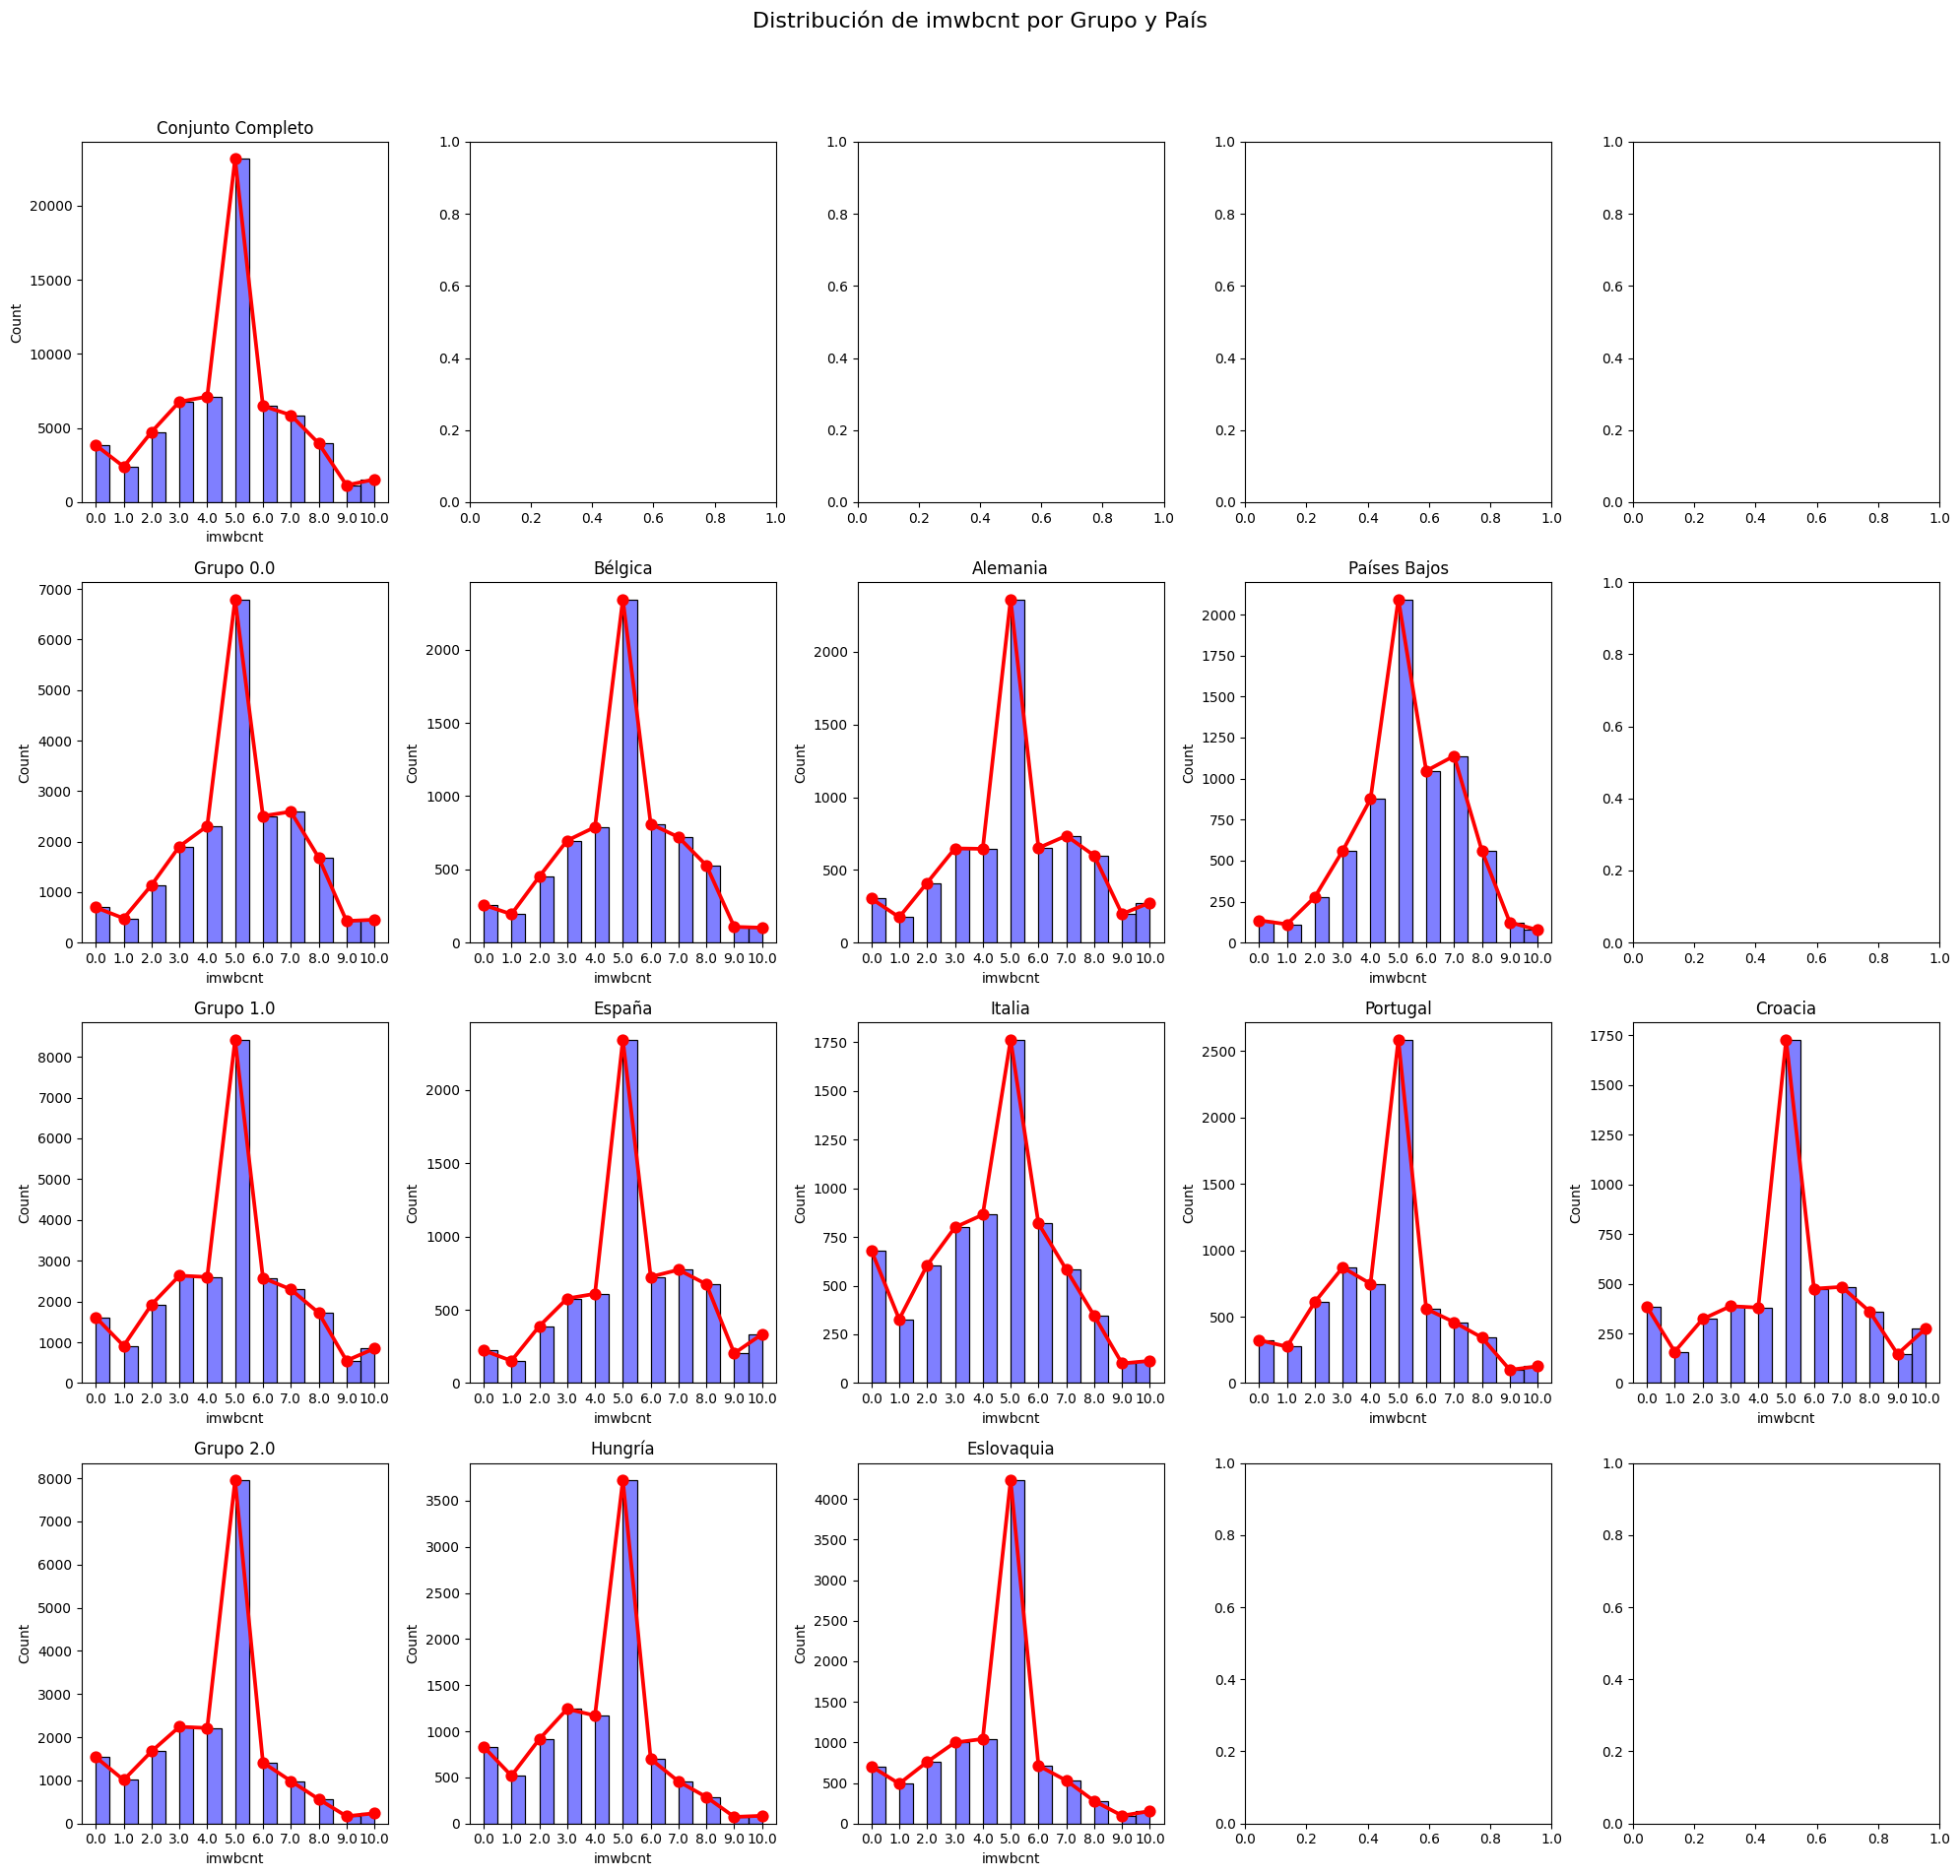

In [34]:
#Variable 'imwbcnt'
GroupDist(dfeu, 'imwbcnt')

In [35]:
statsgroup(dfeu, 'imwbcnt')


Estadísticas para imwbcnt - Conjunto Completo:
count    67098.000000
mean         4.682807
std          2.208758
min          0.000000
25%          3.000000
50%          5.000000
75%          6.000000
max         10.000000
Name: imwbcnt, dtype: float64
Moda: 5.0, Frecuencia: 23171
Varianza: 4.878611360102621


Estadísticas para imwbcnt - Grupo 0.0:
count    21000.000000
mean         5.085238
std          2.086576
min          0.000000
25%          4.000000
50%          5.000000
75%          6.000000
max         10.000000
Name: imwbcnt, dtype: float64
Moda: 5.0, Frecuencia: 6798
Varianza: 4.353798933736074


Estadísticas para imwbcnt - País Bélgica (Grupo 0.0):
count    7000.000000
mean        4.881571
std         2.063530
min         0.000000
25%         4.000000
50%         5.000000
75%         6.000000
max        10.000000
Name: imwbcnt, dtype: float64
Moda: 5.0, Frecuencia: 2344
Varianza: 4.258154409813647


Estadísticas para imwbcnt - País Alemania (Grupo 0.0):
count    7000.000000

17-'imwbcnt': Escala de 0 a 10, grado de opinión sobre si la inmigracion hace peor la calidad de vida nacional, 0 siendo afirmativo.

Variable discontinua que en su distribucion con el total de las muestras sigue un patron gaussiano, solo podemos apreciar una leve fuga de muestras del tercel cuartil al primer cuartil y segundo en el subconjunto del grupo pobre de paises, tambien se ovserva que italia en el subconjunto 1 hay mas muestras en el primer cuartil que el tercero.
Saquen sus conclusiones.

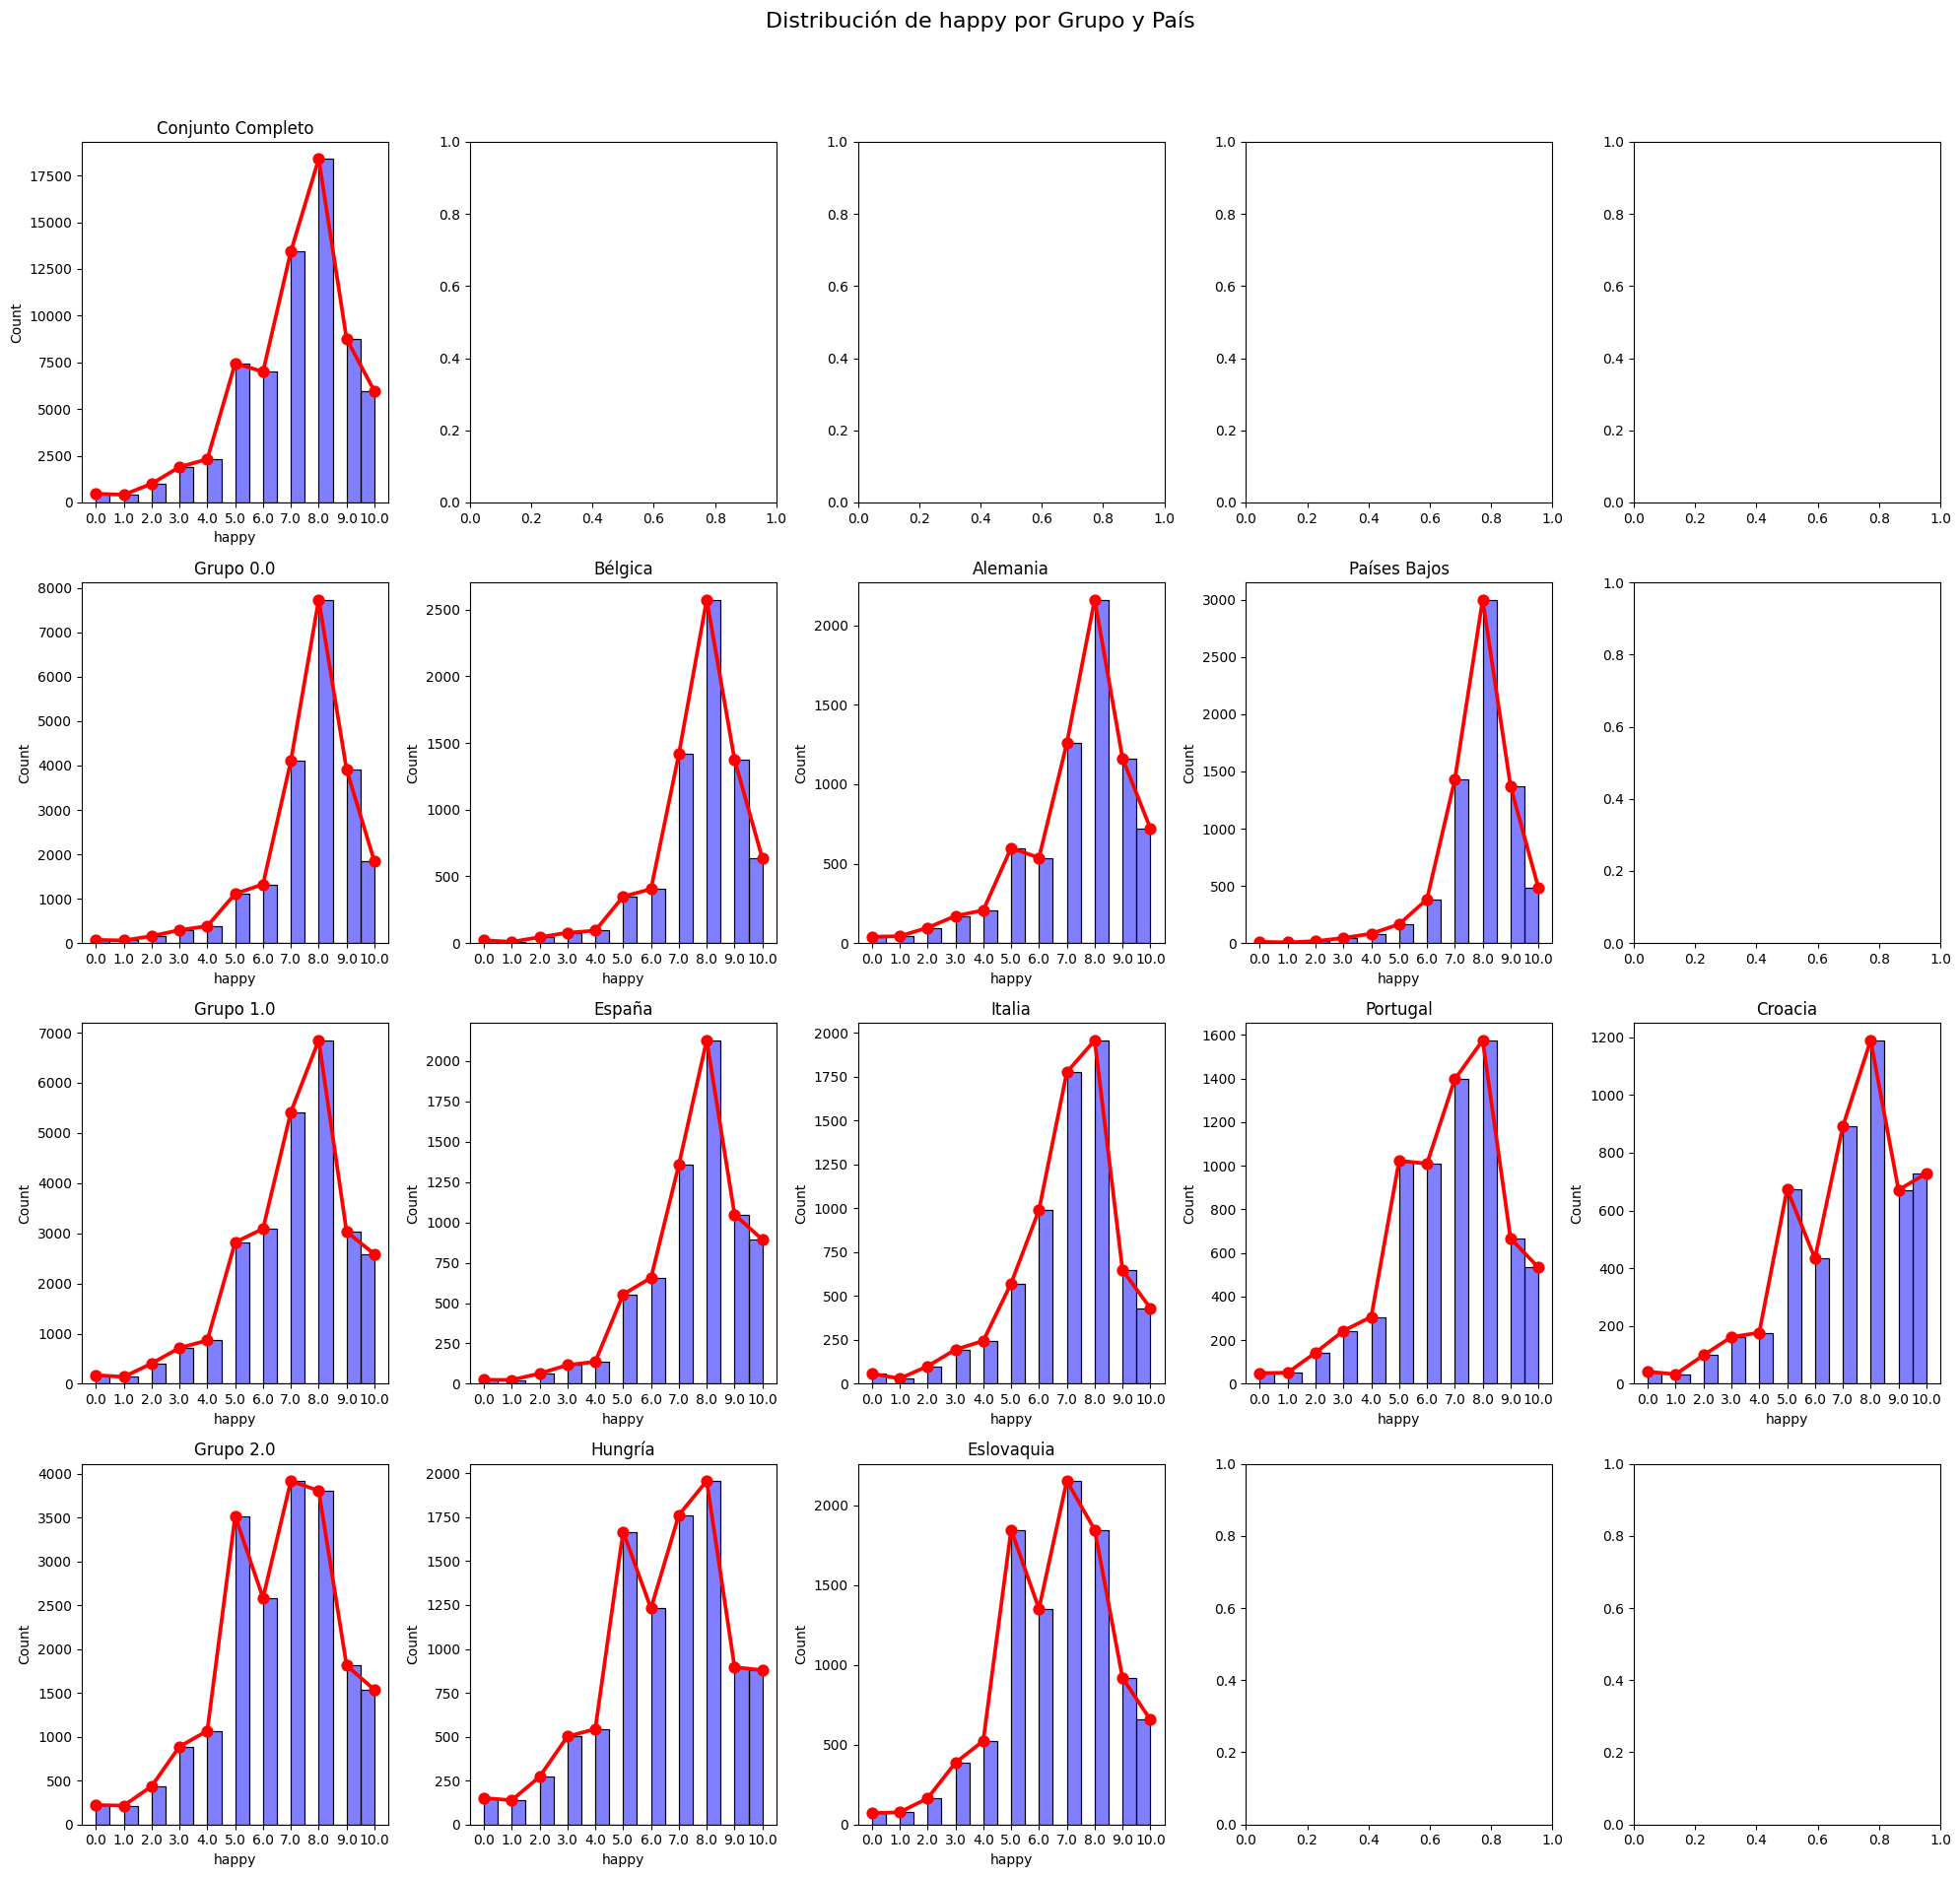

In [36]:
#Variable 'happy'
GroupDist(dfeu,'happy')

In [37]:
statsgroup(dfeu, 'happy')

Estadísticas para happy - Conjunto Completo:
count    67098.000000
mean         7.097723
std          1.958784
min          0.000000
25%          6.000000
50%          7.000000
75%          8.000000
max         10.000000
Name: happy, dtype: float64
Moda: 8.0, Frecuencia: 18392
Varianza: 3.8368366996101426


Estadísticas para happy - Grupo 0.0:
count    21000.000000
mean         7.643333
std          1.618276
min          0.000000
25%          7.000000
50%          8.000000
75%          9.000000
max         10.000000
Name: happy, dtype: float64
Moda: 8.0, Frecuencia: 7738
Varianza: 2.618818356429671


Estadísticas para happy - País Bélgica (Grupo 0.0):
count    7000.000000
mean        7.726429
std         1.536855
min         0.000000
25%         7.000000
50%         8.000000
75%         9.000000
max        10.000000
Name: happy, dtype: float64
Moda: 8.0, Frecuencia: 2574
Varianza: 2.3619246627069175


Estadísticas para happy - País Alemania (Grupo 0.0):
count    7000.000000
mean       

18-'happy': Escala de 0 a 10, grado de cuan feliz eres, siendo 0 infeliz.

Variable discontinua numerica que por lo general no cambia en funcion del subgrupo de paises.
Describe una funcion gaussiana asimetrica, desplazada positivamente respecto al valor medio del rango de la variable.

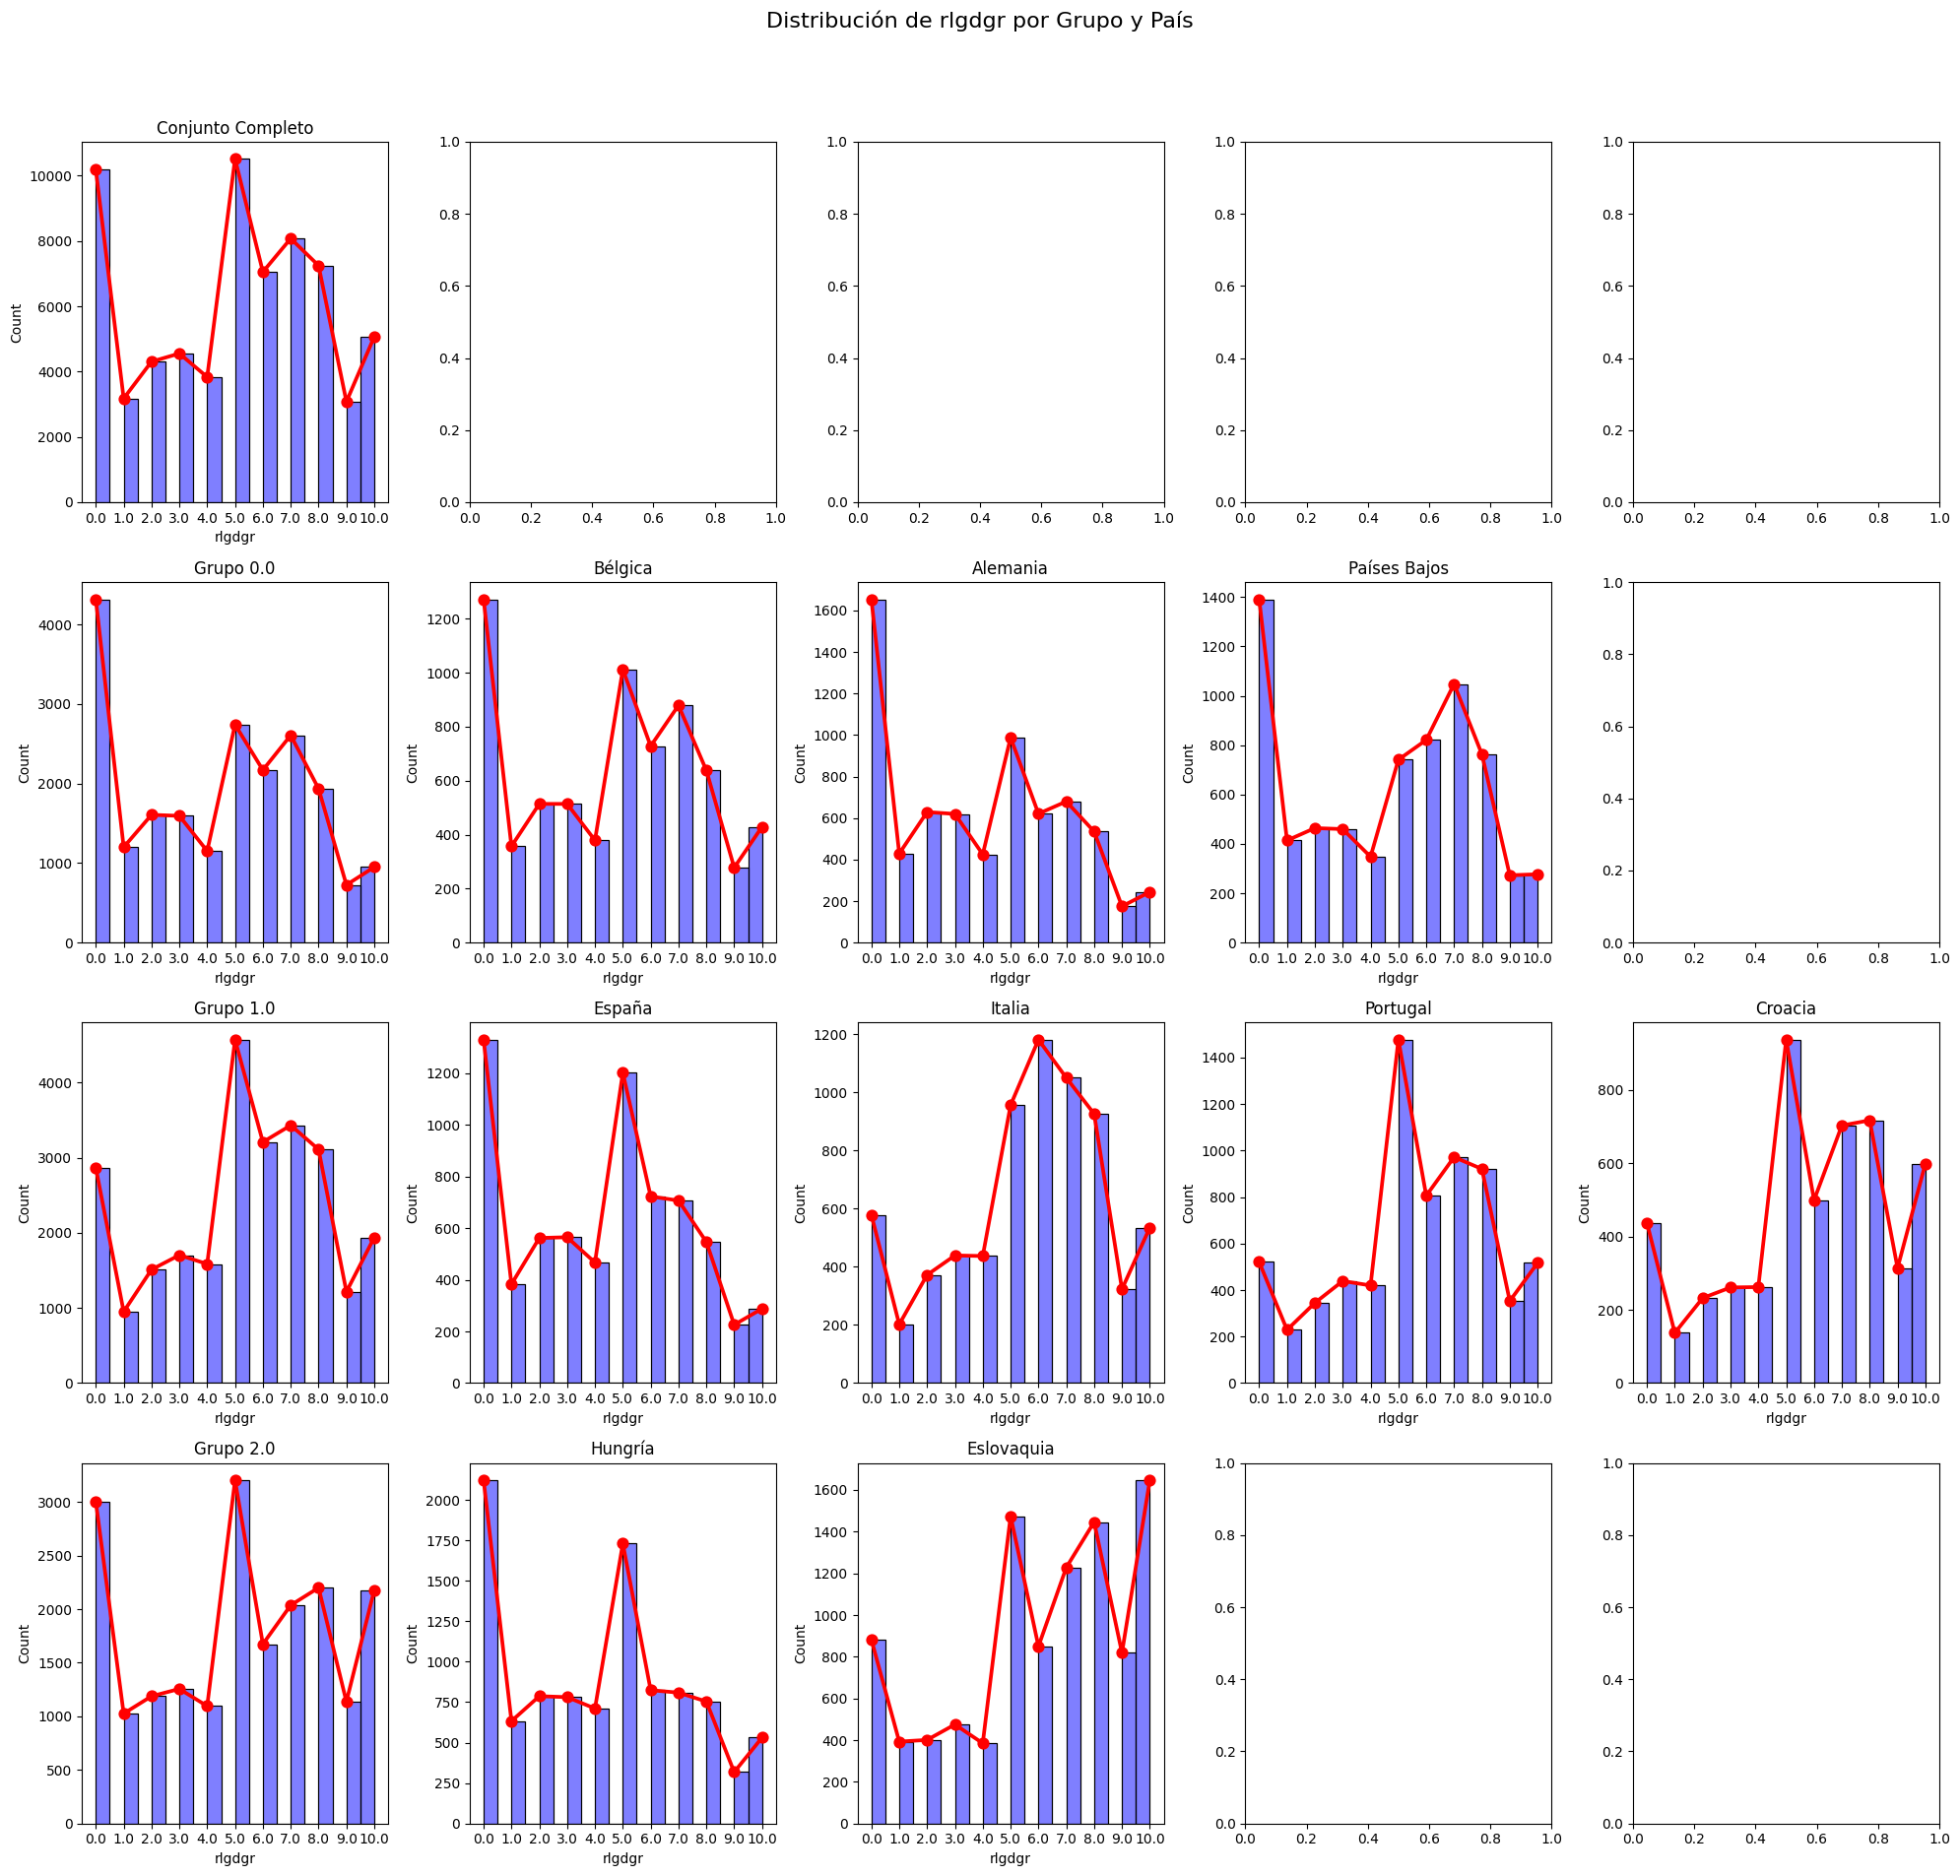

In [38]:
#Variable 'rlgdgr'
GroupDist(dfeu, 'rlgdgr')

In [39]:
statsgroup(dfeu, 'rlgdgr')

Estadísticas para rlgdgr - Conjunto Completo:
count    67098.000000
mean         4.897001
std          3.103222
min          0.000000
25%          2.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: rlgdgr, dtype: float64
Moda: 5.0, Frecuencia: 10517
Varianza: 9.629986090016965


Estadísticas para rlgdgr - Grupo 0.0:
count    21000.000000
mean         4.300000
std          3.118483
min          0.000000
25%          1.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: rlgdgr, dtype: float64
Moda: 0.0, Frecuencia: 4317
Varianza: 9.72493928282299


Estadísticas para rlgdgr - País Bélgica (Grupo 0.0):
count    7000.000000
mean        4.560000
std         3.125622
min         0.000000
25%         2.000000
50%         5.000000
75%         7.000000
max        10.000000
Name: rlgdgr, dtype: float64
Moda: 0.0, Frecuencia: 1272
Varianza: 9.769509929989999


Estadísticas para rlgdgr - País Alemania (Grupo 0.0):
count    7000.000000
mean   

19-'rlgdgr': Escala de 0 a 10, cuan religioso eres, siendo 0 ateo. 

Variable discontinua que describe una funcion  antitónica, es decir que el mayor grueso de sus muestras se recogen cercanos a los valores minimos y maximos del rango de la variable, es una variable con bastante probabilidad de ser binarizada( es decir transformarla a binaria) ademas dada su significancia, no tiene sentido ser religioso moderado.
Se aprecian gruesos de muestras ubicados en el minimo y maximo distinto en cada subgrupo de paises.
Por lo general los paises del grupo 0 tienen mas muestras en el primer cuartil.

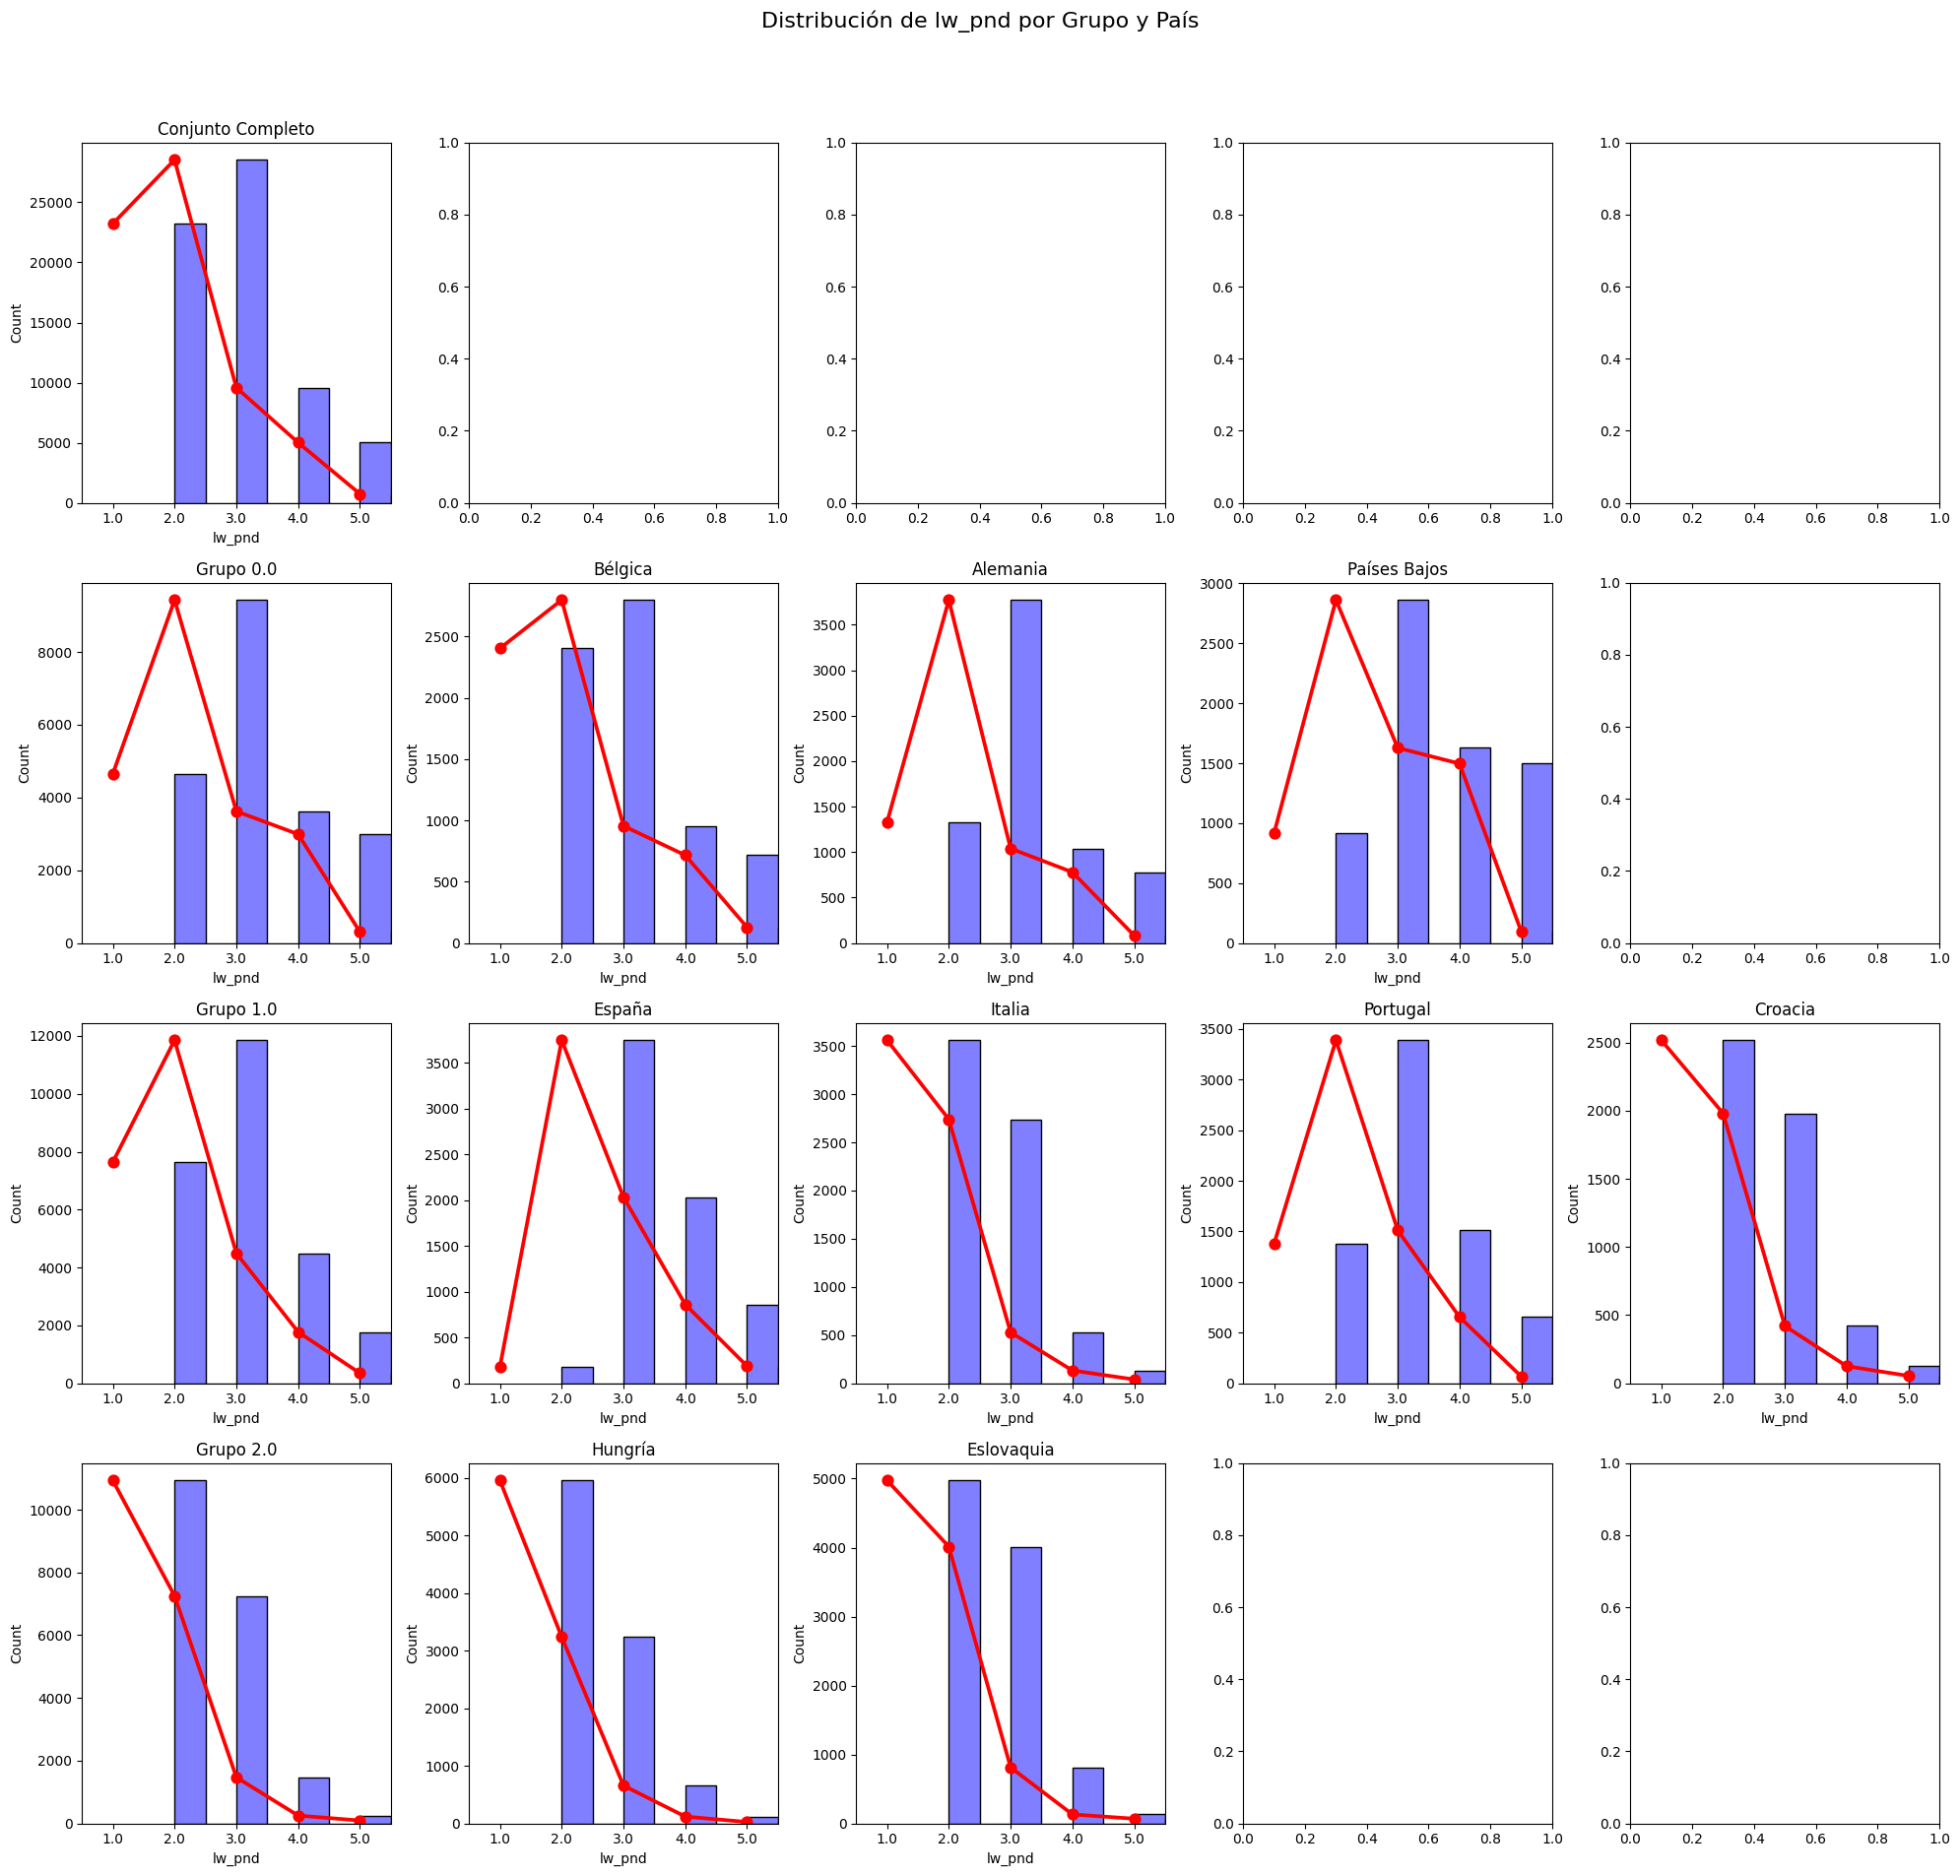

In [40]:
GroupDist(dfeu, 'lw_pnd')

In [41]:
statsgroup(dfeu,'lw_pnd')

Estadísticas para lw_pnd - Conjunto Completo:
count    67098.000000
mean         1.979314
std          0.941714
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          5.000000
Name: lw_pnd, dtype: float64
Moda: 2.0, Frecuencia: 28541
Varianza: 0.886824859668371


Estadísticas para lw_pnd - Grupo 0.0:
count    21000.000000
mean         2.279619
std          1.008136
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: lw_pnd, dtype: float64
Moda: 2.0, Frecuencia: 9432
Varianza: 1.0163377757217464


Estadísticas para lw_pnd - País Bélgica (Grupo 0.0):
count    7000.000000
mean        2.052571
std         1.025093
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         5.000000
Name: lw_pnd, dtype: float64
Moda: 2.0, Frecuencia: 2798
Varianza: 1.0508149327454943


Estadísticas para lw_pnd - País Alemania (Grupo 0.0):
count    7000.000000
mean

20-'lw_pnd': Escala de 1 a 5, grado de conformidad sobre si las leyes se han de cumplir, siendo 1 la opinión incondicional de que si.

Variable discontinua que describe una distribucion gaussiana asimetríca donde el mayor numero de muestras estan ubicadas en los rangos de la variable comprendidos entre 1 y 2.
Todos los subconjuntos describen funciones sin apenas cambios.

Visto en el analisis descriptivo de nuestras variables y el cambio de distribuciones que tienen muchas de nuestras variables al observarlas por subconjuntos de muestras a razon de grupos de paises, podemos sostener que la clusterizacion de muestras por grupos de paises discriminando por situacion economica similar, es un criterio acertado para discriminar las muestras.
Siguiente paso es el EDA, alojado en la subcarpeta PASO 5.